## Salary Data Consistency Validator

In [31]:
import json
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

### Configuration

In [46]:
DATA_PATH             = "/content/salary_dataset_labelled.json"  # ← set your file path here
OUTPUT_PATH           = "validated_output.csv"  # ← where results are saved
MIN_SEGMENT_SIZE      = 3      # minimum entries in a segment to run LOF
LOF_N_NEIGHBORS       = 5       # k for LOF; auto-clamped if segment is small
LOF_CONTAMINATION     = 0.10    # expected outlier fraction within a segment
CONSISTENCY_THRESHOLD = 0.50    # below this → "low consistency" bucket

# Weights for final score  (must sum to 1.0)
WEIGHT_RULE = 0.30
WEIGHT_LOF  = 0.70

# Known large public companies → should NOT have startup funding stages
PUBLIC_COMPANIES = {
    "oracle", "microsoft", "google", "amazon", "apple", "meta", "netflix",
    "salesforce", "servicenow", "snowflake", "adobe", "ibm", "intel",
    "deere & company", "cigna", "hca healthcare", "jpmorgan", "goldman sachs",
    "morgan stanley", "bank of america", "wells fargo", "visa", "mastercard",
    "unitedhealth", "cvs", "walmart", "target", "boeing", "lockheed martin",
    "accenture", "infosys", "wipro", "tcs", "capgemini",
}
STARTUP_STAGES = {"seed", "series a", "series b", "series c", "series d"}

# Level string → ordinal (extend this as you see new level strings)
LEVEL_ORDINAL = {
    # IC track
    "l1": 1, "l2": 2, "l3": 3, "l4": 4, "l5": 5, "l6": 6, "l7": 7,
    "ic1": 1, "ic2": 2, "ic3": 3, "ic4": 4, "ic5": 5, "ic6": 6,
    "e1": 1, "e2": 2, "e3": 3, "e4": 4, "e5": 5, "e6": 6, "e7": 7,
    "junior": 1, "mid": 2, "mid-level": 2, "senior": 3,
    "staff": 4, "principal": 5, "fellow": 6, "distinguished": 7,
    "swe i": 1, "swe ii": 2, "senior swe": 3, "staff swe": 4,
    # Manager track — add these
    "m1": 1, "m2": 2, "m3": 3, "m4": 4, "m5": 5,
    "manager": 1, "senior manager": 2, "director": 3,
    "senior director": 4, "vp": 5, "svp": 6, "evp": 7, "cto": 8,
    "partner": 3,
}


# FAANG + known top-tier; used to derive company_tier feature
FAANG = {"google", "meta", "amazon", "apple", "microsoft", "netflix"}
TIER2 = {
    "oracle", "salesforce", "servicenow", "snowflake", "adobe", "nvidia",
    "uber", "lyft", "airbnb", "stripe", "linkedin", "twitter", "x",
    "databricks", "confluent", "figma", "notion", "openai", "anthropic",
}

### 1. Load Data

In [33]:
def load_data(path: str) -> pd.DataFrame:
    with open(path, "r") as f:
        records = json.load(f)
    df = pd.json_normalize(records)
    print(f"[load]  {len(df)} records, {len(df.columns)} columns")
    return df

### 2. Rule-Based Hard Flags

In [34]:
def _is_gibberish(name) -> bool:
    """Company name is numeric-only, symbol-only, or suspiciously short."""
    if not isinstance(name, str) or len(name.strip()) < 2:
        return True
    return bool(re.fullmatch(r"[\d\W]+", name.strip()))


def flag_rules(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a boolean DataFrame where True = that rule was violated.

    Columns produced (each is a separate flag):
      flag_gibberish_company       – company name is numeric/garbage
      flag_yal_gt_yac              – yearsAtLevel > yearsAtCompany (impossible)
      flag_yac_gt_yoe              – yearsAtCompany > yearsOfExperience (impossible)
      flag_negative_experience     – any experience field is negative
      flag_zero_or_negative_base   – baseSalary <= 0
      flag_tc_less_than_base       – totalCompensation_USD < baseSalary_USD
      flag_junior_level_high_yoe   – L1/IC1 with yearsOfExperience > 8
      flag_bonus_pct_mismatch      – declared bonus% ≠ actual bonus (>25% deviation)
      flag_public_co_startup_stage – known public company tagged as Series A/B/C etc.
      flag_tc_arithmetic_mismatch  – TC ≠ base + bonus + stock (>15% deviation)
      flag_companysize_mismatch    – public company listed as tiny (<200 employees)
    """
    flags = pd.DataFrame(index=df.index)

    # — Company name quality
    flags["flag_gibberish_company"] = df["company"].apply(_is_gibberish)

    # — Experience / tenure ordering
    yoe = pd.to_numeric(df.get("yearsOfExperience", pd.Series(0, index=df.index)), errors="coerce").fillna(0)
    yac = pd.to_numeric(df.get("yearsAtCompany",    pd.Series(0, index=df.index)), errors="coerce").fillna(0)
    yal = pd.to_numeric(df.get("yearsAtLevel",      pd.Series(0, index=df.index)), errors="coerce").fillna(0)

    flags["flag_yal_gt_yac"]          = yal > yac
    flags["flag_yac_gt_yoe"]          = yac > yoe
    flags["flag_negative_experience"] = (yoe < 0) | (yac < 0) | (yal < 0)

    # — Salary sanity (pre-normalization, catches outright zeros/negatives)
    flags["flag_zero_or_negative_base"] = pd.to_numeric(
        df.get("baseSalary", pd.Series(0, index=df.index)), errors="coerce"
    ).fillna(0) <= 0

    # — Placeholders filled after normalization
    flags["flag_tc_less_than_base"]       = False
    flags["flag_tc_arithmetic_mismatch"]  = False

    # — Junior level with high experience
    level_norm = df.get("level", pd.Series("", index=df.index, dtype=str)).str.lower().str.strip().fillna("")
    is_entry   = level_norm.isin(["l1", "ic1", "e1", "junior", "swe i"])
    flags["flag_junior_level_high_yoe"] = is_entry & (yoe > 8)

    # — Bonus percentage vs actual bonus value (within-currency, so valid pre-norm)
    base_raw     = pd.to_numeric(df.get("baseSalary", pd.Series(0, index=df.index)), errors="coerce").fillna(0)
    bonus_pct    = pd.to_numeric(df.get("annualTargetBonusPercentage", pd.Series(0, index=df.index)), errors="coerce").fillna(0) / 100
    bonus_actual = pd.to_numeric(df.get("annualTargetBonusValue", pd.Series(0, index=df.index)), errors="coerce").fillna(0)
    expected_bonus = base_raw * bonus_pct
    both_nonzero   = (expected_bonus > 0) & (bonus_actual > 0)
    ratio = (bonus_actual / expected_bonus.replace(0, np.nan)).fillna(1.0)
    flags["flag_bonus_pct_mismatch"] = both_nonzero & ((ratio < 0.75) | (ratio > 1.25))

    # — Known public company with startup funding stage
    company_lc = df.get("company", pd.Series("", index=df.index, dtype=str)).str.lower().str.strip().fillna("")
    funding_lc = df.get("fundingStage", pd.Series("", index=df.index, dtype=str)).str.lower().str.strip().fillna("")
    flags["flag_public_co_startup_stage"] = (
        company_lc.isin(PUBLIC_COMPANIES) & funding_lc.isin(STARTUP_STAGES)
    )

    # — Large public company listed with tiny headcount
    size_map = {
        "1-10": 5, "11-50": 30, "51-200": 125, "201-500": 350,
        "501-1000": 750, "1001-5000": 3000, "5000+": 10000,
    }
    size_numeric = df.get("companySize", pd.Series(np.nan, index=df.index, dtype=str)).map(size_map).fillna(np.nan)
    flags["flag_companysize_mismatch"] = (
        company_lc.isin(PUBLIC_COMPANIES) & (size_numeric < 1000)
    )

    return flags

### 3. Salary Normalization to USD

In [35]:
def normalize_salaries(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    exch = pd.to_numeric(df.get("exchangeRate", pd.Series(1, index=df.index)), errors="coerce").replace(0, np.nan).fillna(1)
    base_currency  = df.get("baseSalaryCurrency", pd.Series("USD", index=df.index, dtype=str)).fillna("USD")
    bonus_currency = df.get("bonusCurrency",      pd.Series("USD", index=df.index, dtype=str)).fillna("USD")

    base_raw  = pd.to_numeric(df.get("baseSalary",            pd.Series(0, index=df.index)), errors="coerce").fillna(0)
    bonus_raw = pd.to_numeric(df.get("avgAnnualBonusValue",   pd.Series(0, index=df.index)), errors="coerce").fillna(0)

    # baseSalary → USD
    df["baseSalary_USD"] = np.where(base_currency == "USD", base_raw, base_raw / exch)

    # totalCompensation is stored in USD already in this dataset
    df["totalCompensation_USD"] = pd.to_numeric(
        df.get("totalCompensation", pd.Series(0, index=df.index)), errors="coerce"
    ).fillna(0)

    # avgAnnualBonusValue → USD
    df["avgAnnualBonusValue_USD"] = np.where(
        bonus_currency == "USD", bonus_raw, bonus_raw / exch
    )

    # Stock is always stored in USD per dataset schema
    df["avgAnnualStockGrantValue_USD"] = pd.to_numeric(
        df.get("avgAnnualStockGrantValue", pd.Series(0, index=df.index)), errors="coerce"
    ).fillna(0)

    return df


def fill_postnorm_flags(df: pd.DataFrame, flags: pd.DataFrame) -> pd.DataFrame:
    """Flags that require USD-normalized columns."""
    # TC < base salary
    flags["flag_tc_less_than_base"] = (
        (df["totalCompensation_USD"] < df["baseSalary_USD"]) &
        (df["baseSalary_USD"] > 0)
    )

    # TC arithmetic: |TC - (base + bonus + stock)| / TC > 15%
    reconstructed = (
        df["baseSalary_USD"] +
        df["avgAnnualBonusValue_USD"] +
        df["avgAnnualStockGrantValue_USD"]
    )
    tc_safe   = df["totalCompensation_USD"].replace(0, np.nan)
    deviation = ((reconstructed - tc_safe).abs() / tc_safe).fillna(0)
    flags["flag_tc_arithmetic_mismatch"] = deviation > 0.15

    return flags

### 4. Feature Engineering

In [36]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Level ordinal + group
    level_key  = df.get("level", pd.Series("", index=df.index, dtype=str)).str.lower().str.strip().fillna("")
    df["level_ordinal"] = level_key.map(LEVEL_ORDINAL).fillna(0).astype(int)

    def _level_group(o):
        if o <= 1: return "junior"
        if o <= 2: return "mid"
        if o <= 3: return "senior"
        return "staff_plus"
    df["level_group"] = df["level_ordinal"].apply(_level_group)

    # Region from countryId
    COUNTRY_REGION = {1: "US", 113: "India", 826: "UK", 276: "Germany",
                      250: "France", 380: "Italy", 724: "Spain", 124: "Canada",
                      36: "Australia", 392: "Japan", 156: "China", 76: "Brazil"}
    cid = pd.to_numeric(df.get("countryId", pd.Series(-1, index=df.index)), errors="coerce").fillna(-1).astype(int)
    df["region"] = cid.map(COUNTRY_REGION).fillna("Other")

    # Job family — cleaned
    df["jobFamily_clean"] = (
        df.get("jobFamily", pd.Series("Unknown", index=df.index, dtype=str))
          .str.strip().str.title().fillna("Unknown")
    )

    # Company tier
    def _tier(name):
        n = str(name).lower().strip()
        if n in FAANG:  return "faang"
        if n in TIER2:  return "tier2"
        return "other"
    df["company_tier"] = df.get("company", pd.Series("other", index=df.index, dtype=str)).apply(_tier)

    # Employment type — normalized
    emp = df.get("employmentType", pd.Series("unknown", index=df.index, dtype=str)).str.lower().str.strip().fillna("unknown")
    df["employmentType_clean"] = emp

    # Derived ratio features
    base_safe = df["baseSalary_USD"].replace(0, np.nan)
    tc_safe   = df["totalCompensation_USD"].replace(0, np.nan)

    df["bonus_ratio"] = (df["avgAnnualBonusValue_USD"]      / base_safe).fillna(0).clip(0, 5)
    df["stock_ratio"] = (df["avgAnnualStockGrantValue_USD"] / base_safe).fillna(0).clip(0, 20)
    df["tc_to_base"]  = (tc_safe / base_safe).fillna(1).clip(0.5, 20)

    yoe = pd.to_numeric(df.get("yearsOfExperience", pd.Series(0, index=df.index)), errors="coerce").fillna(0)
    df["log_base_salary"] = np.log1p(df["baseSalary_USD"])
    df["log_tc"]          = np.log1p(df["totalCompensation_USD"])

    return df

### 5. Segmentation + LOF

In [37]:
# Features fed into LOF — all must be numeric and USD-normalized
LOF_FEATURES = [
    "log_base_salary",          # log-transformed base salary in USD
    "log_tc",                   # log-transformed total comp in USD
    "avgAnnualBonusValue_USD",
    "avgAnnualStockGrantValue_USD",
    "yearsOfExperience",
    "bonus_ratio",              # bonus / base
    "stock_ratio",              # stock / base
    "tc_to_base",               # TC / base (overall multiplier)
]

# Segmentation keys — LOF runs independently within each (a, b, c) bucket
SEGMENT_KEYS = ["jobFamily_clean", "region"]


def run_lof(df: pd.DataFrame) -> pd.DataFrame:
    """
    Assigns per-entry columns:
      segment       – human-readable segment label
      segment_size  – how many entries are in that segment
      lof_score     – raw LOF factor (≥1.0; higher = more anomalous)
      lof_label     – 'inlier' | 'outlier' | 'unscored' (segment too small)
    """
    df = df.copy()

    df["segment"] = (
        df["jobFamily_clean"] + " | " +
        df["level_group"]     + " | " +
        df["region"]
    )
    df["segment_size"] = 0
    df["lof_score"]    = np.nan
    df["lof_label"]    = "unscored"

    for seg_label, group in df.groupby("segment"):
        idx = group.index
        df.loc[idx, "segment_size"] = len(group)

        if len(group) < MIN_SEGMENT_SIZE:
            continue  # segment too small → stays 'unscored'

        X = group[LOF_FEATURES].fillna(0).values
        X_scaled = StandardScaler().fit_transform(X)

        k = min(LOF_N_NEIGHBORS, len(group) - 1)
        lof = LocalOutlierFactor(
            n_neighbors=k,
            contamination=LOF_CONTAMINATION,
            novelty=False,
        )
        labels = lof.fit_predict(X_scaled)        # -1 outlier, 1 inlier
        scores = -lof.negative_outlier_factor_     # higher = more anomalous

        df.loc[idx, "lof_score"] = scores
        df.loc[idx, "lof_label"] = np.where(labels == -1, "outlier", "inlier")

    return df

### 6. Consistency Score

In [38]:
RULE_COLUMNS =[
    "flag_yal_gt_yac",
    "flag_yac_gt_yoe",
    "flag_negative_experience",
    "flag_zero_or_negative_base",
    "flag_tc_less_than_base",
    "flag_junior_level_high_yoe",
    "flag_bonus_pct_mismatch",
    "flag_public_co_startup_stage",
    "flag_tc_arithmetic_mismatch",
    "flag_companysize_mismatch",
]


def compute_scores(df: pd.DataFrame, flags: pd.DataFrame) -> pd.DataFrame:
    """
    Adds to df:
      rule_violations    – count of hard-rule flags triggered (0 = clean)
      rule_score         – 1 - (violations / total_rules), range [0, 1]
      lof_normalized     – LOF score mapped to [0, 1] (1 = most consistent)
      consistency_score  – final weighted score [0, 1]; lower = more suspicious
    """
    df = df.copy()

    # Merge flags into df
    for col in RULE_COLUMNS:
        df[col] = flags[col].astype(bool).values

    df["rule_violations"] = flags[RULE_COLUMNS].astype(int).sum(axis=1).values
    df["rule_score"]      = 1.0 - (df["rule_violations"] / len(RULE_COLUMNS))

    # Normalize LOF: clip raw score to [1, 3], map to [1, 0]
    # (1.0 = perfectly consistent, anything ≥ 3.0 is fully anomalous)
    lof_raw = df["lof_score"].copy()
    df["lof_normalized"] = 1.0 - ((lof_raw.clip(1.0, 3.0) - 1.0) / 2.0)

    has_lof = df["lof_score"].notna()

    df["consistency_score"] = np.where(
        has_lof,
        WEIGHT_RULE * df["rule_score"] + WEIGHT_LOF * df["lof_normalized"],
        df["rule_score"],   # fallback to rule-only for small segments
    ).clip(0.0, 1.0).round(4)

    return df

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def detect_duplicates(df):

    df=df.copy()

    cols=[
        "company",
        "title",
        "level",
        "jobFamily"
    ]

    combined=(
        df[cols]
        .fillna("")
        .astype(str)
        .agg(" ".join,axis=1)
    )

    vectorizer=TfidfVectorizer()

    matrix=vectorizer.fit_transform(
        combined
    )

    similarity=cosine_similarity(
        matrix
    )

    flags=[]

    for i in range(len(df)):

        duplicate=False

        for j in range(len(df)):

            if i!=j and similarity[i][j]>0.95:

                duplicate=True
                break

        flags.append(duplicate)

    df["flag_duplicate"]=flags

    return df

### Benchmark Validation

In [40]:
BENCHMARKS={

("Software Engineer","junior","US"):

{
"min":90000,
"max":220000
},

("Software Engineer","senior","US"):

{
"min":180000,
"max":500000
}

}

def benchmark_validation(df):

    flags=[]

    for _,row in df.iterrows():

        key=(

            row["jobFamily_clean"],
            row["level_group"],
            row["region"]

        )

        salary=row["baseSalary_USD"]

        if key in BENCHMARKS:

            low=BENCHMARKS[key]["min"]
            high=BENCHMARKS[key]["max"]

            flags.append(

                salary<low
                or
                salary>high

            )

        else:

            flags.append(False)

    df["flag_benchmark"]=flags

    return df

### User trust score

In [41]:
def user_trust_score(df):

    df = df.copy()

    trust = []

    for _, row in df.iterrows():

        score = row["consistency_score"]

        duplicate = row.get(
            "flag_duplicate",
            False
        )

        benchmark = row.get(
            "flag_benchmark",
            False
        )

        trust_score = 1.0

        if duplicate:
            trust_score -= 0.3

        if benchmark:
            trust_score -= 0.3

        if score < 0.7:
            trust_score -= 0.2

        trust.append(

            max(
                0,
                round(
                    trust_score,
                    2
                )
            )

        )

    df["user_trust"] = trust

    return df

### Decision layer

In [42]:
def final_decision(df):

    decisions=[]

    for _,row in df.iterrows():

        score=row["consistency_score"]

        trust=row["user_trust"]

        duplicate=row["flag_duplicate"]

        benchmark=row["flag_benchmark"]

        if duplicate:

            decisions.append("Review")

        elif benchmark:

            decisions.append("Review")

        elif score>0.9 and trust>0.8:

            decisions.append("Approve")

        elif score<0.5:

            decisions.append("Reject")

        else:

            decisions.append("Review")

    df["decision"]=decisions

    return df

### Model reasoning

In [43]:
def explain_flags(row):

    reasons=[]

    if row["flag_duplicate"]:

        reasons.append("Duplicate")

    if row["flag_benchmark"]:

        reasons.append("Benchmark anomaly")

    if row["lof_label"]=="outlier":

        reasons.append("LOF anomaly")

    if row["flag_tc_less_than_base"]:

        reasons.append("TC<Base")

    return "; ".join(reasons)

### 7. Main Execution

In [48]:
df = load_data(DATA_PATH)
y = df["is_anomaly"].astype(int) # Multi-label anomaly reasons
anomaly_labels = df["anomaly_labels"] # Remove target columns from features
X = df.drop(columns=[ "is_anomaly", "anomaly_labels" ])
print("\nFeature Shape :", X.shape)
print("Label Shape :", y.shape)

# 5. BASIC DATA DESCRIPTION # ============================================================
print("\n================ DATASET INFO ================\n")
print(X.info())
print("\n================ NUMERICAL SUMMARY ================\n")
print(X.describe(include=[np.number]))
print("\n================ CATEGORICAL SUMMARY ================\n")
print(X.describe(include=["object", "bool"]))

missing = X.isnull().sum()
missing_df = pd.DataFrame({ "Column": missing.index, "Missing Values": missing.values, "Missing Percentage": ( missing.values / len(X) ) * 100 })

missing_df = missing_df.sort_values( by="Missing Percentage", ascending=False )
print(missing_df.head(20))



[load]  289 records, 64 columns

Feature Shape : (289, 62)
Label Shape : (289,)

================ DATASET INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 62 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   uuid                         289 non-null    object 
 1   company                      285 non-null    object 
 2   title                        285 non-null    object 
 3   jobFamily                    285 non-null    object 
 4   jobFamilySlug                285 non-null    object 
 5   level                        285 non-null    object 
 6   focusTag                     285 non-null    object 
 7   yearsOfExperience            285 non-null    float64
 8   yearsAtCompany               285 non-null    float64
 9   yearsAtLevel                 238 non-null    float64
 10  offerDate                    285 non-null    object 
 11  locatio

In [49]:
numerical_features = X.select_dtypes( include=[np.number] ).columns.tolist()
categorical_features = X.select_dtypes( include=["object", "bool"] ).columns.tolist()
print("\nNumber of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))


Number of Numerical Features: 19
Number of Categorical Features: 43


In [51]:
drop_columns = [ "uuid", "_anomaly_type", "commentsAndRepliesCount","threadId"]
existing_drop_cols = [ col for col in drop_columns if col in X.columns]
X = X.drop(columns=existing_drop_cols)
print("\nDropped Columns:")
print(existing_drop_cols)


Dropped Columns:
['uuid', '_anomaly_type', 'commentsAndRepliesCount', 'threadId']


In [52]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )
print("X_train:", X_train.shape, "X_test :", X_test.shape, "y_train:", y_train.shape, "y_test :", y_test.shape)

print(y.value_counts(), "\nPercentage Distribution:\n", y.value_counts(normalize=True) * 100 )

X_train: (231, 58) X_test : (58, 58) y_train: (231,) y_test : (58,)
is_anomaly
0    193
1     96
Name: count, dtype: int64 
Percentage Distribution:
 is_anomaly
0    66.782007
1    33.217993
Name: proportion, dtype: float64


In [ ]:
flags = flag_rules(df)


df = normalize_salaries(df)

flags = fill_postnorm_flags(df, flags)


df = engineer_features(df)

df = detect_duplicates(df)

df = benchmark_validation(df)

df = run_lof(df)

df = compute_scores(df,flags)

df = user_trust_score(df)

df = final_decision(df)

df["explanation"] = df.apply(explain_flags,axis=1)

df_out = df.copy()


df_flagged = df_out[df_out["rule_violations"] > 0].copy()                                           # Entries with rule violations


df_lof_outliers = df_out[df_out["lof_label"] == "outlier"].copy()                                   # LOF outliers

df_low_consistency = df_out[df_out["consistency_score"] < CONSISTENCY_THRESHOLD].copy()             #Low consistency


segment_summary = (df_out.groupby("segment").agg(count=("uuid","count"),
                        lof_ran=("lof_score", lambda x:x.notna().sum()),
                        lof_outliers=("lof_label",lambda x:(x=="outlier").sum()),
                        mean_score=("consistency_score","mean"),
                        min_score=("consistency_score","min"),
                        rule_violations=("rule_violations","sum")).sort_values(
            "min_score").reset_index())

    print("\n"+"═"*54)

    print("CONSISTENCY VALIDATION SUMMARY")

    print("═"*54)

    print(f"Total entries : {len(df_out)}")

    print(f"Rule violations : {len(df_flagged)}")

    print(f"LOF outliers : {len(df_lof_outliers)}")

    print(f"Low consistency : {len(df_low_consistency)}")

    cols=[

        "company",

        "title",

        "level",

        "region",

        "baseSalary_USD",

        "consistency_score",

        "user_trust",

        "decision",

        "explanation",

        "rule_violations",

        "lof_label"

    ]

    print(df_out.sort_values(["title","consistency_score"])[cols].to_string(index=False))

    df_out.to_csv(OUTPUT_PATH, index=False)

    print(f"\n[saved] {OUTPUT_PATH}")

    return (df_out,df_flagged,df_lof_outliers,df_low_consistency,segment_summary)


if __name__ == "__main__":

    df_out,df_flagged,df_lof_outliers,df_low_consistency,segment_summary = main()

### 8. Outlier Visualization
Let's visualize the data points for a specific segment to understand why some are flagged as outliers. We will focus on the 'Software Engineer | senior | US' segment, which often has interesting patterns.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a segment to visualize
# For example, let's pick a segment with a reasonable number of outliers
# from the segment_summary. The first row in segment_summary corresponds to the segment with the lowest min_score
# and can be a good candidate for visualizing outliers.

# Let's use a segment that exists in the data and has outliers
# From the segment_summary, 'Product Designer | senior | Other' is a valid segment with outliers.
selected_segment_name = 'Product Designer | senior | Other'

df_segment = df_out[df_out['segment'] == selected_segment_name].copy()

if not df_segment.empty:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_segment,
        x='yearsOfExperience',
        y='log_base_salary',
        hue='lof_label',
        style='lof_label',
        s=100,
        alpha=0.7,
        palette={'inlier': 'blue', 'outlier': 'red', 'unscored': 'gray'}
    )

    # Annotate outliers with their LOF score
    outliers = df_segment[df_segment['lof_label'] == 'outlier']
    for i, row in outliers.iterrows():
        plt.text(row['yearsOfExperience'], row['log_base_salary'], f"LOF: {row['lof_score']:.2f}",
                 fontsize=9, color='darkred', ha='right', va='bottom')

    plt.title(f'LOF Outlier Visualization for Segment: {selected_segment_name}')
    plt.xlabel('Years of Experience')
    plt.ylabel('Log(Base Salary USD)')
    plt.grid(True)
    plt.legend(title='LOF Label')
    plt.tight_layout()
    plt.show()
else:
    print(f"No data found for the segment: {selected_segment_name}")

No data found for the segment: Product Designer | senior | Other


### 9. Outlier Visualization by Job Title and Segment


Generating plots for Job Title: Financial Analyst


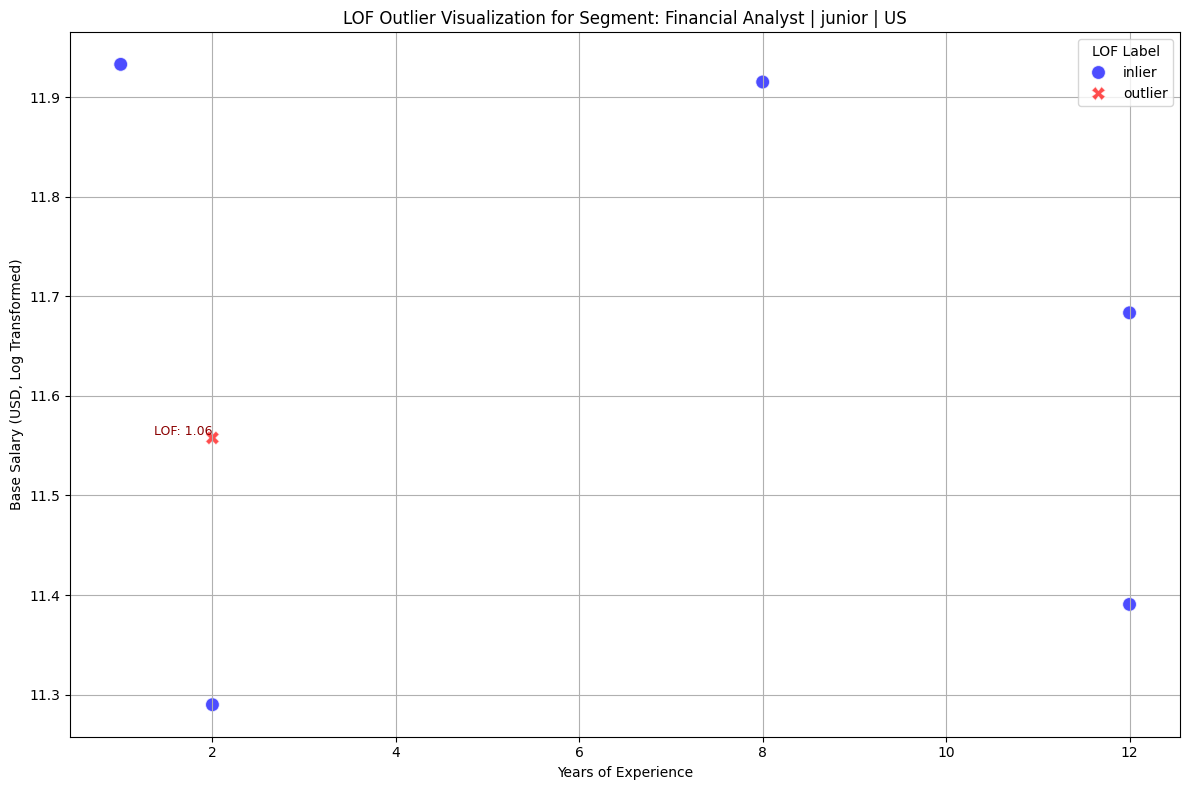

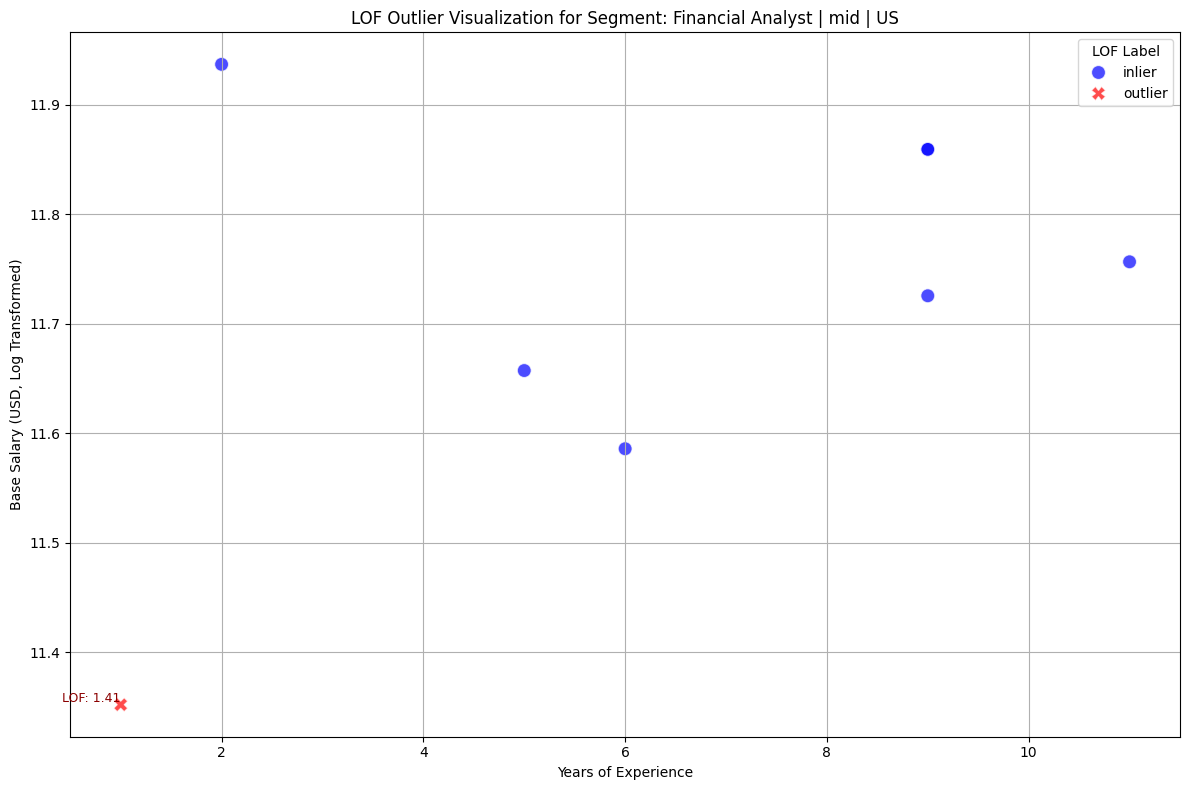

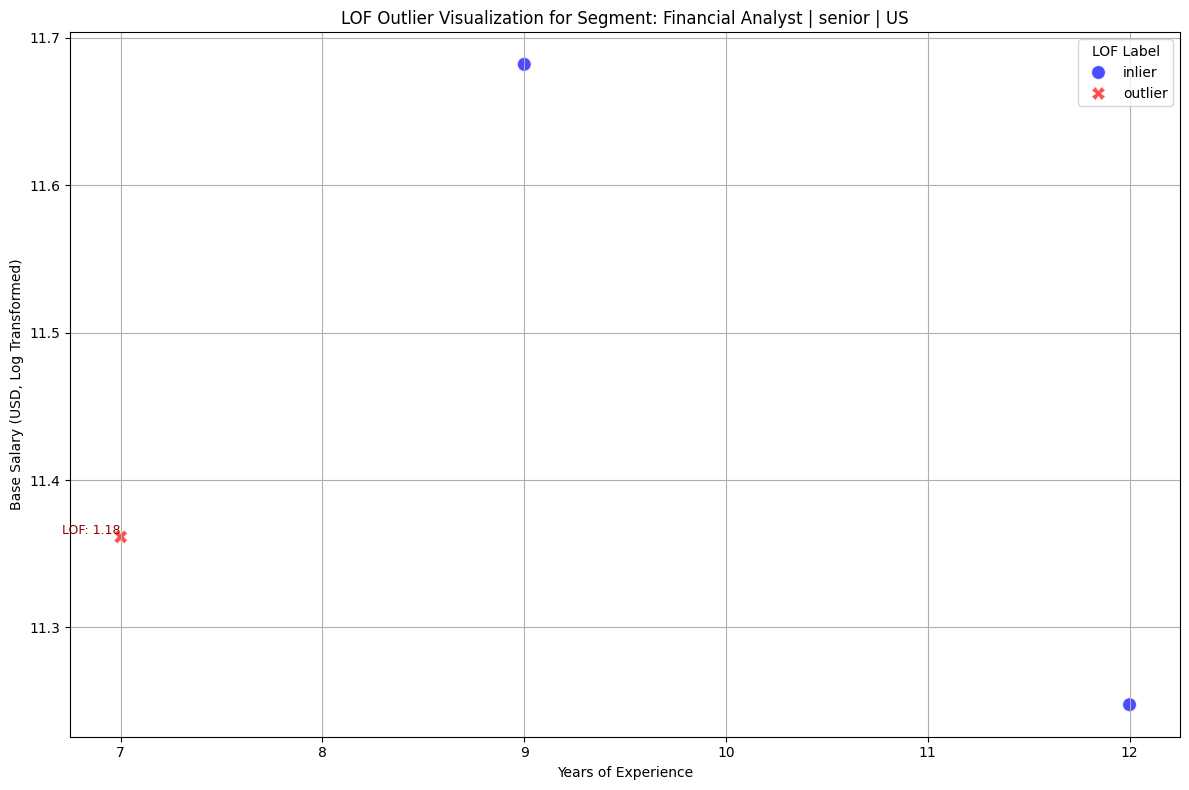


Generating plots for Job Title: Data Scientist


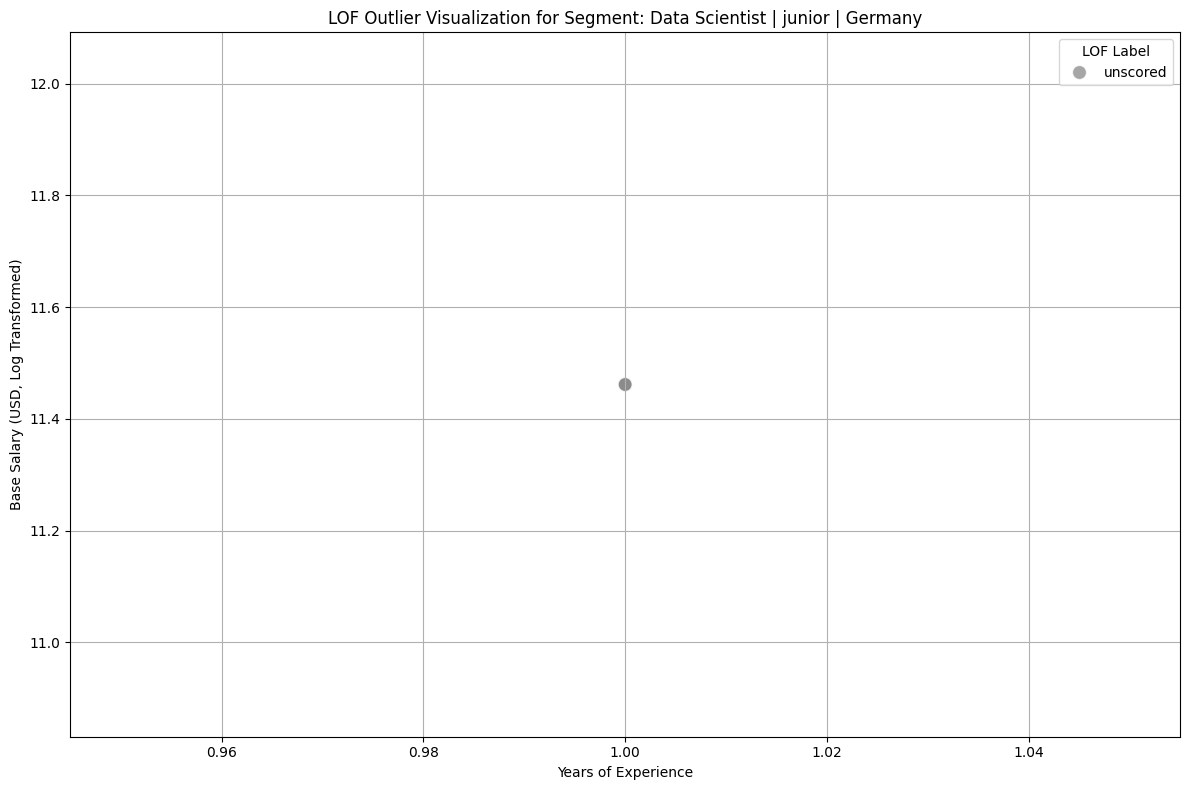

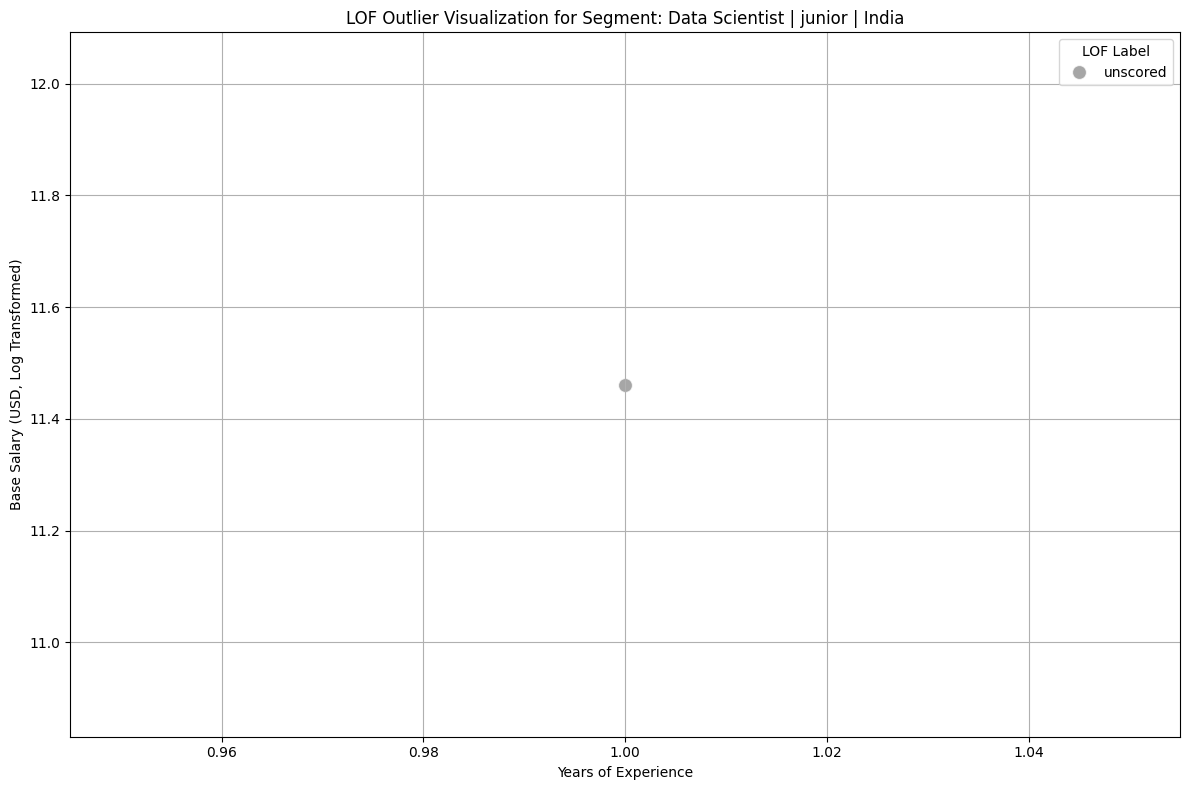

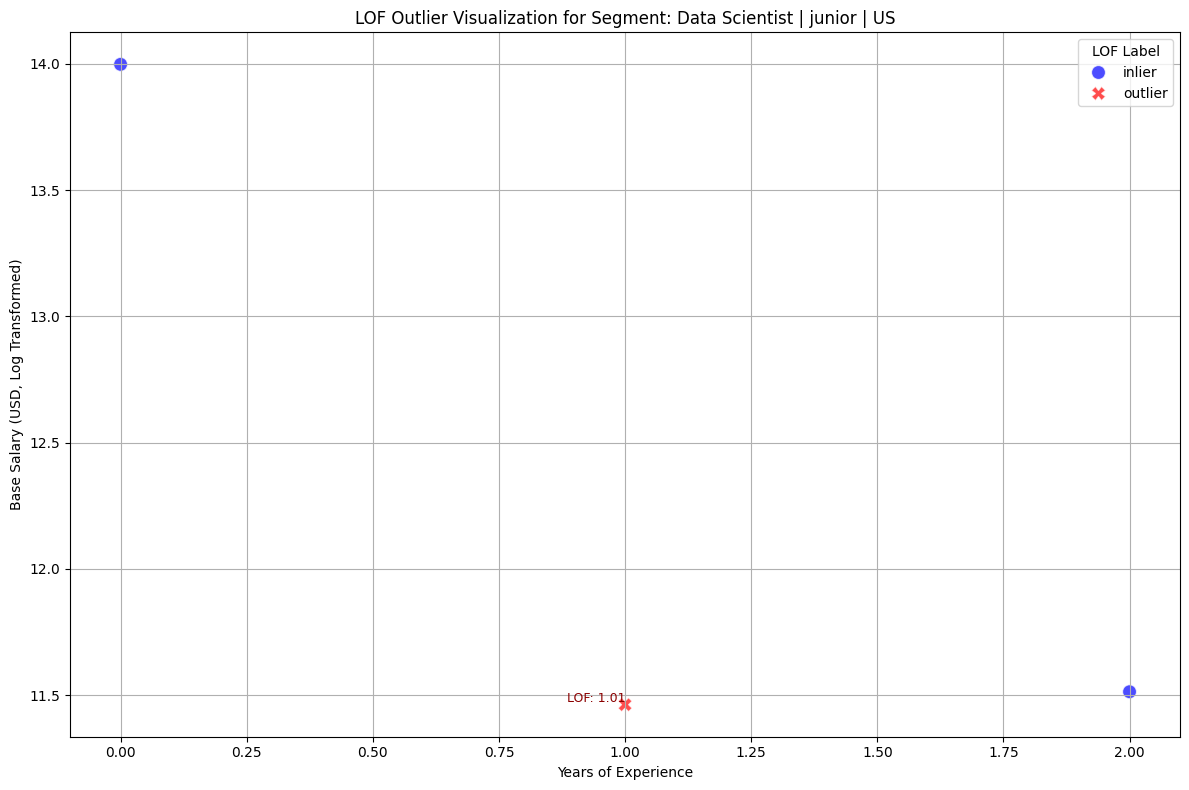

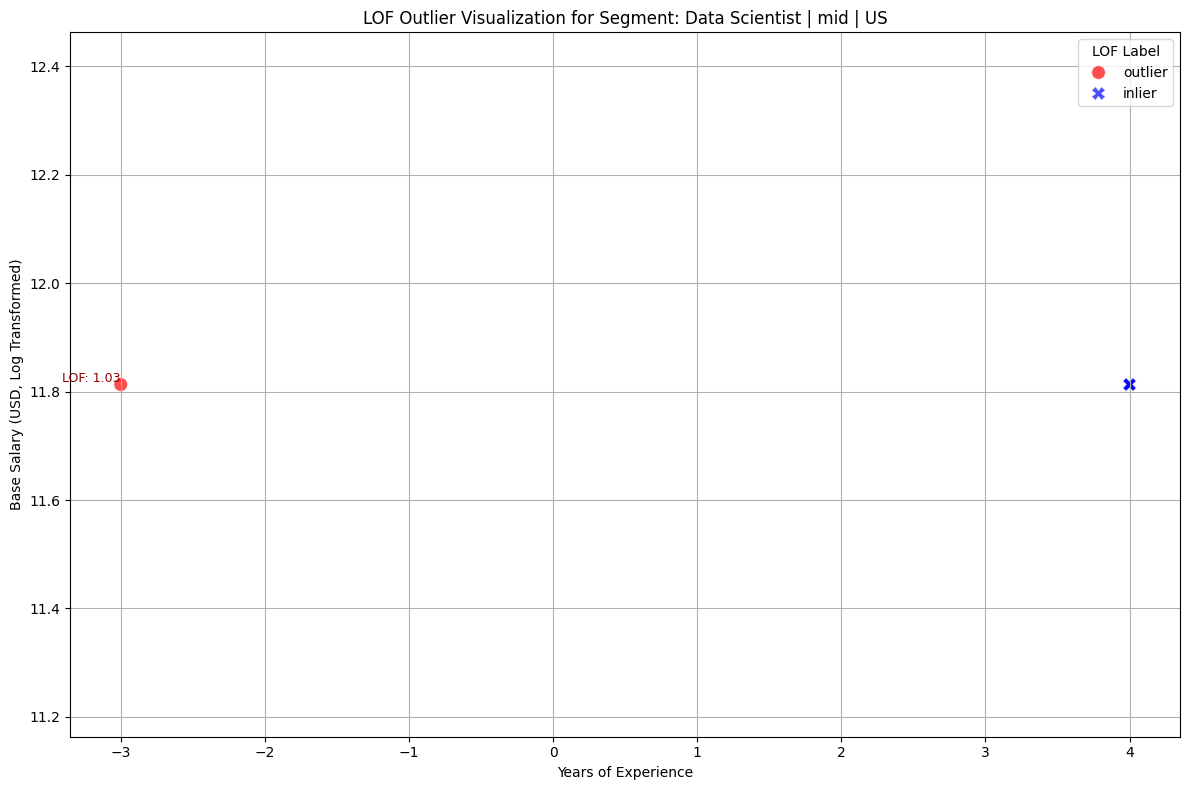

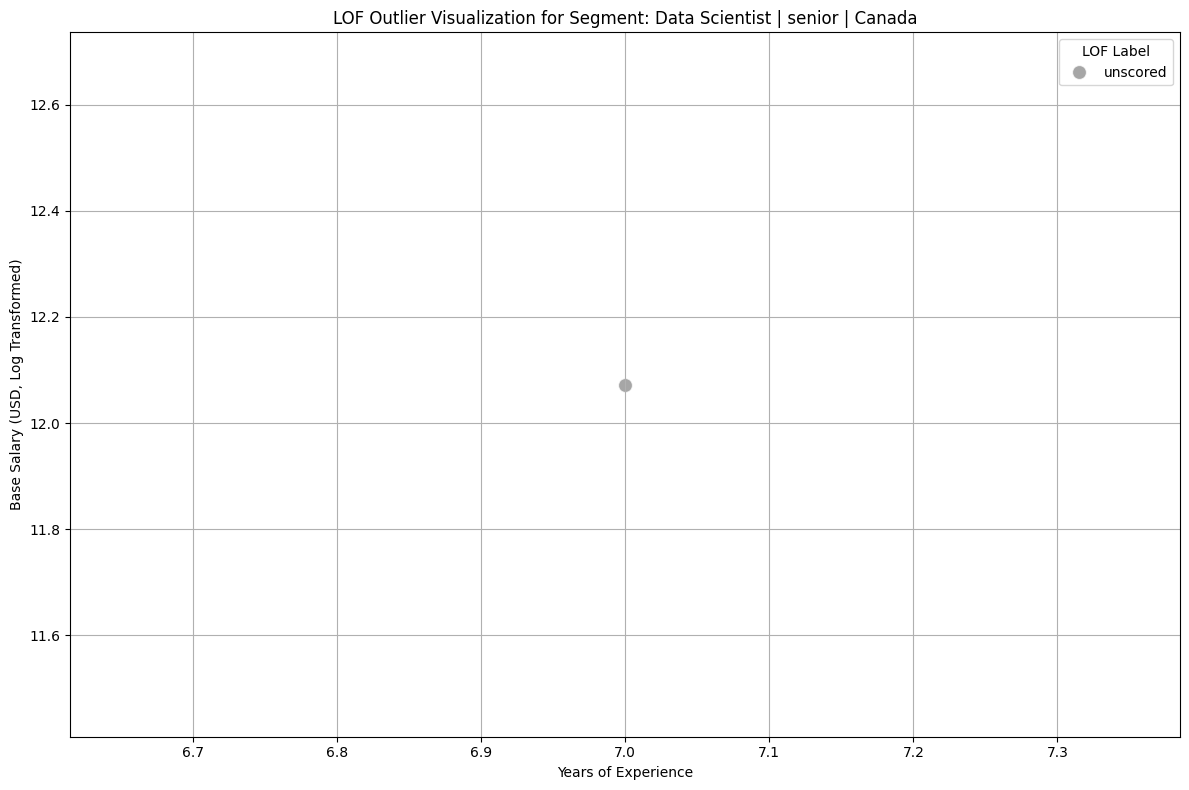

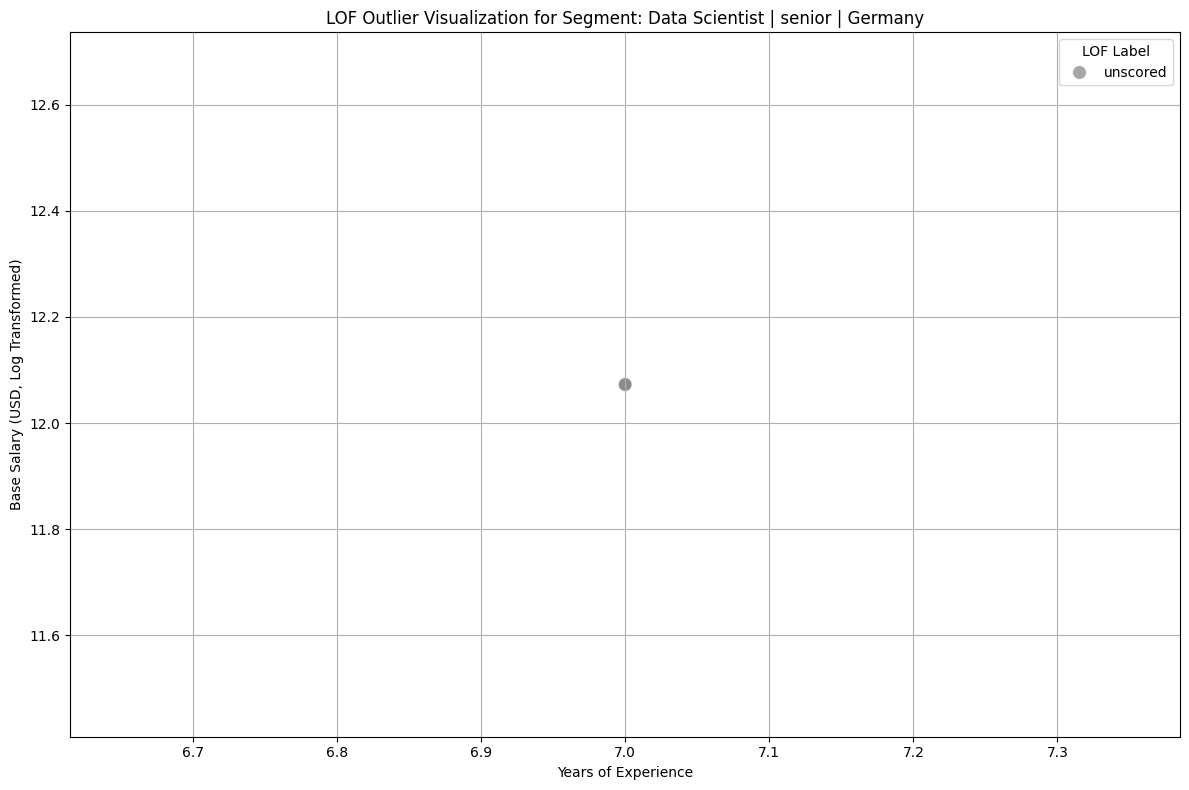

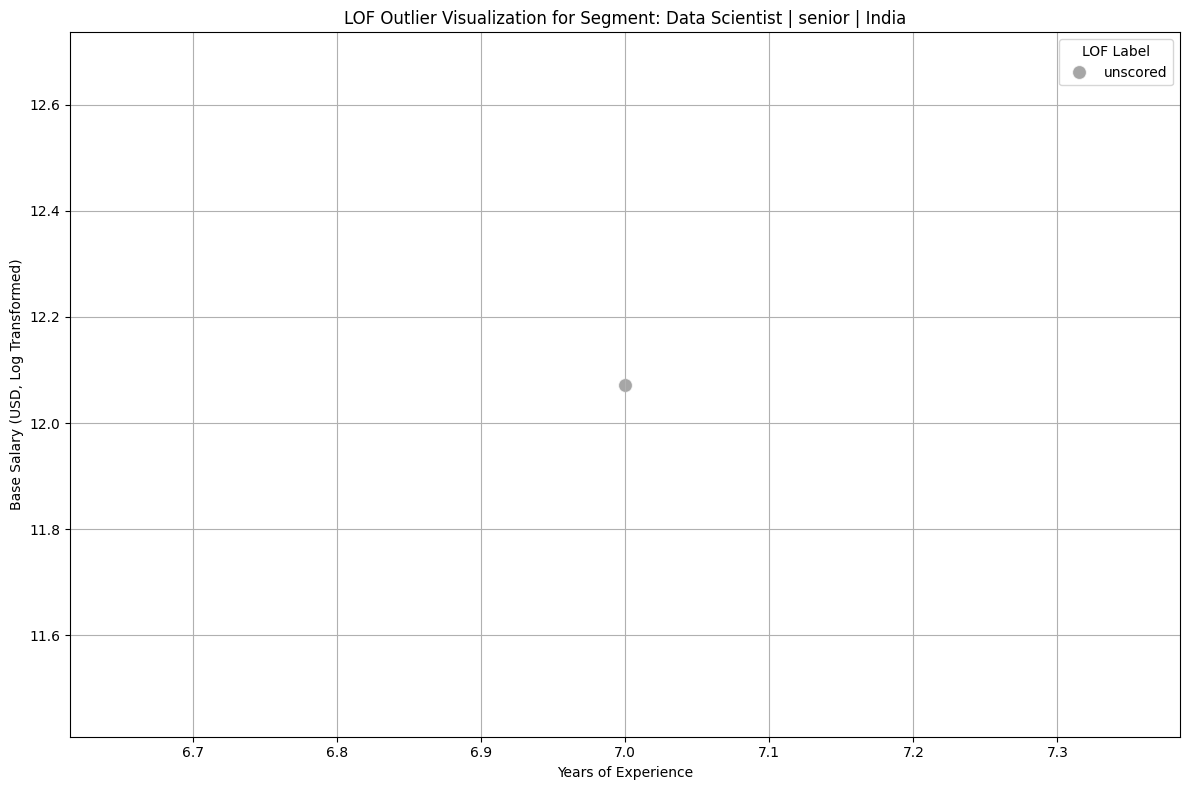

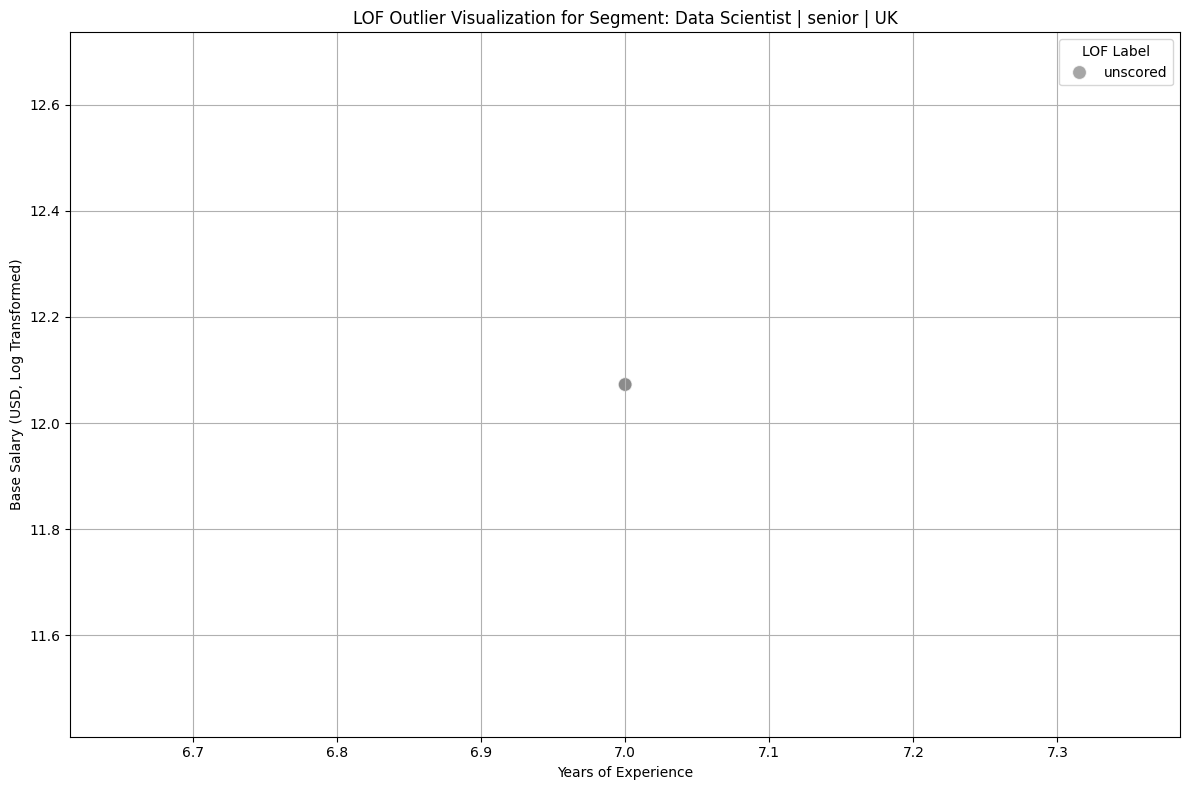

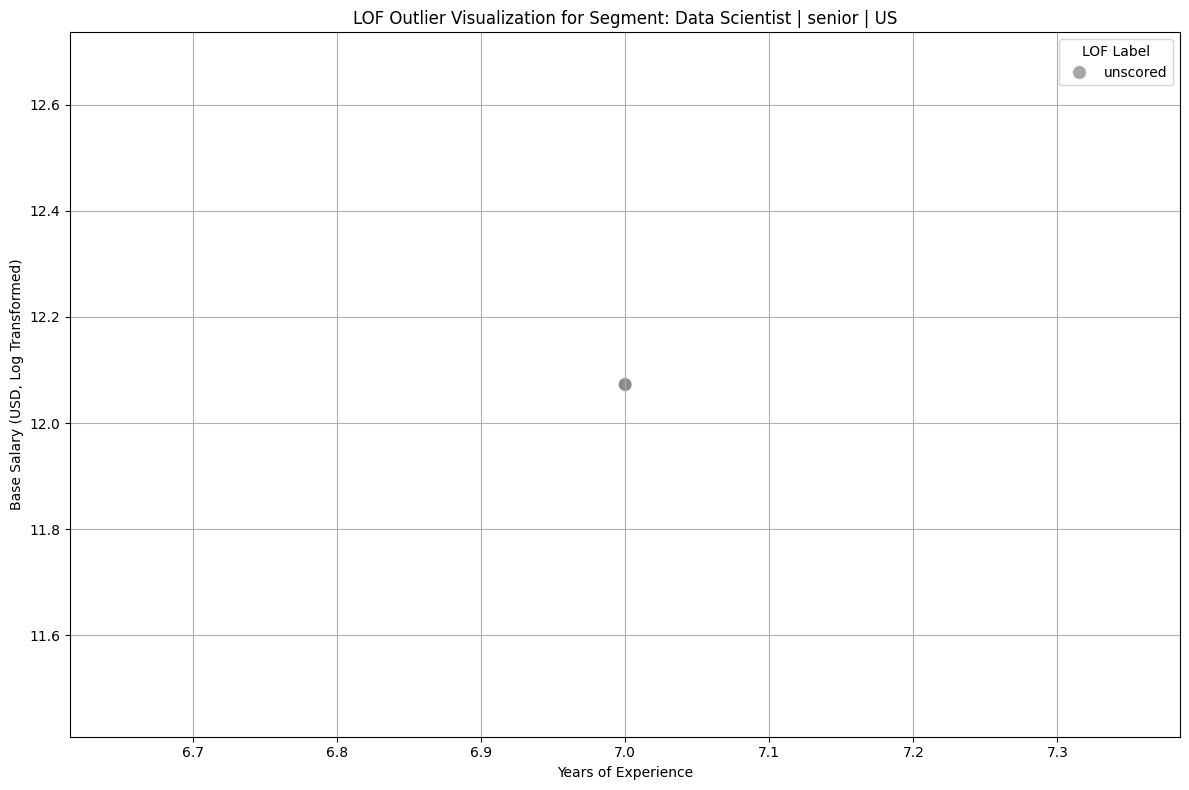

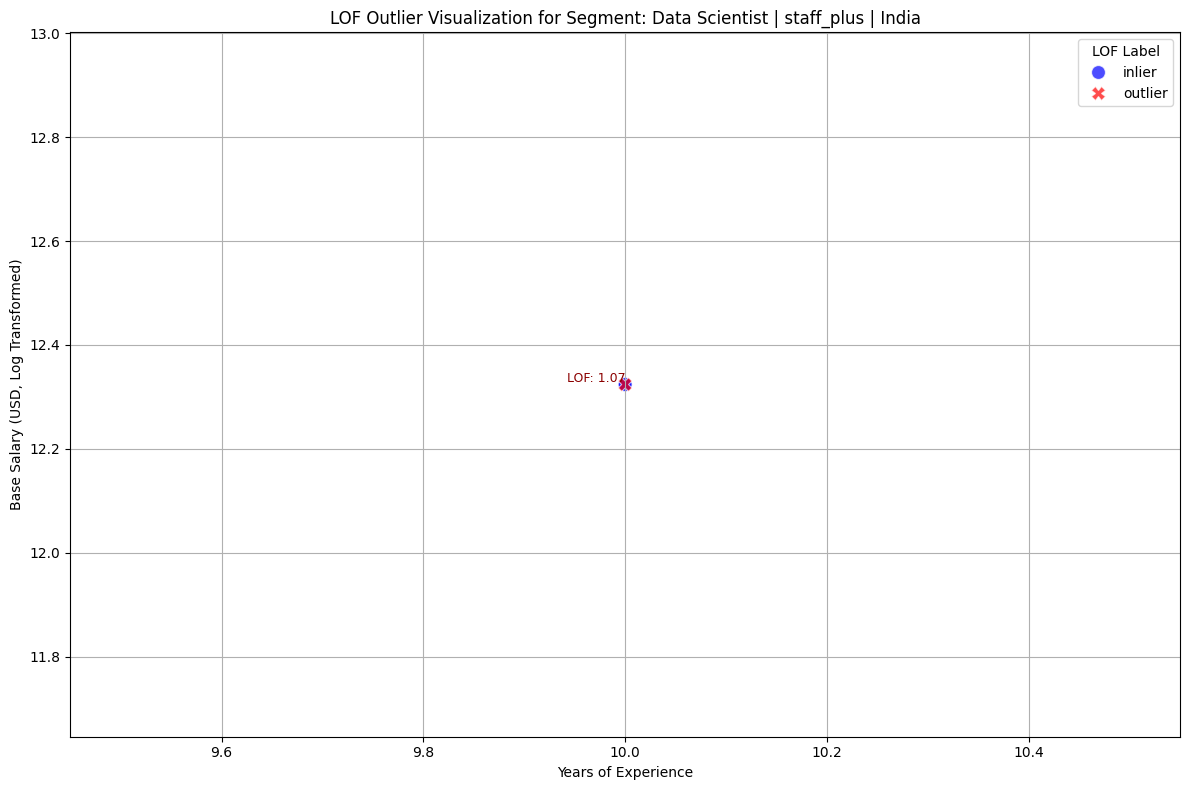

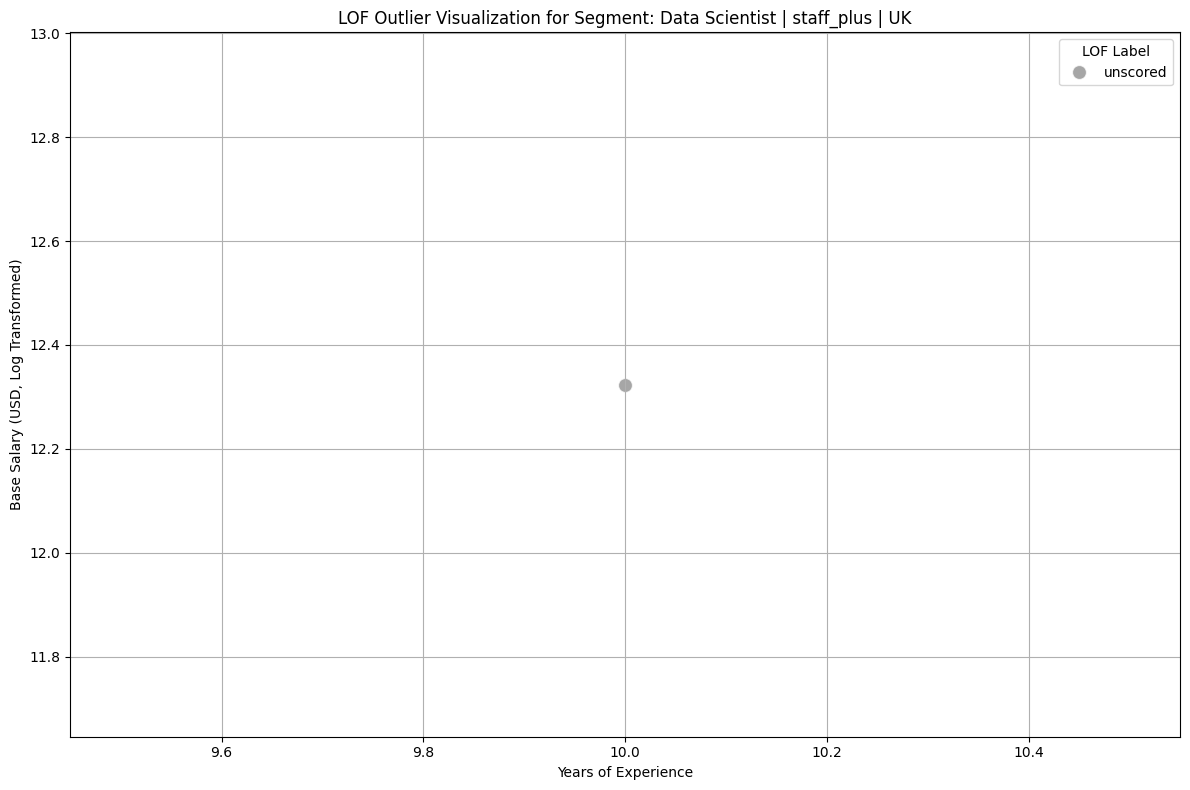

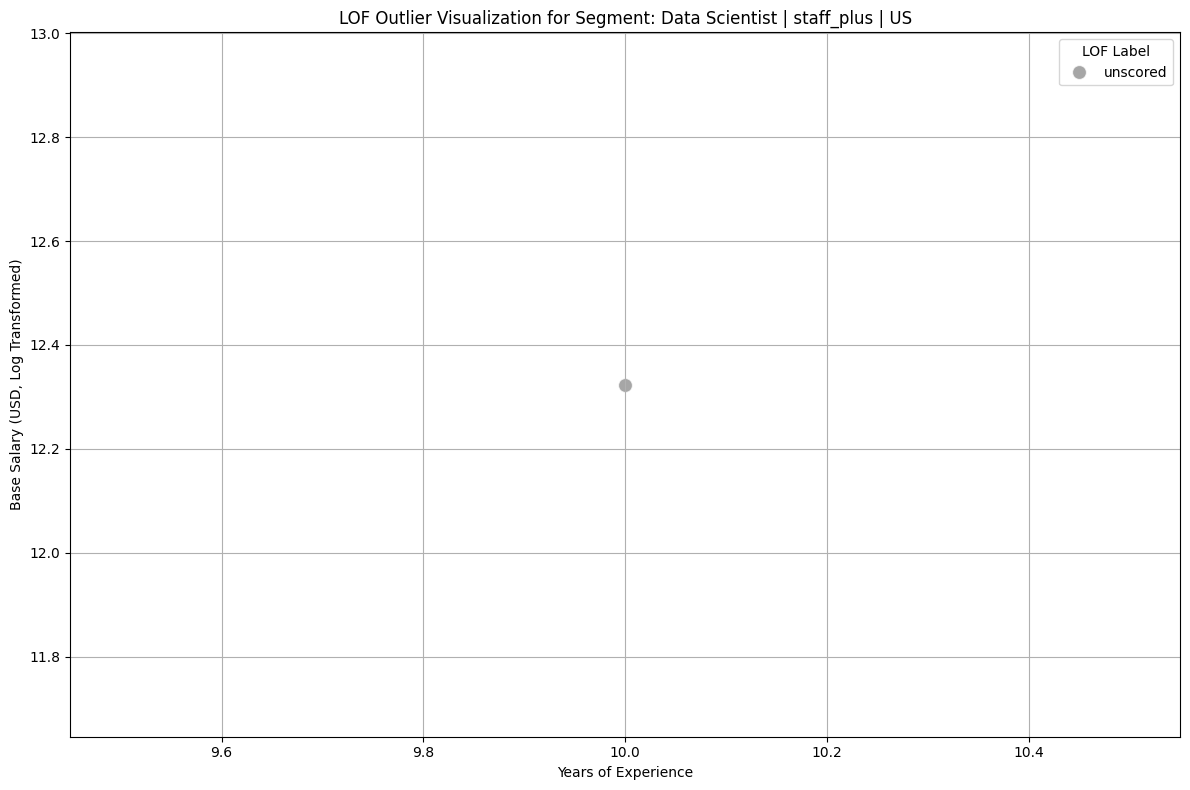


Generating plots for Job Title: Business Operations


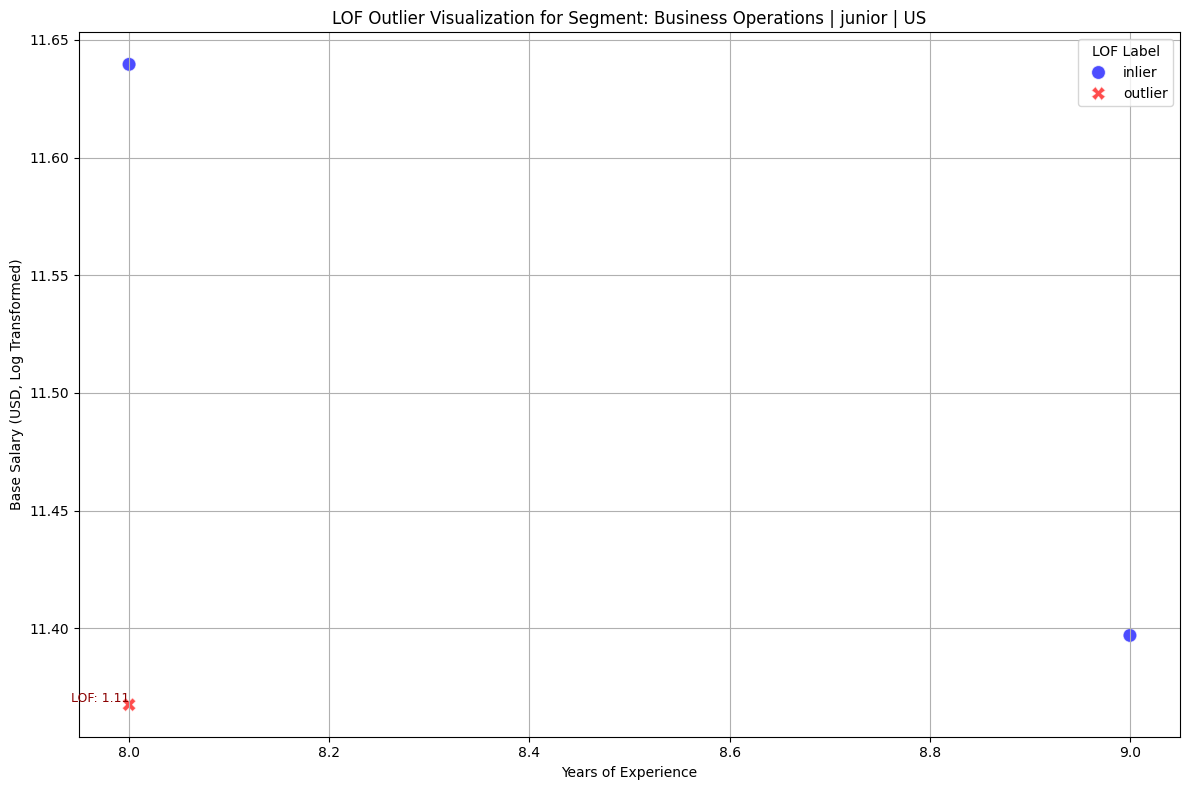

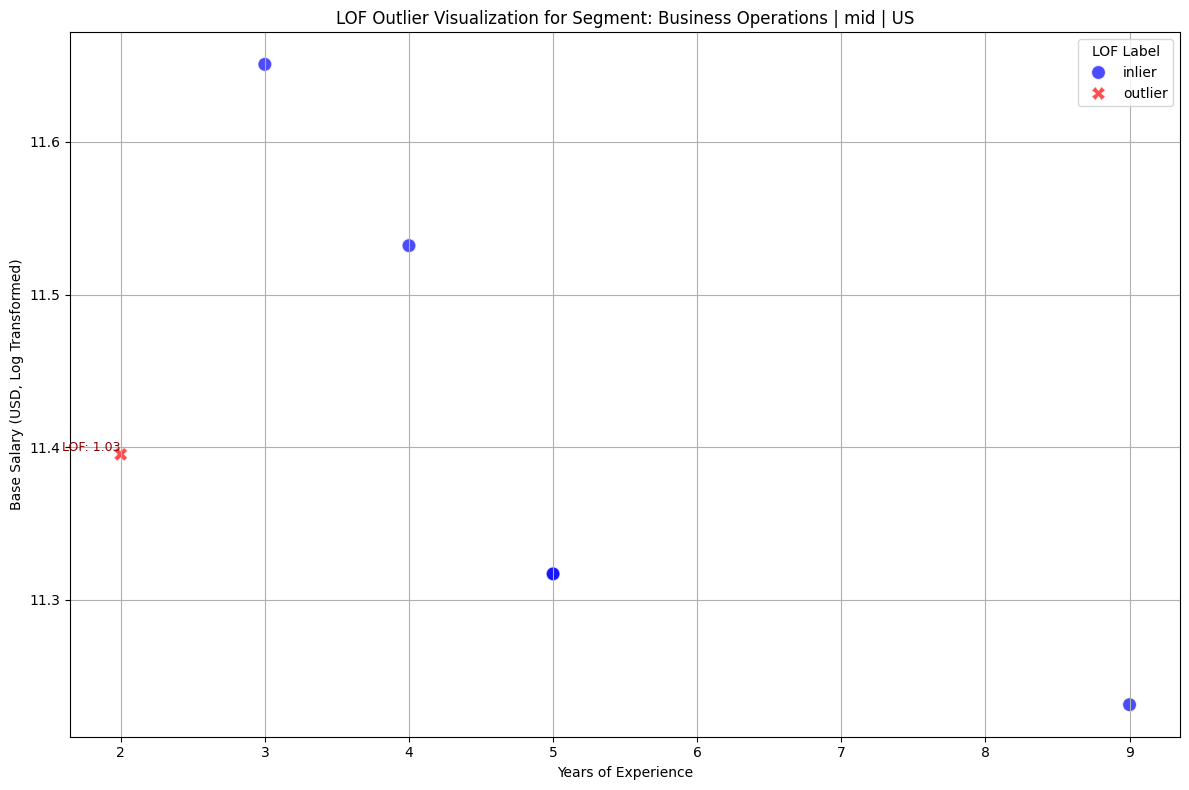

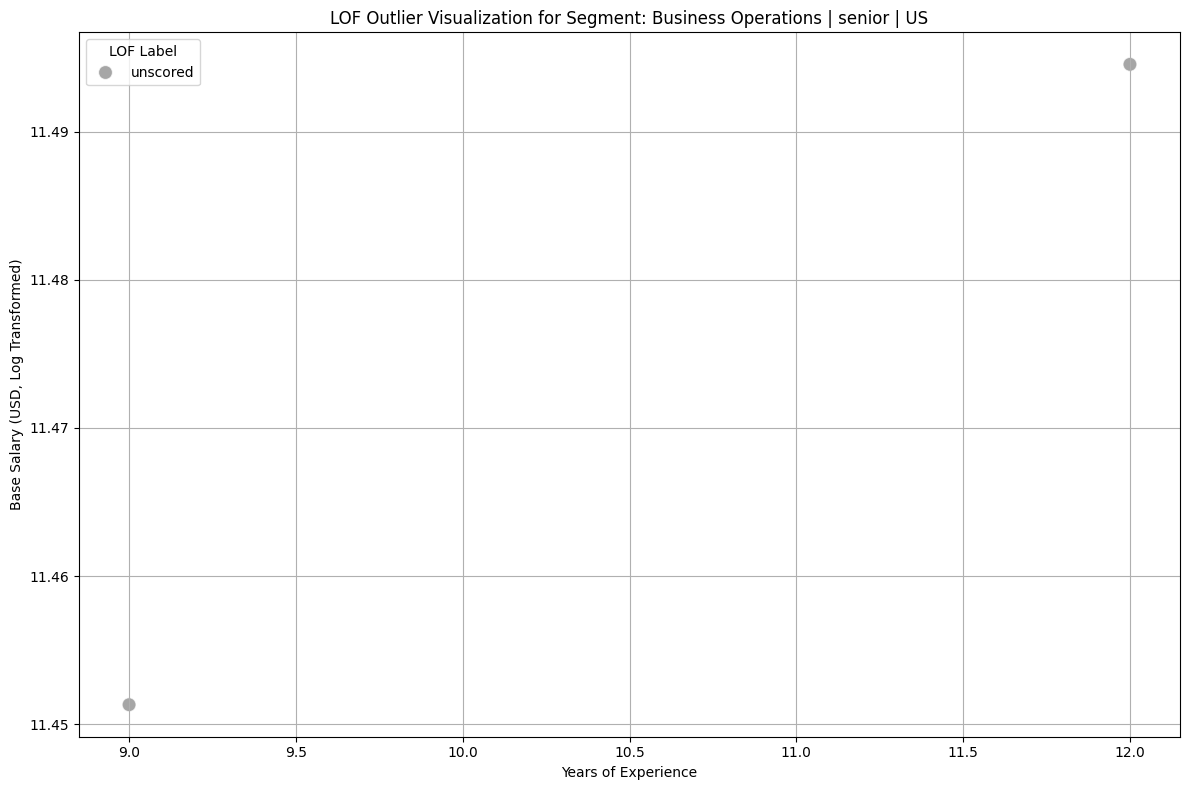


Generating plots for Job Title: Biomedical Engineer


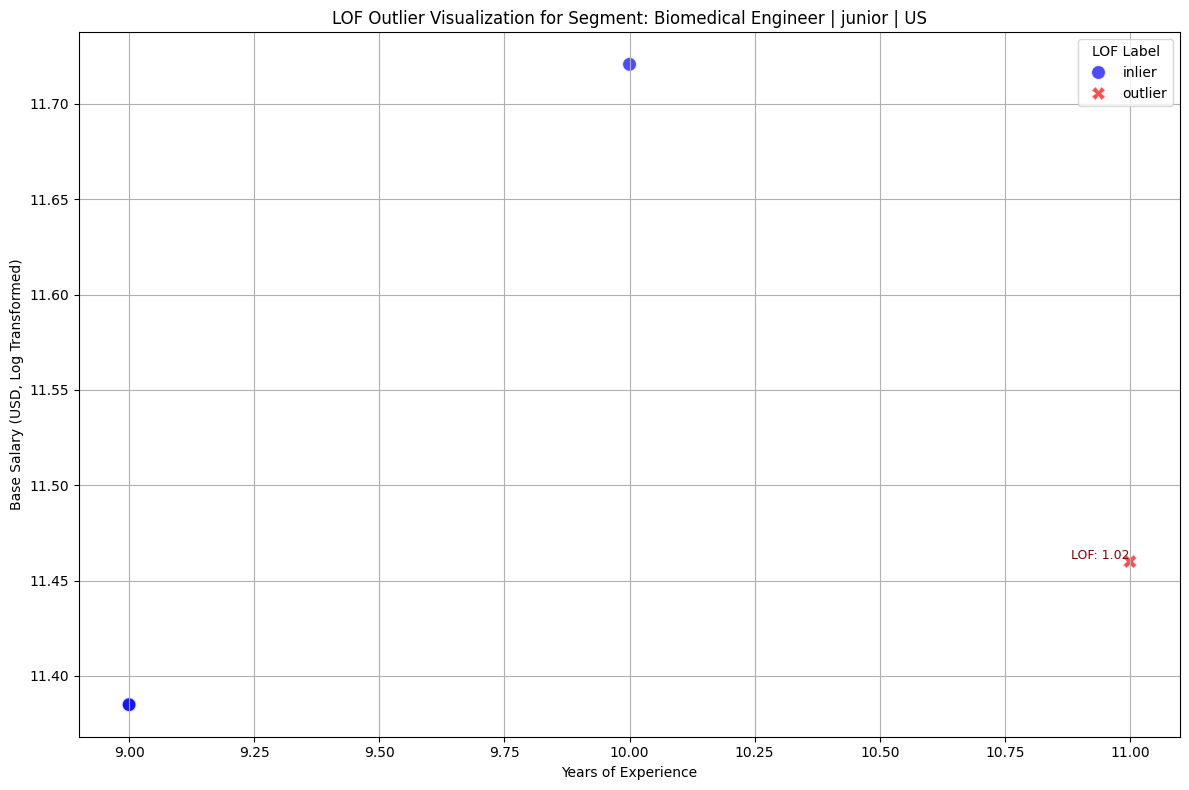

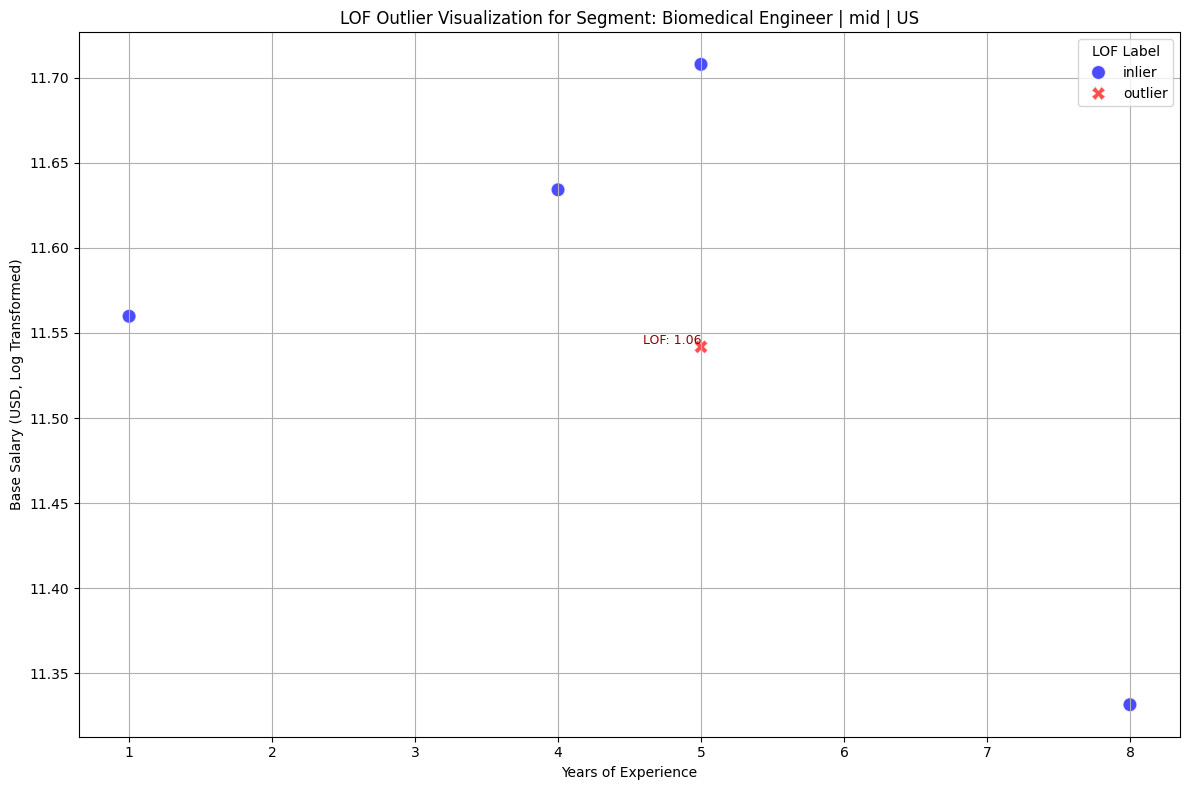

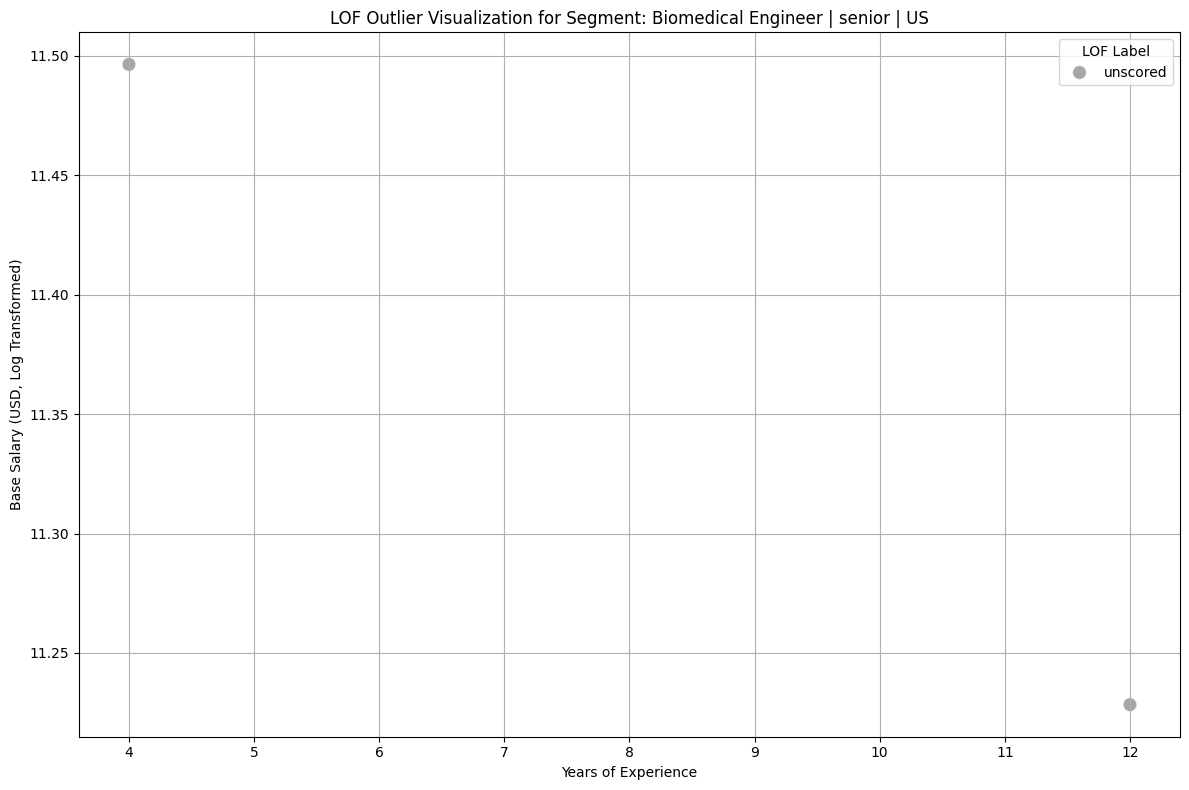


Generating plots for Job Title: Industrial Designer


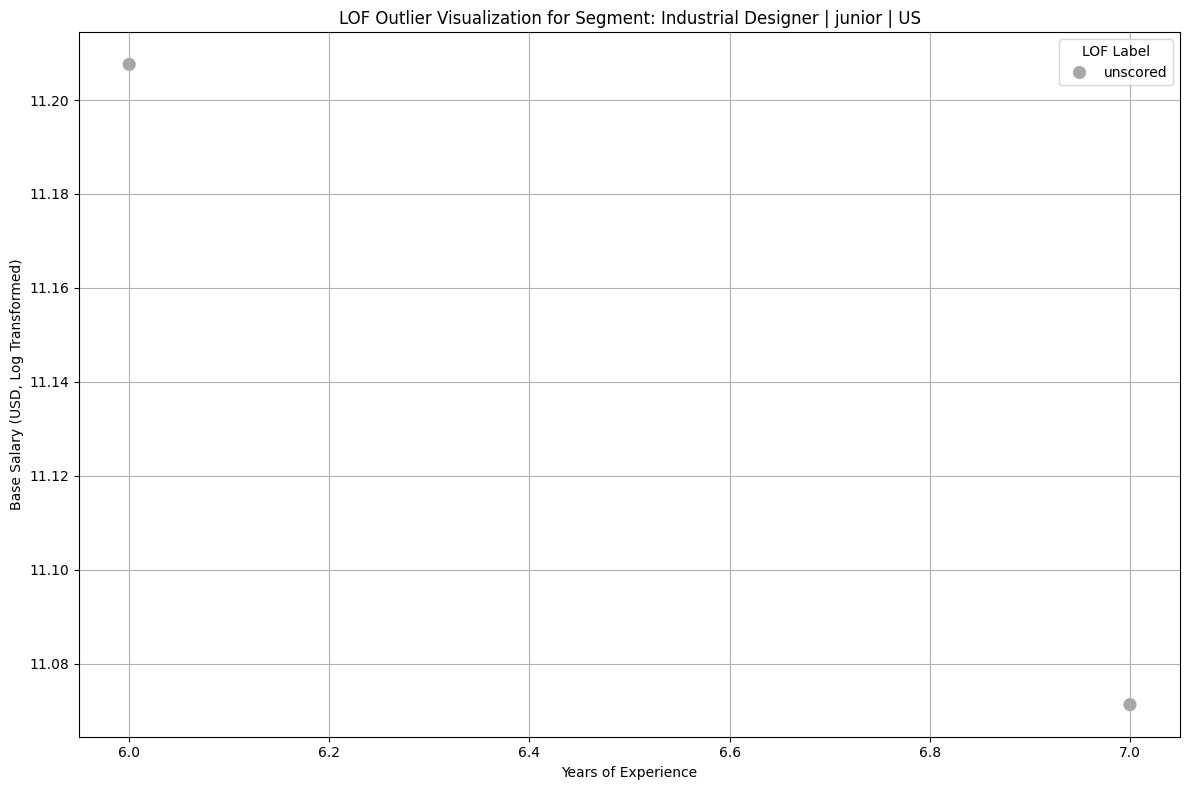

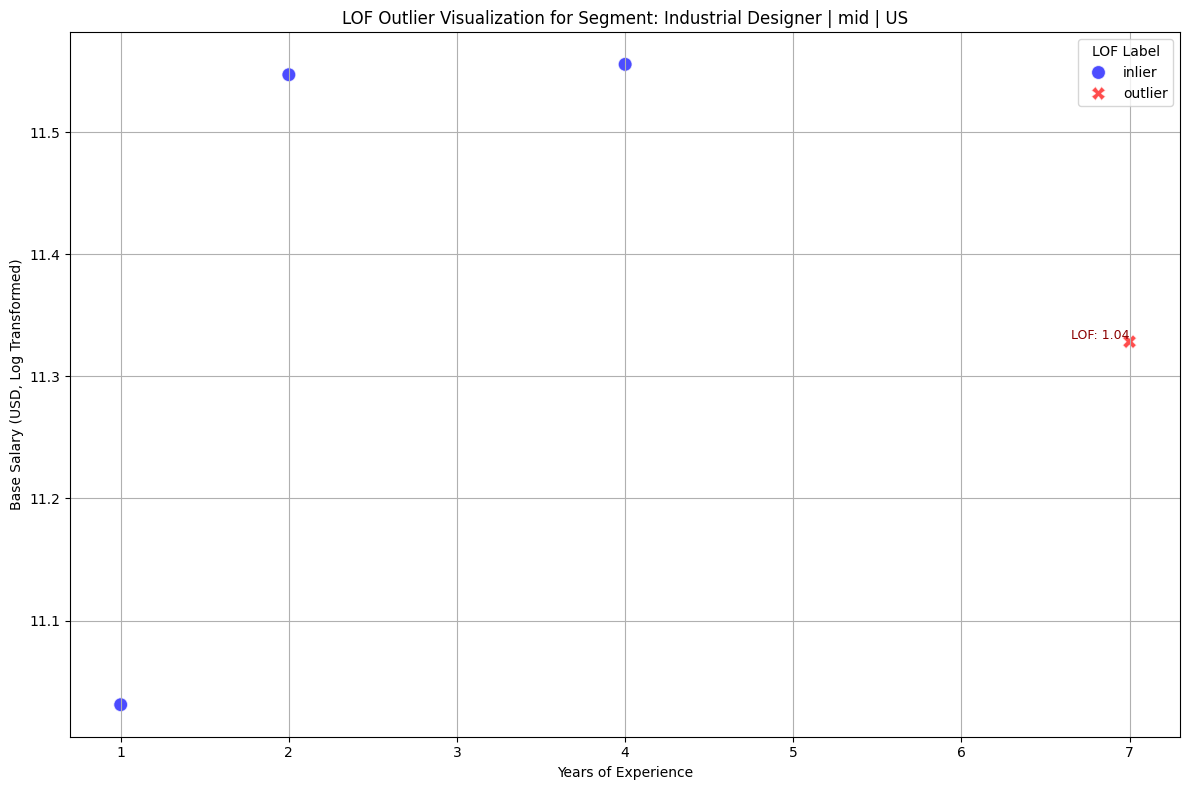

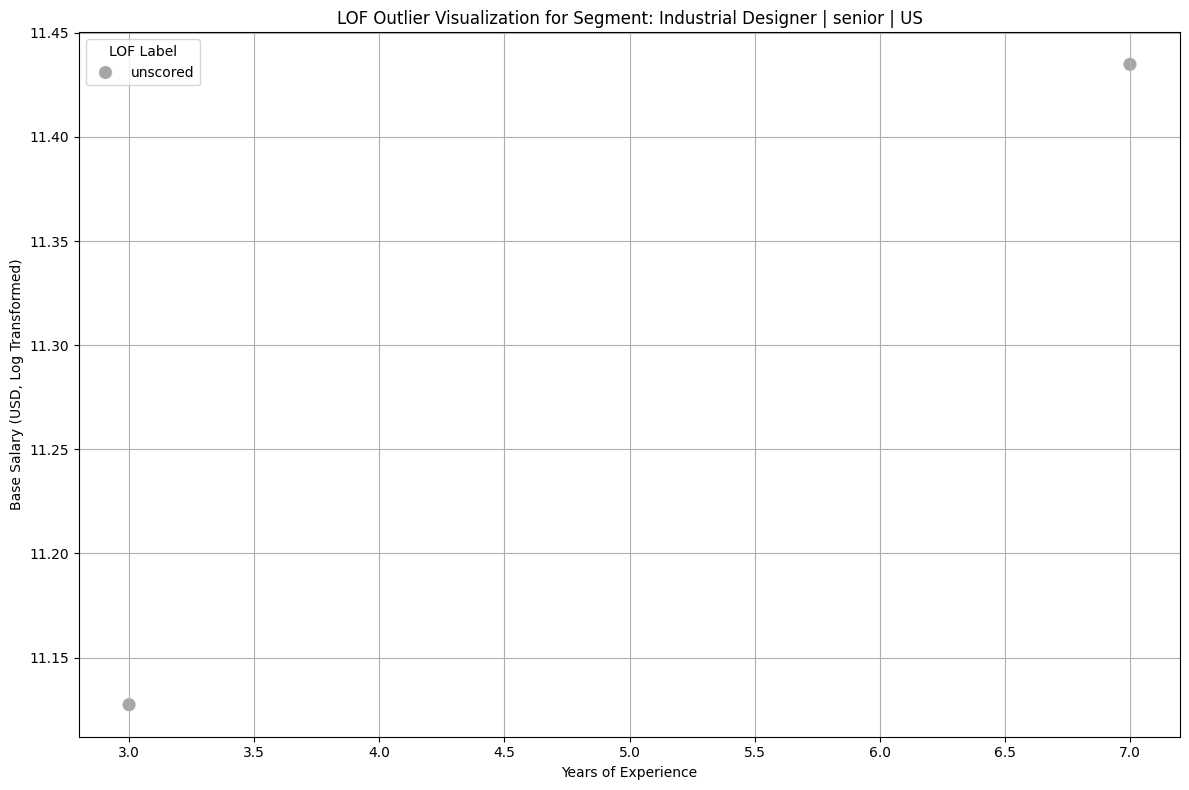


Generating plots for Job Title: Venture Capitalist


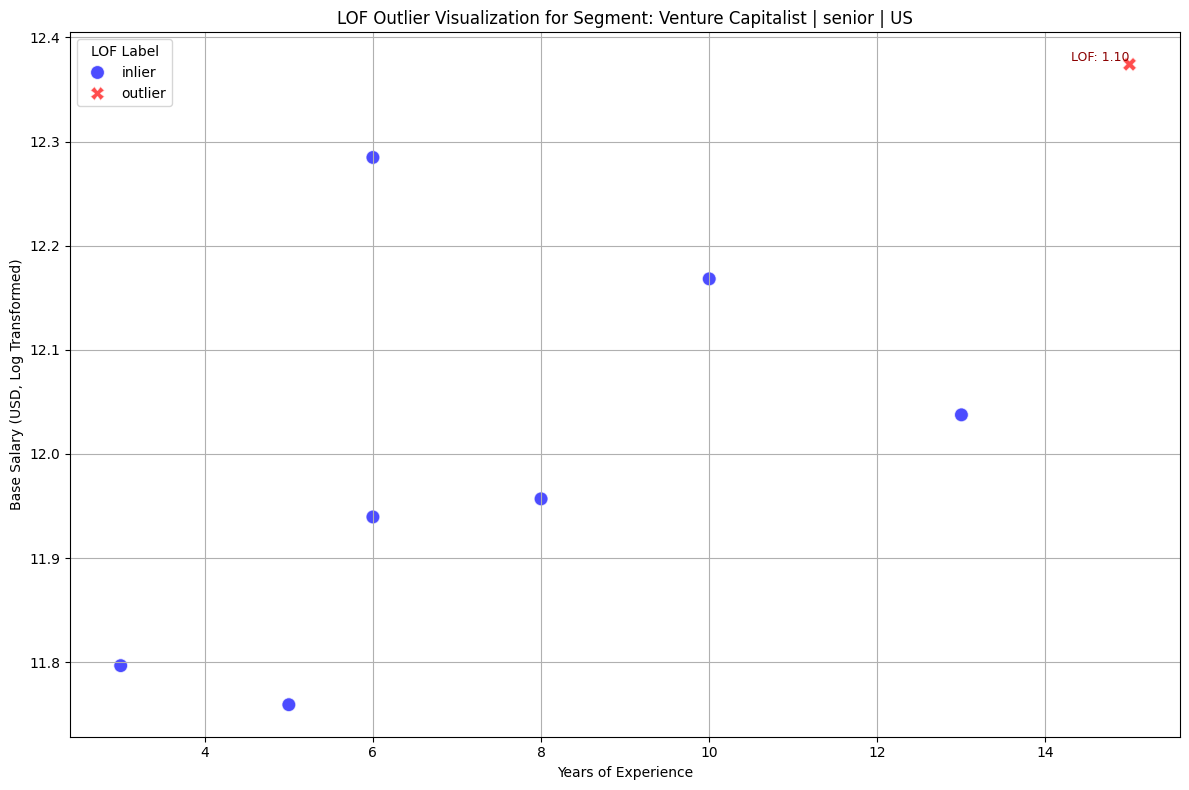


Generating plots for Job Title: Product Manager


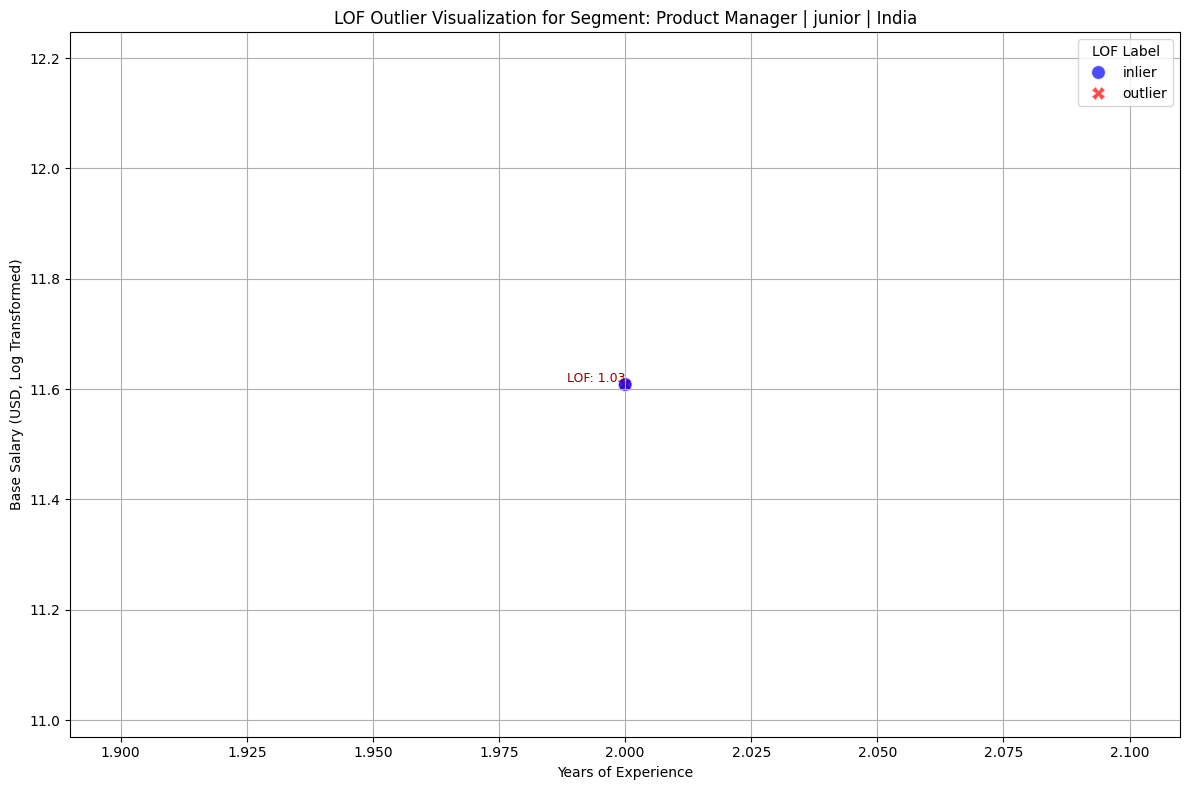

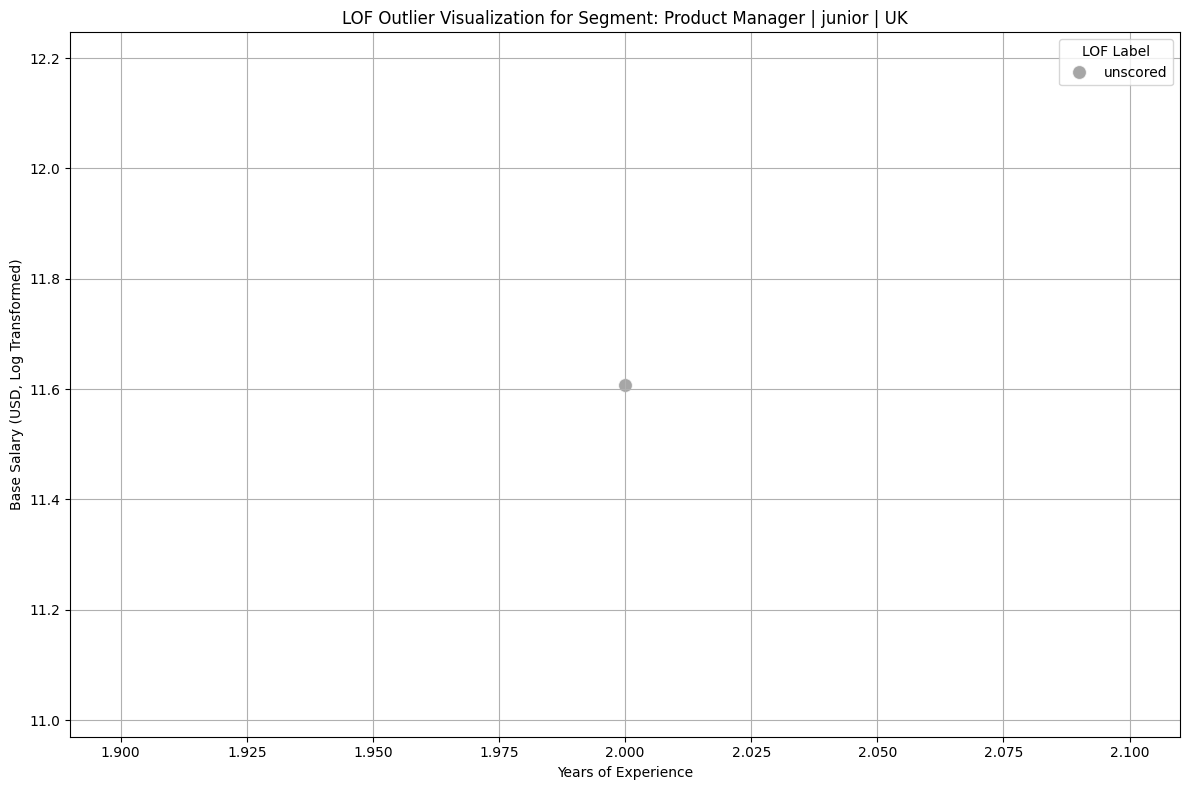

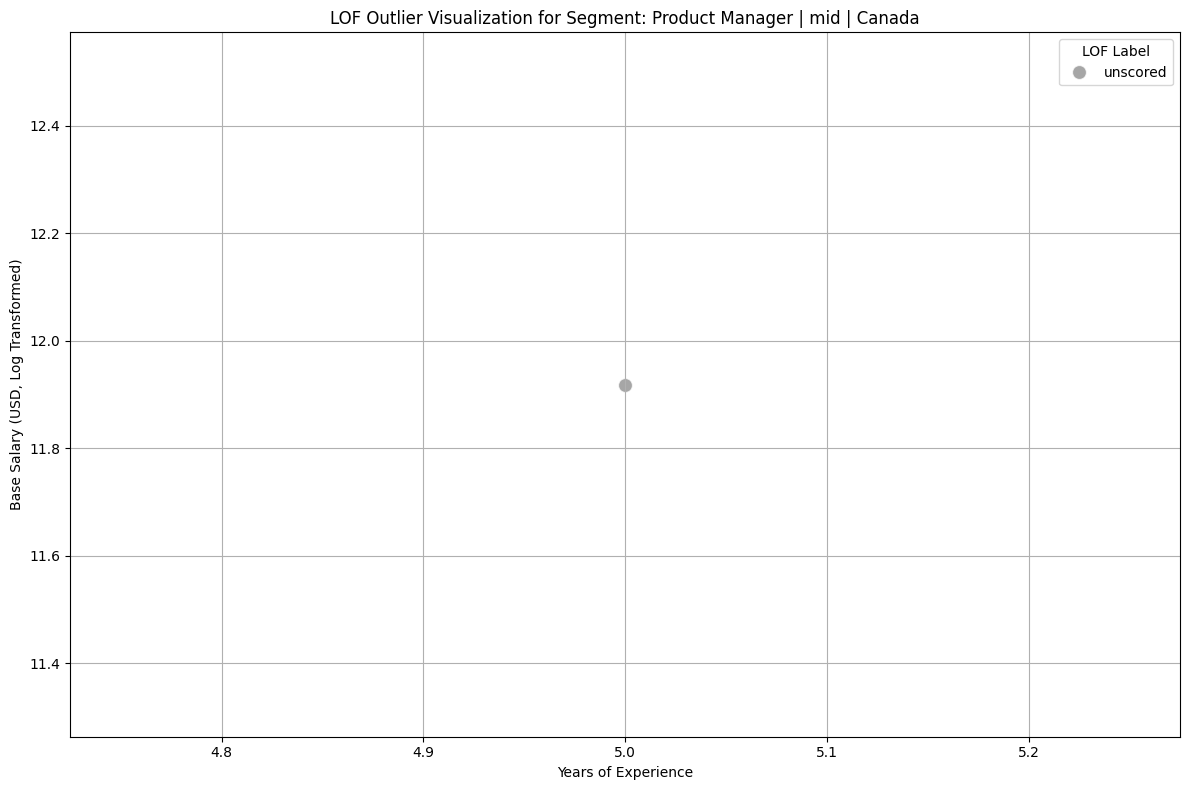

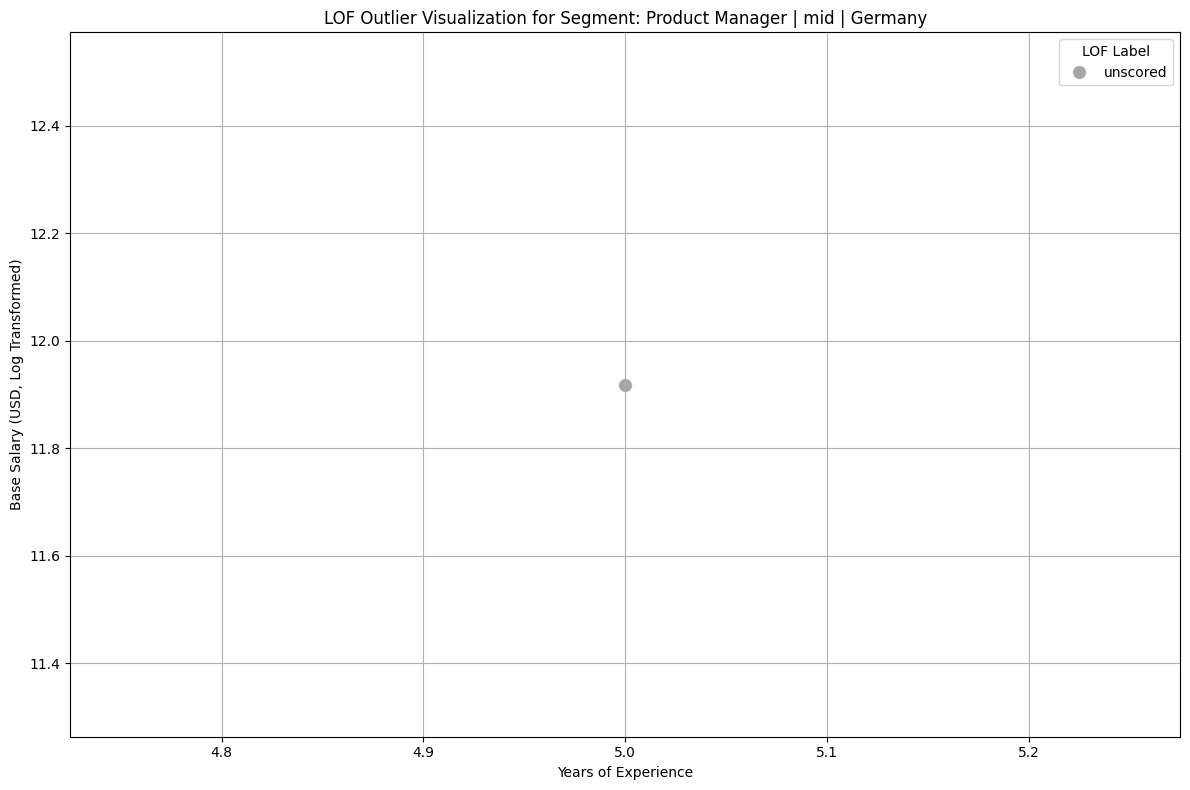

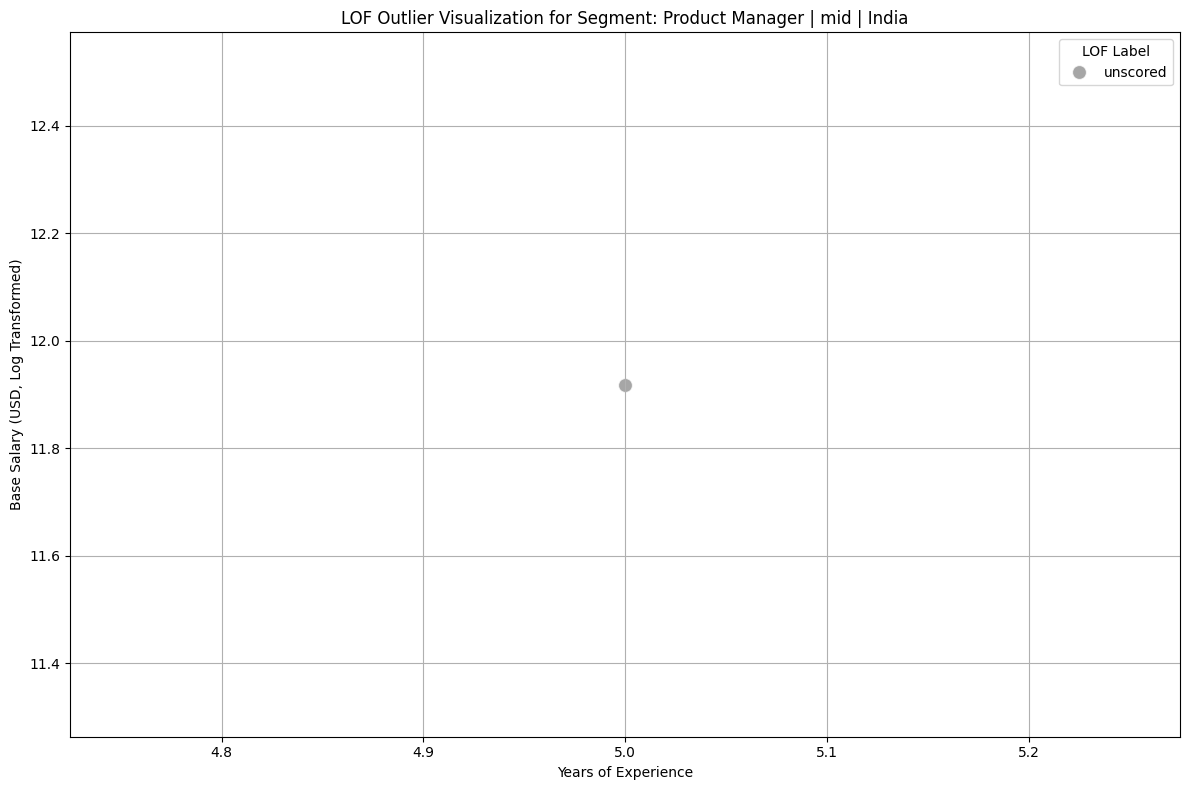

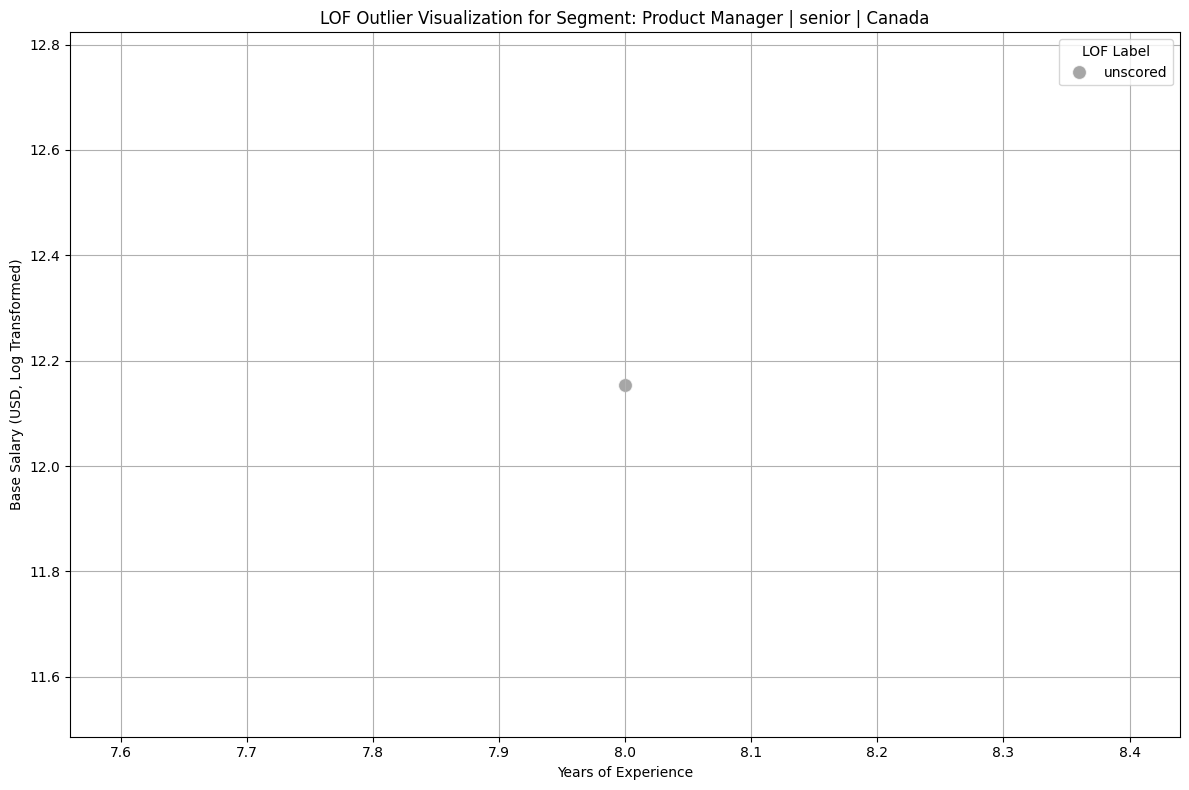

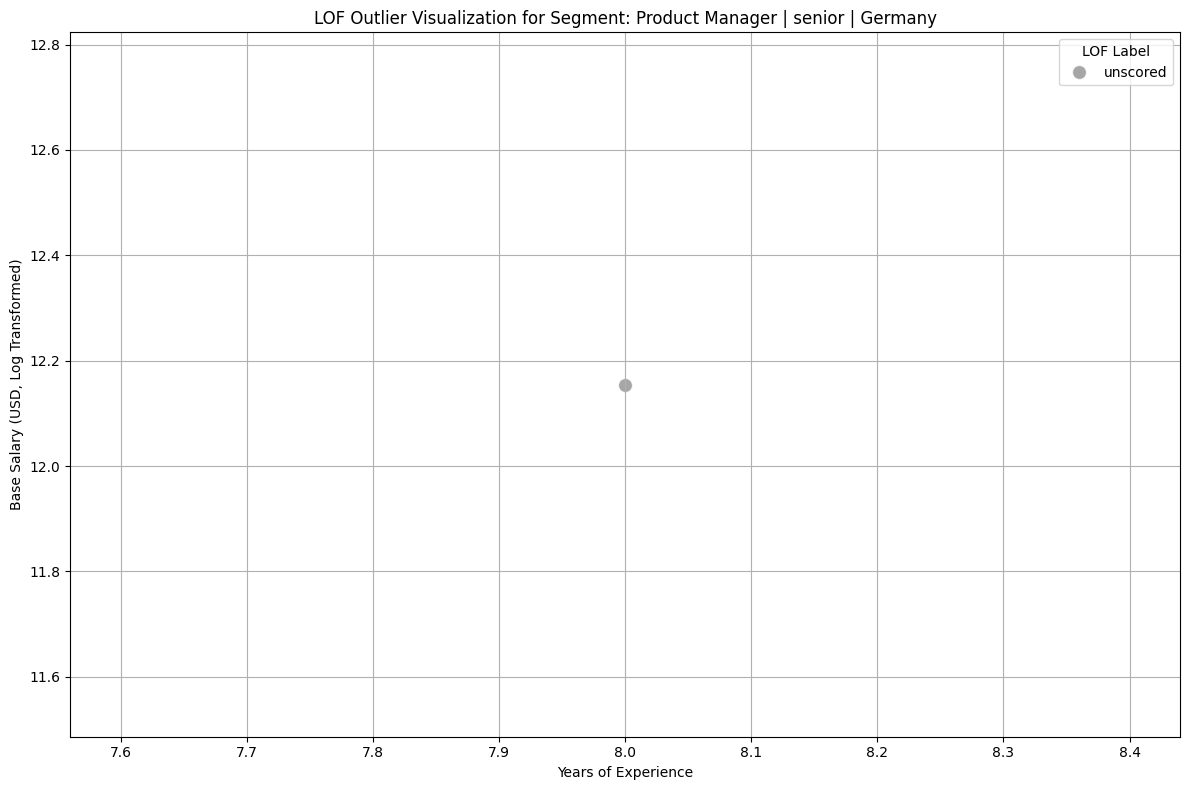

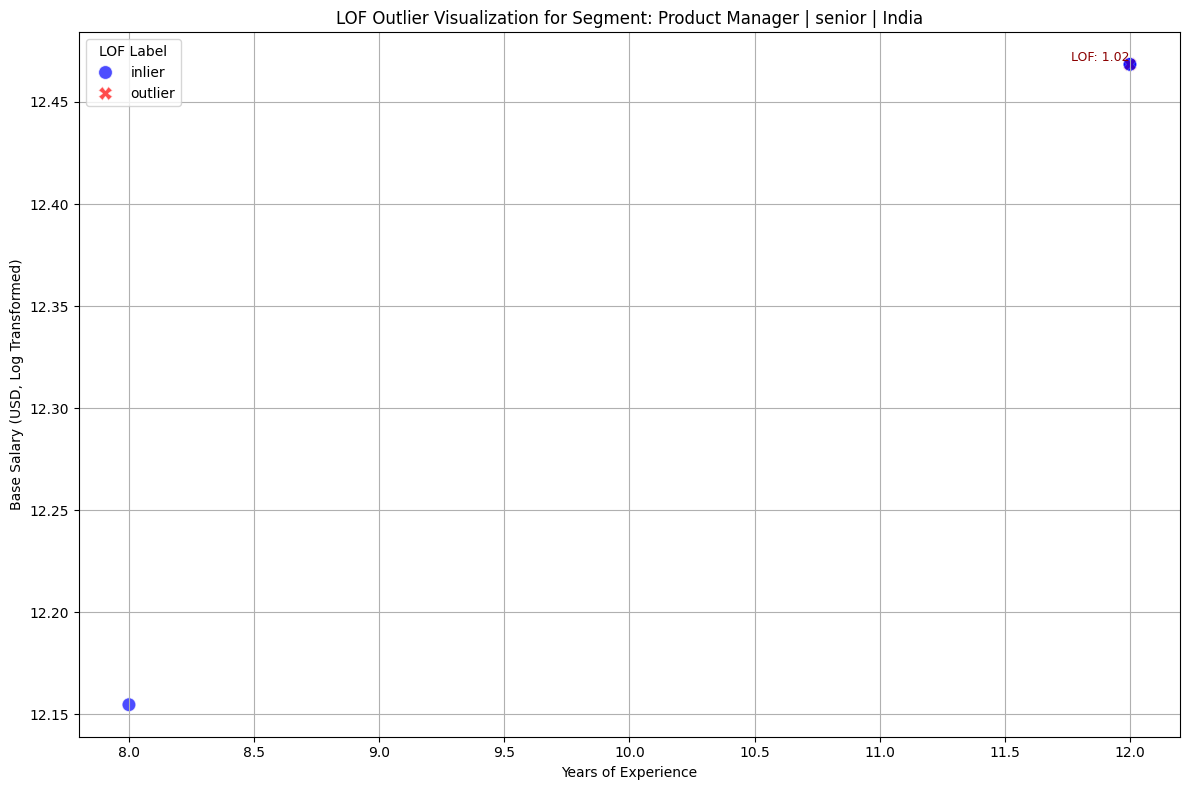

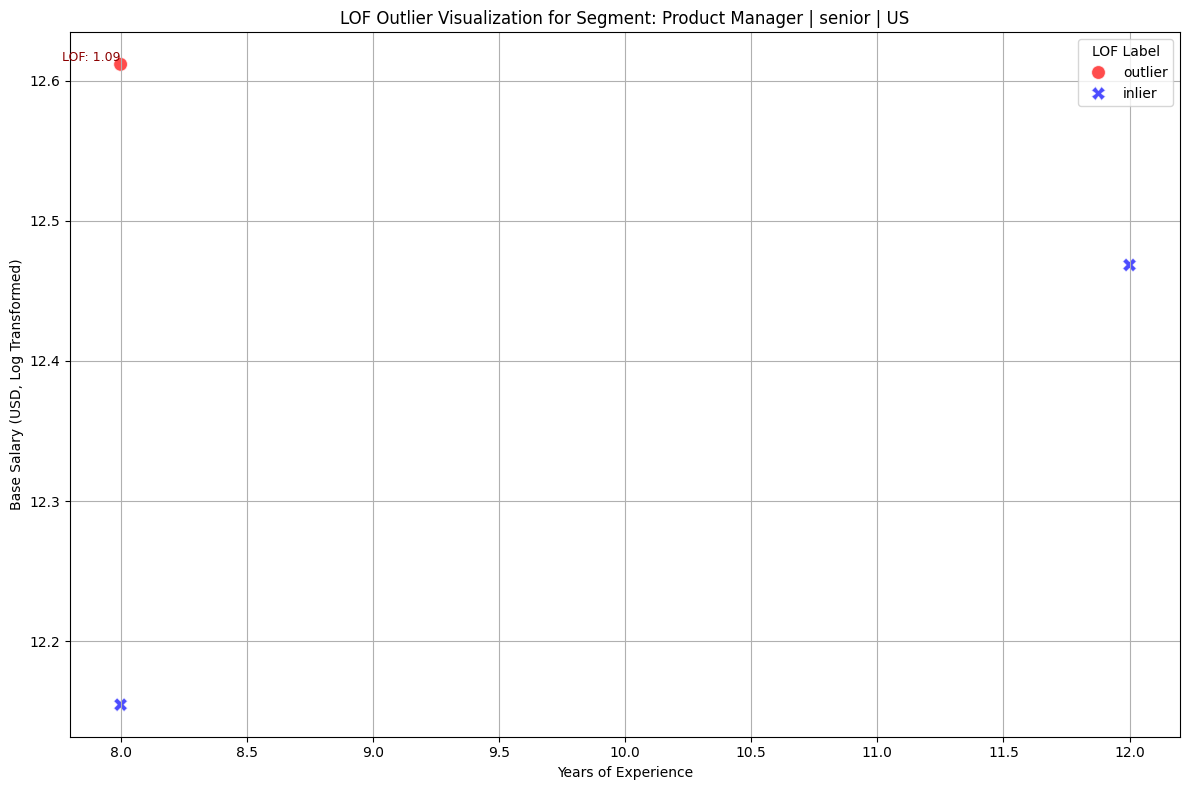


Generating plots for Job Title: Accountant


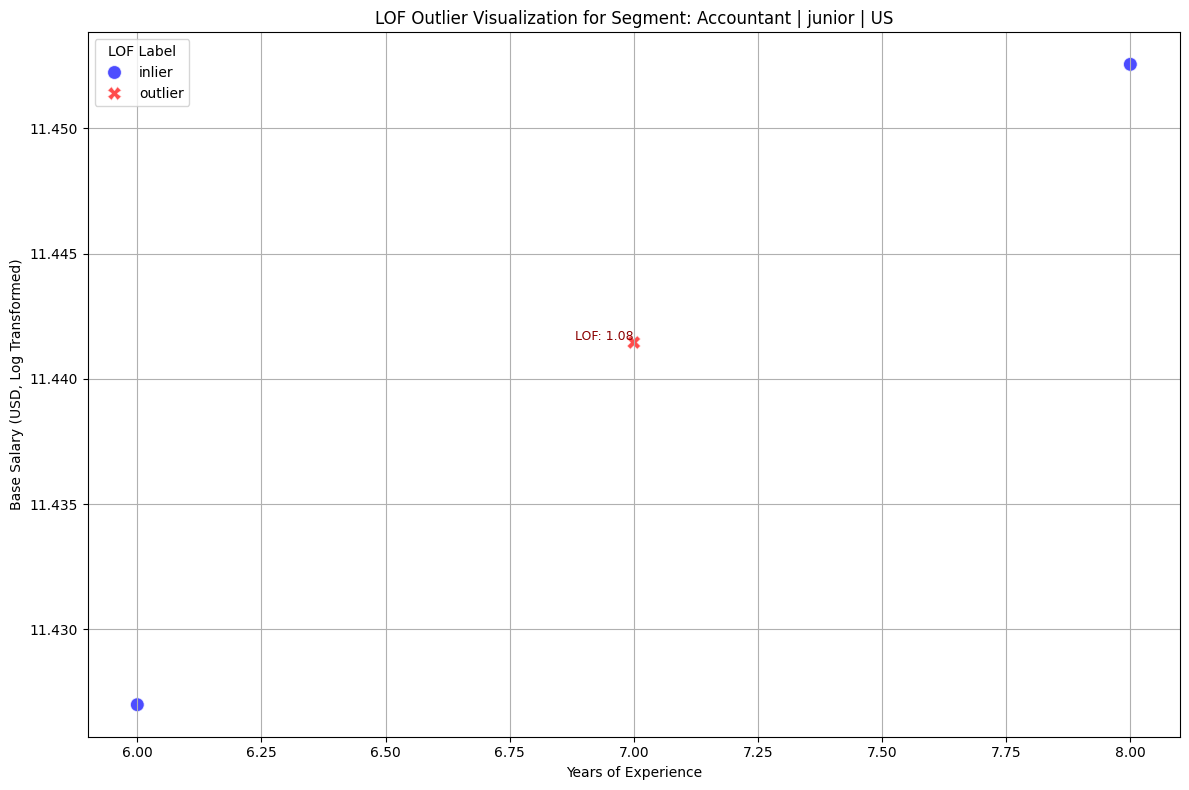

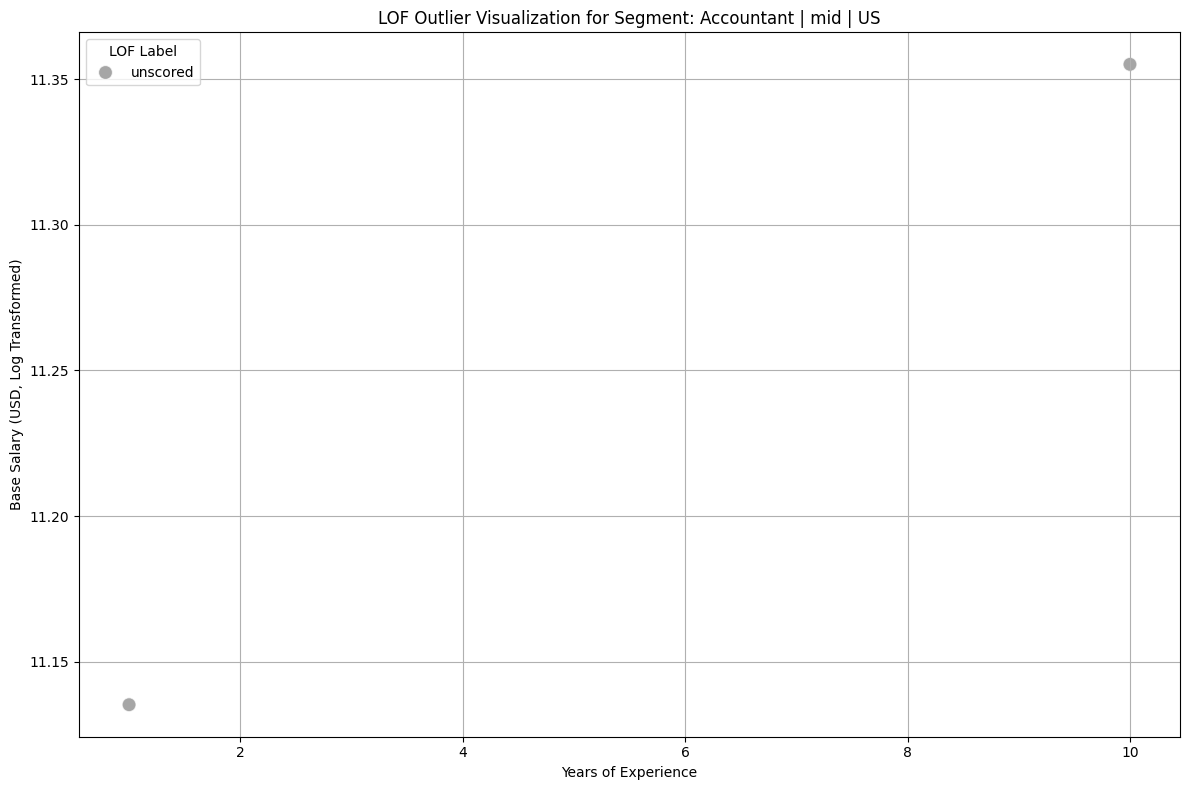

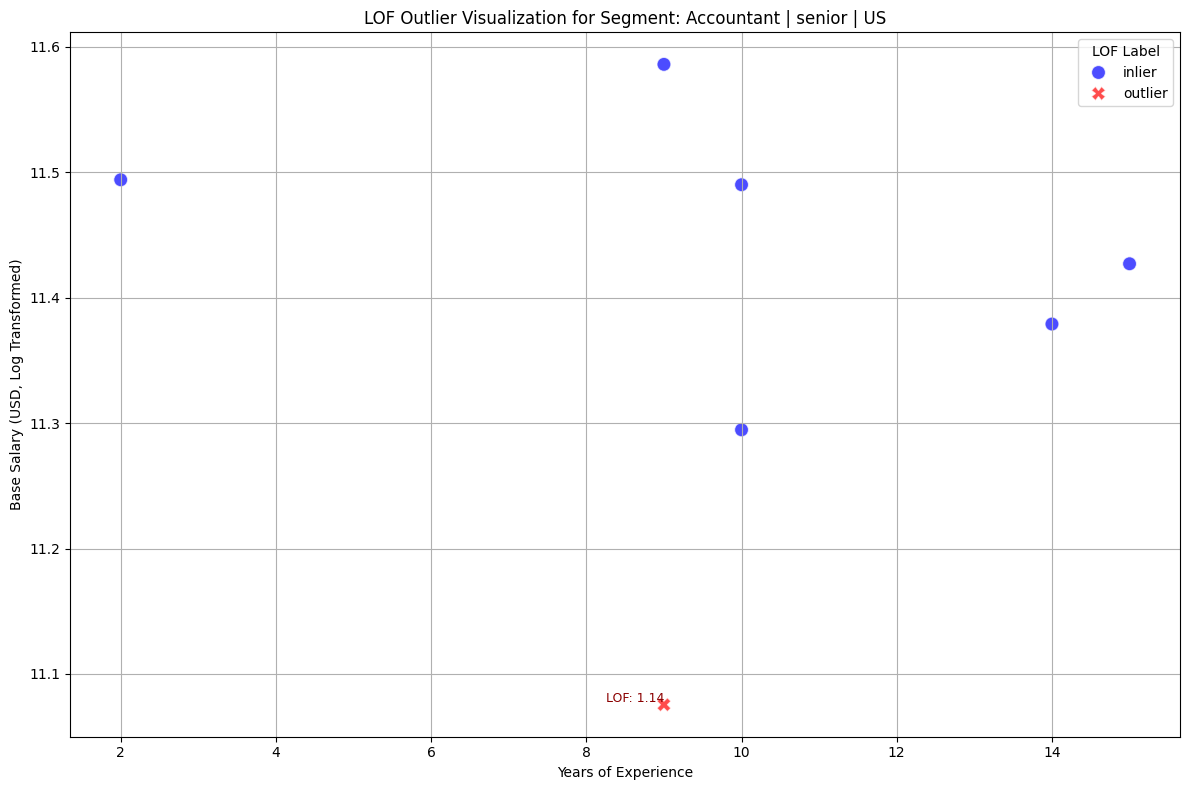


Generating plots for Job Title: Actuary


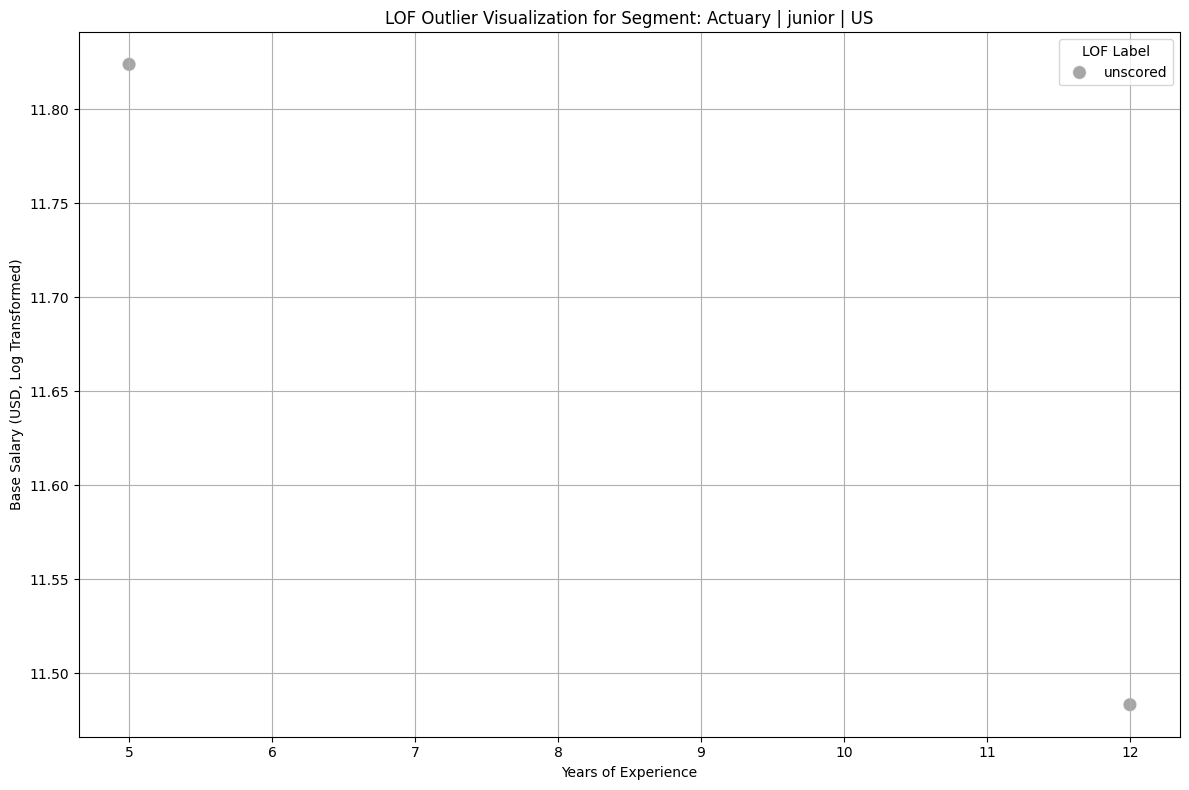

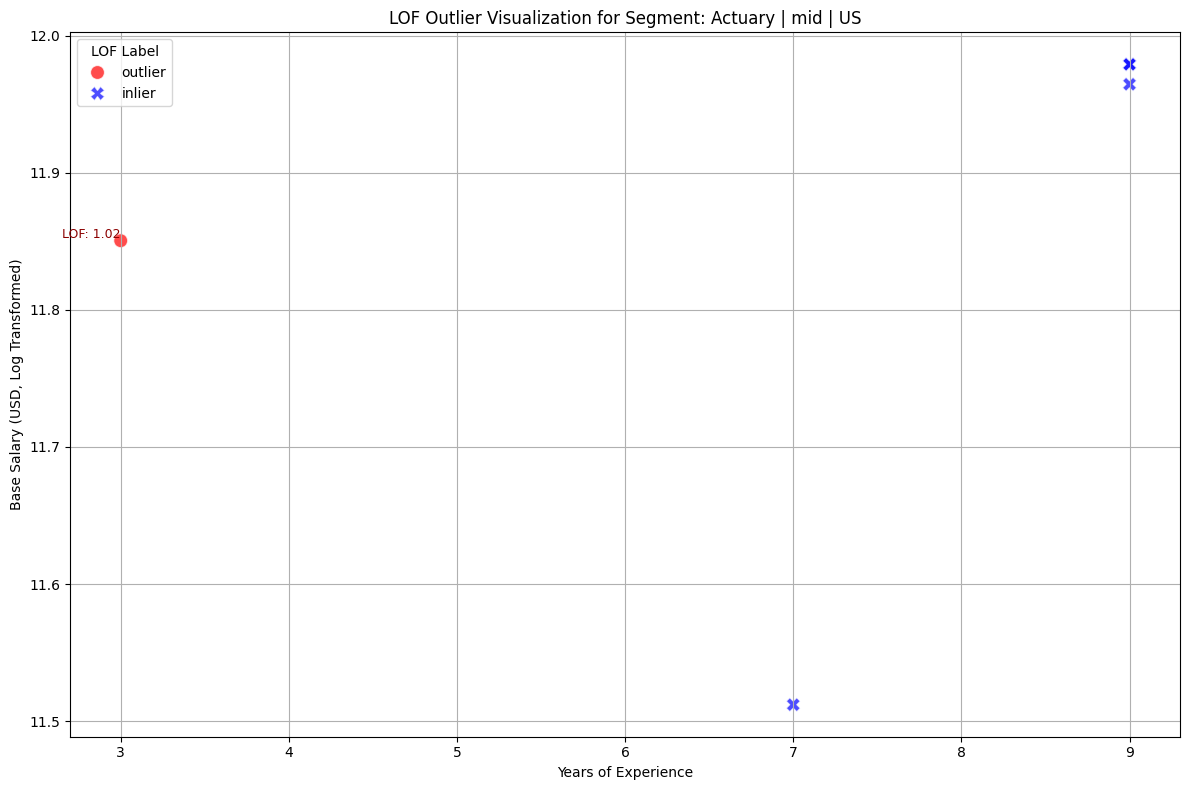

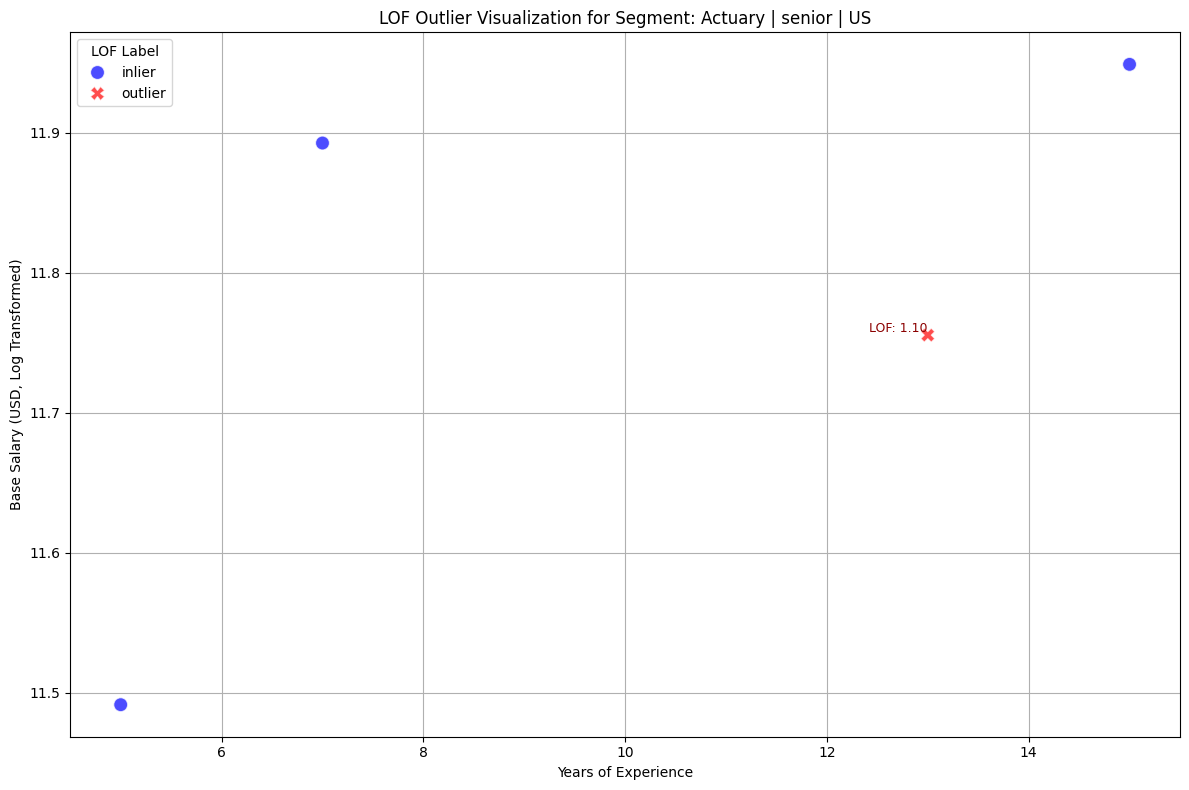


Generating plots for Job Title: Hardware Engineer


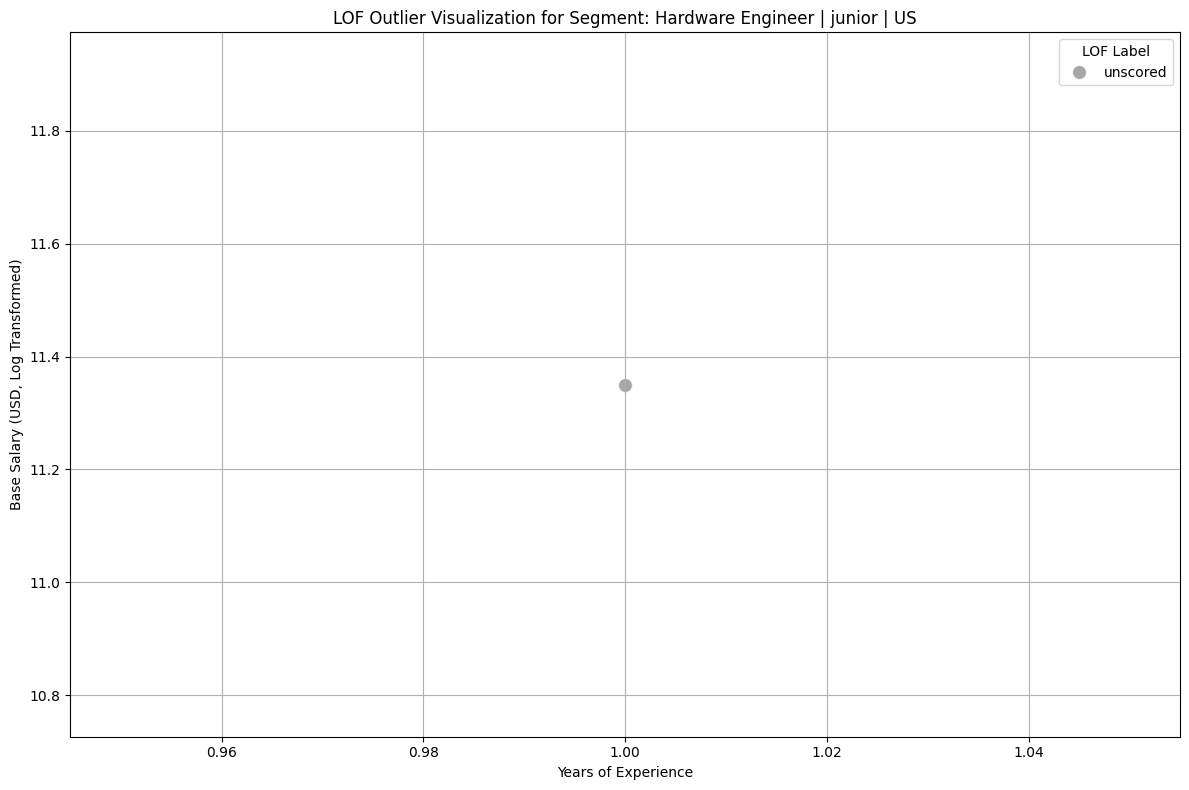

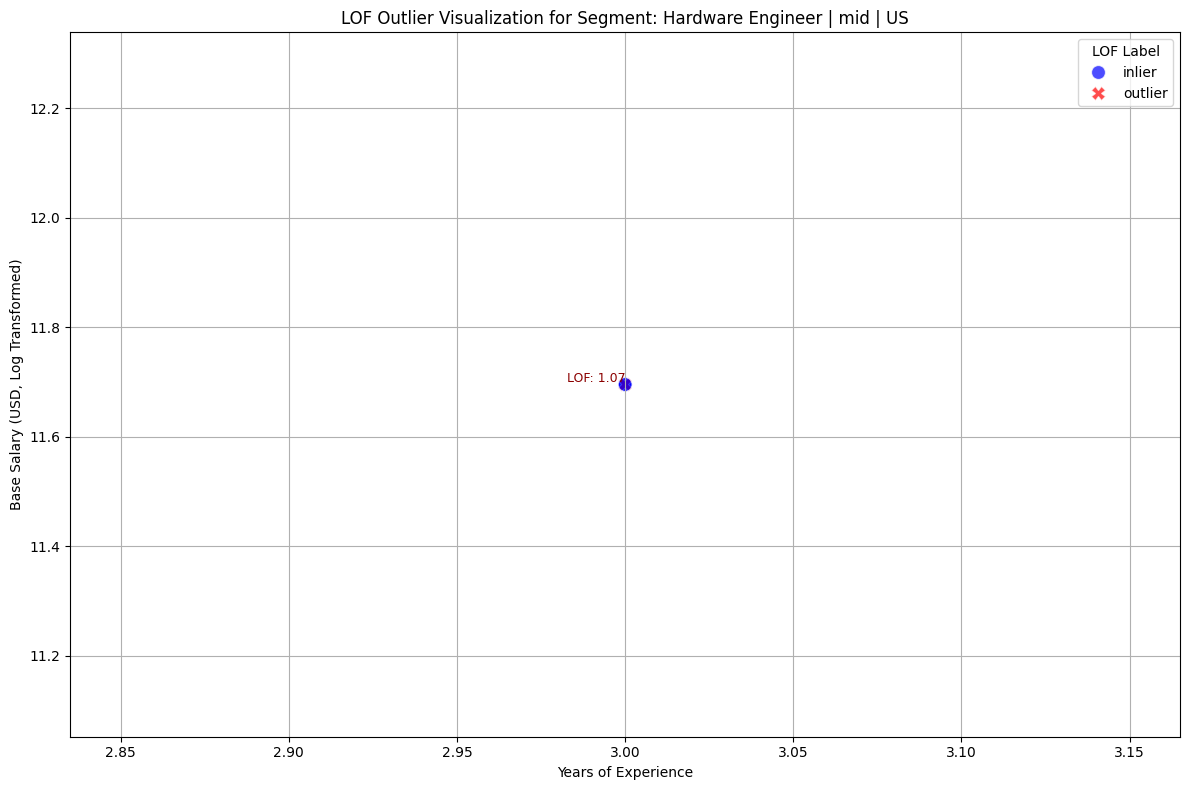

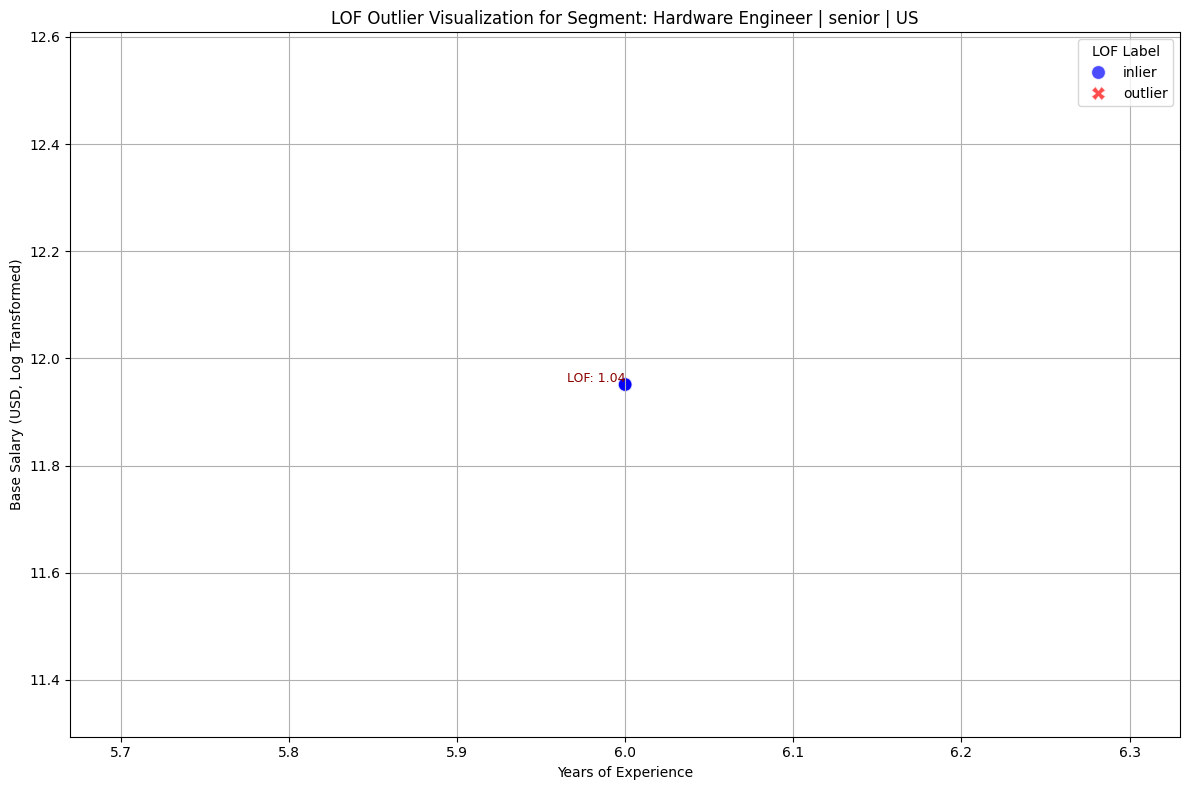

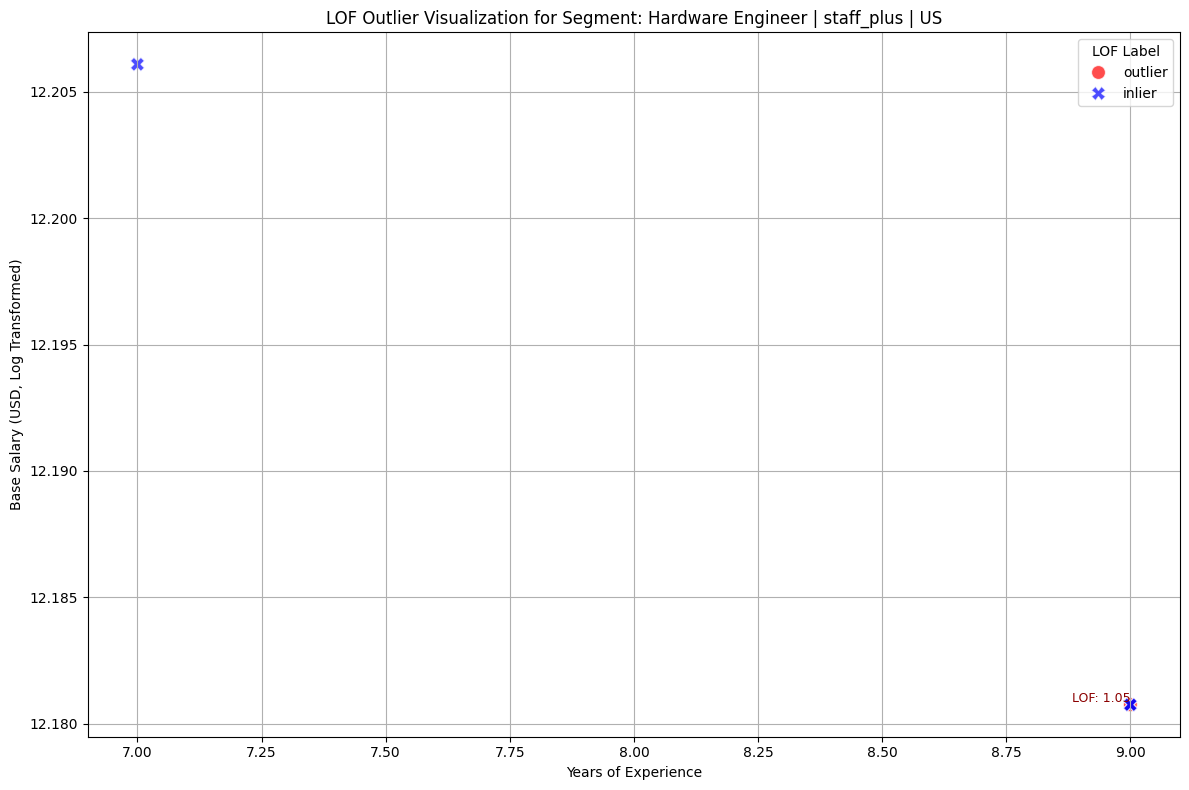


Generating plots for Job Title: Toxicologist


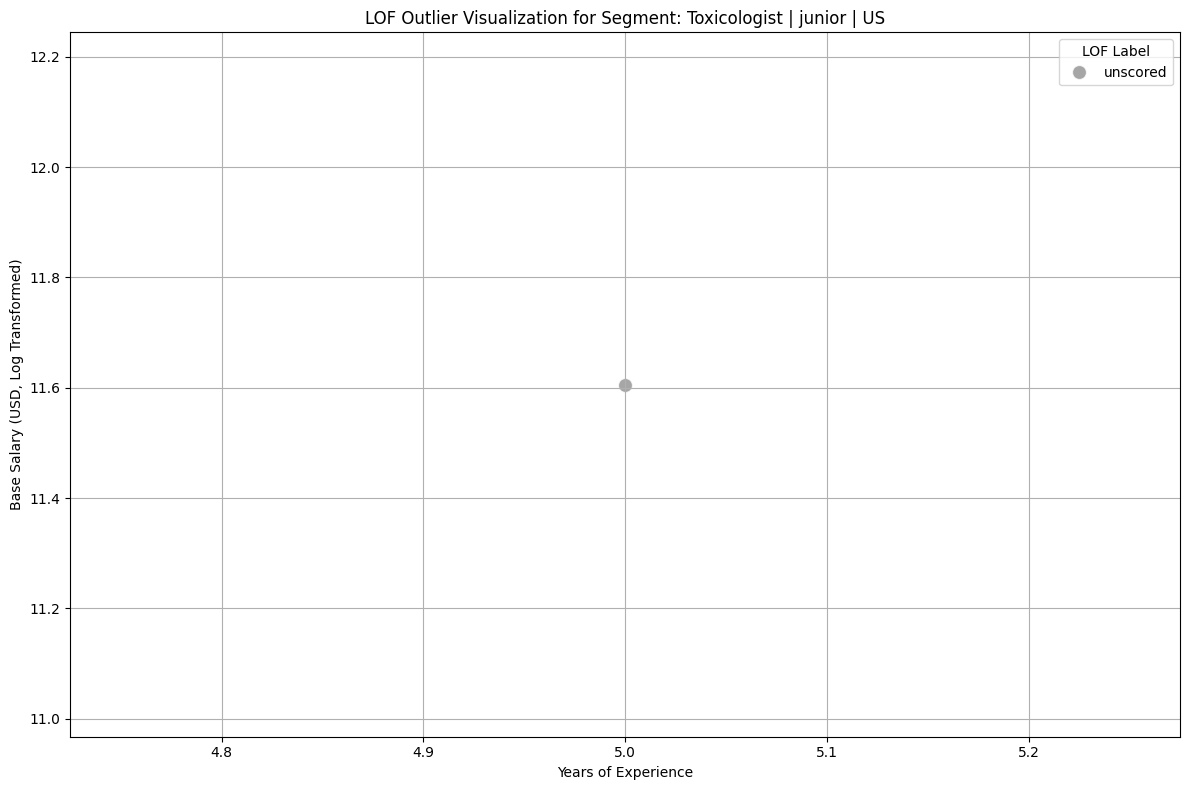

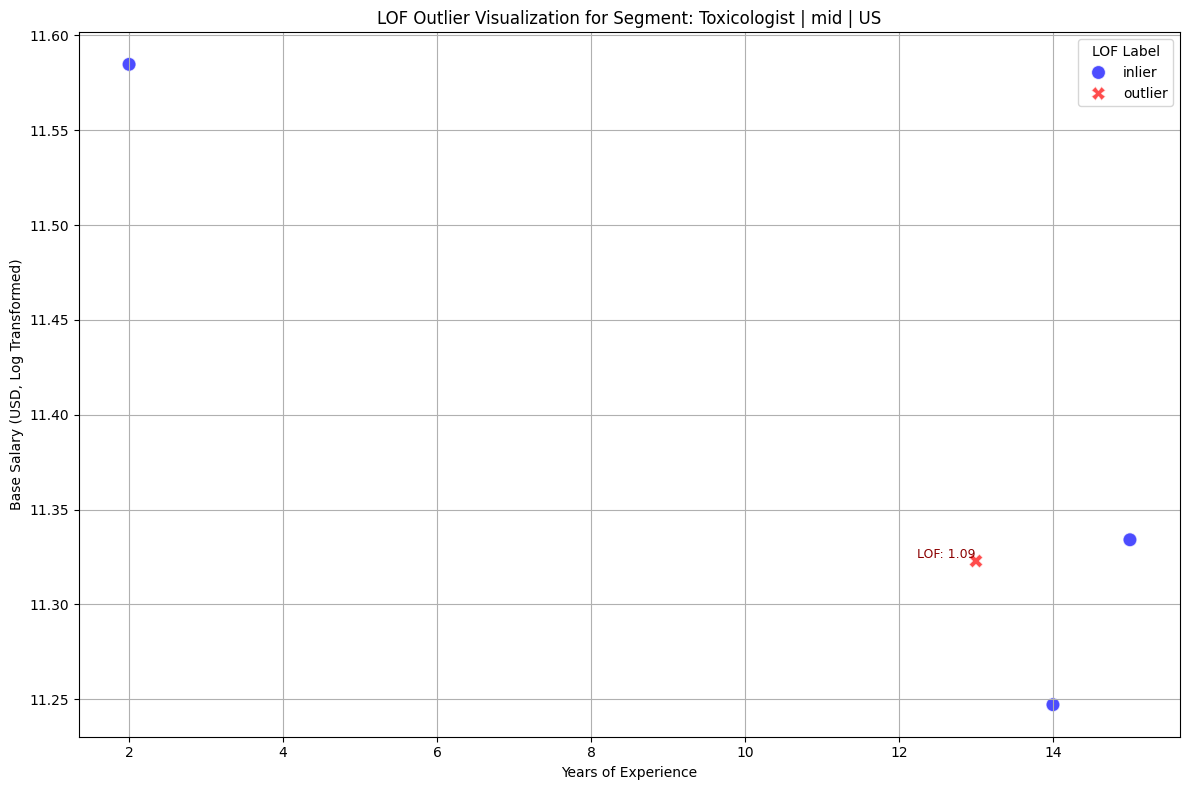

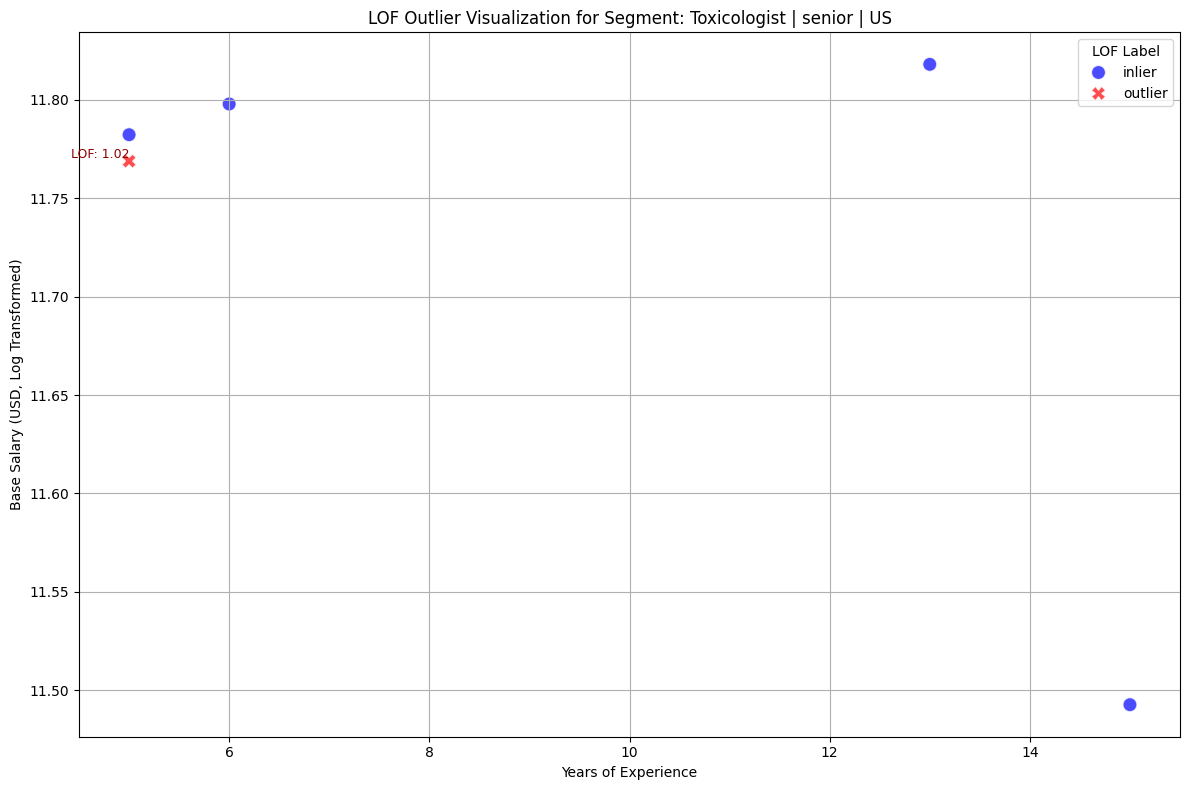


Generating plots for Job Title: Software Engineer


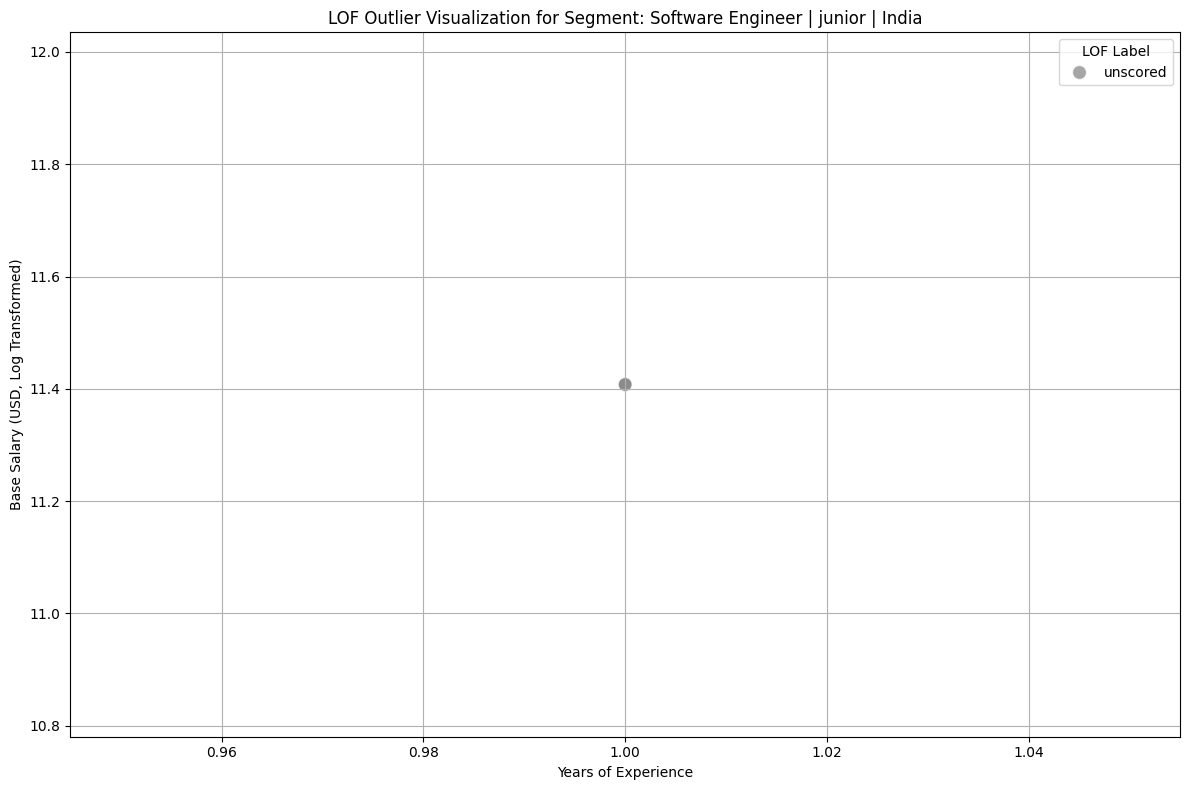

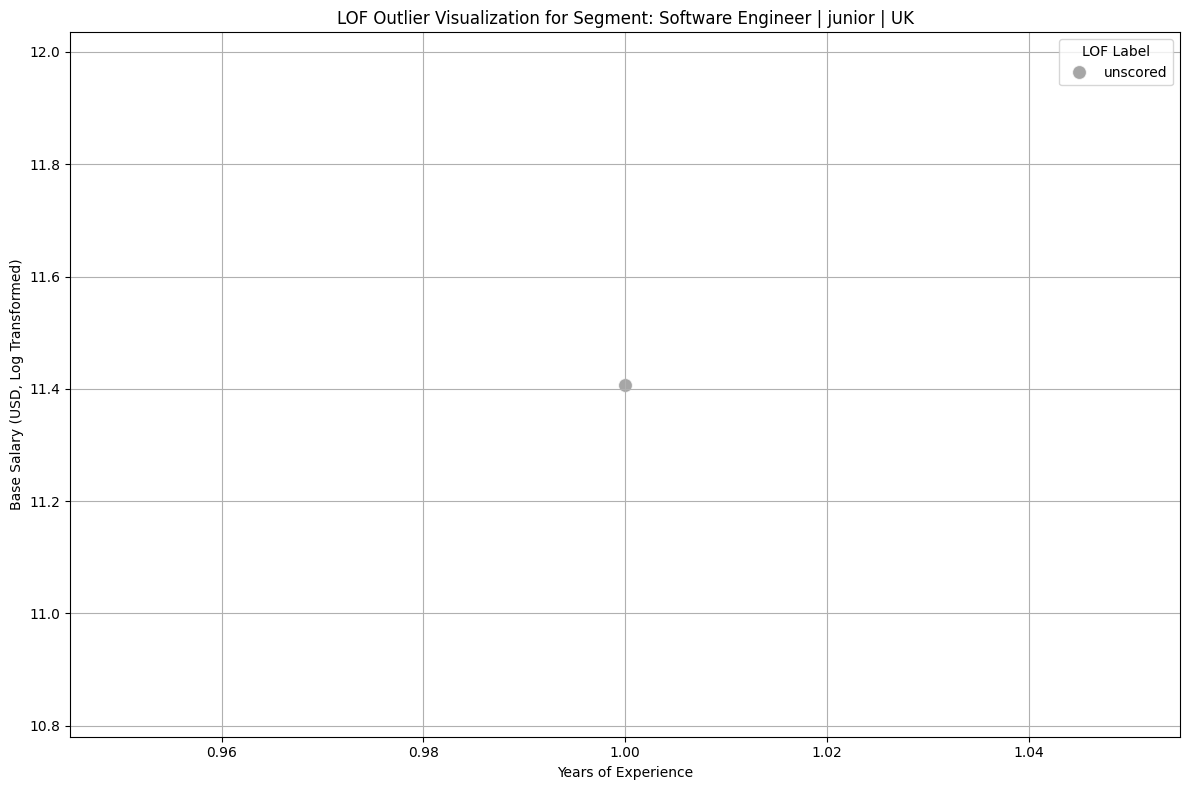

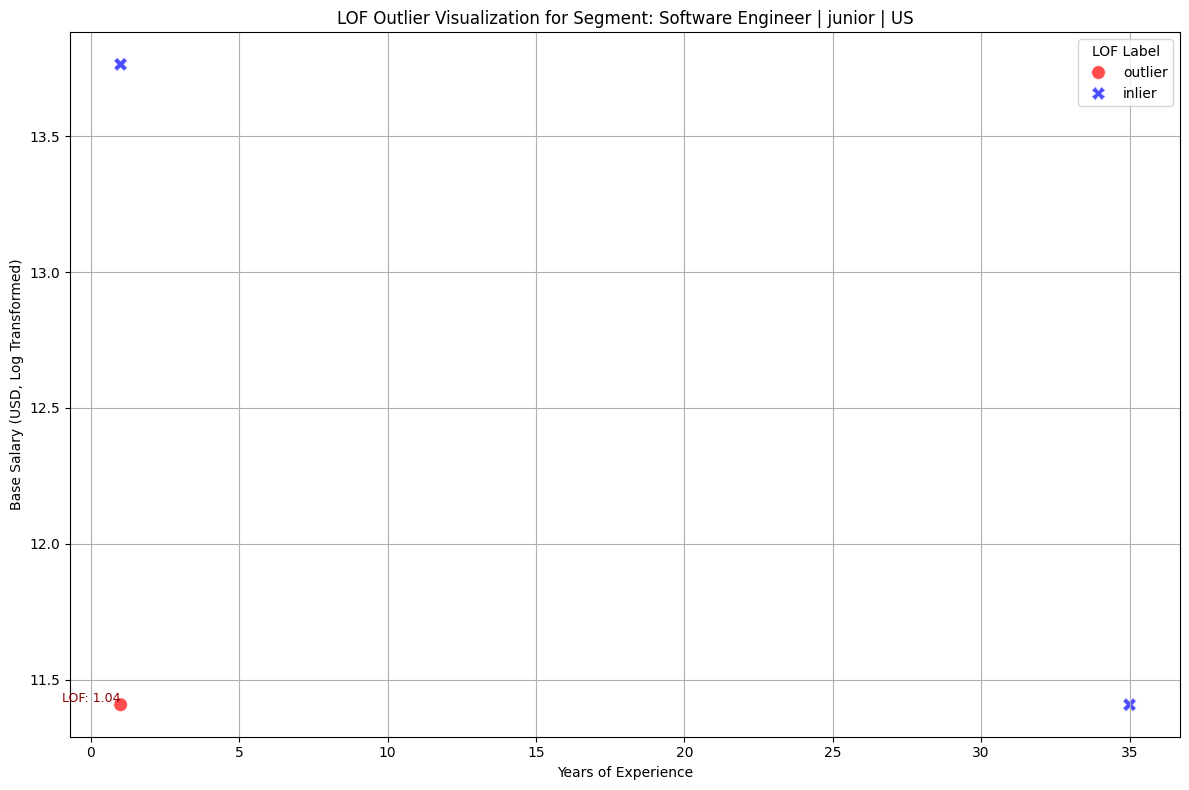

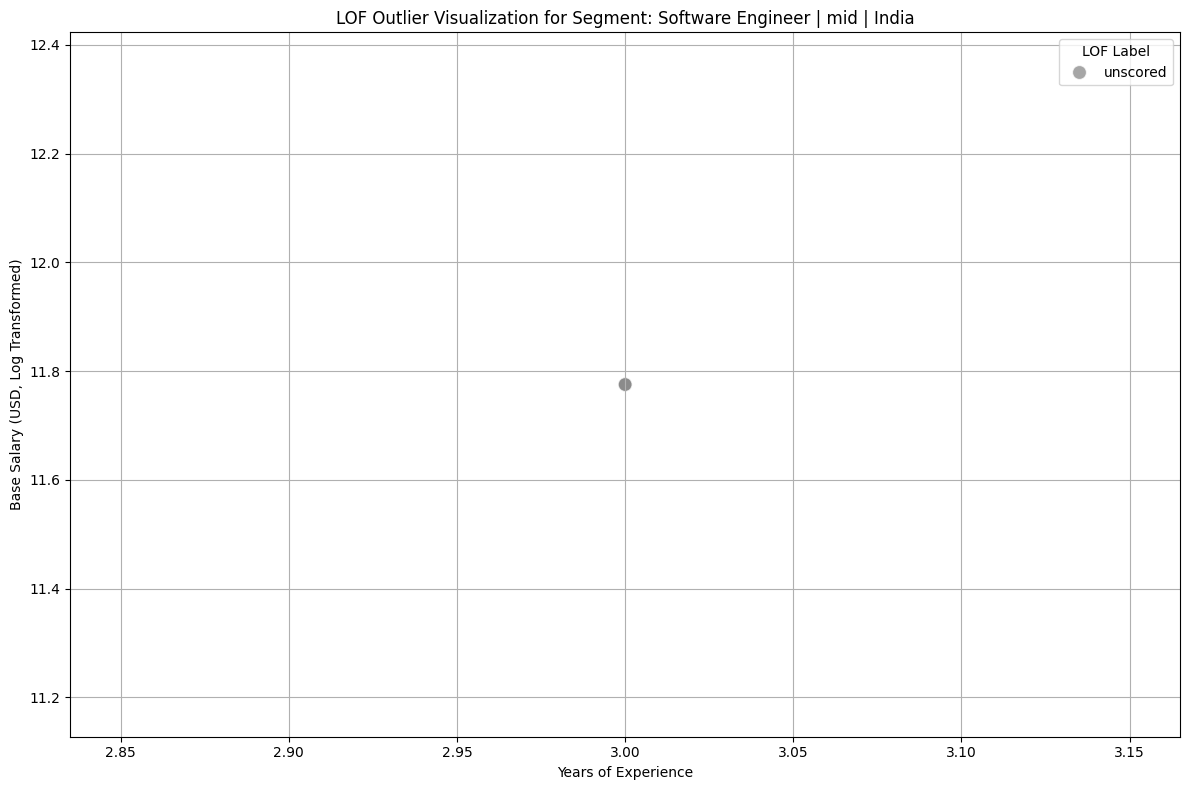

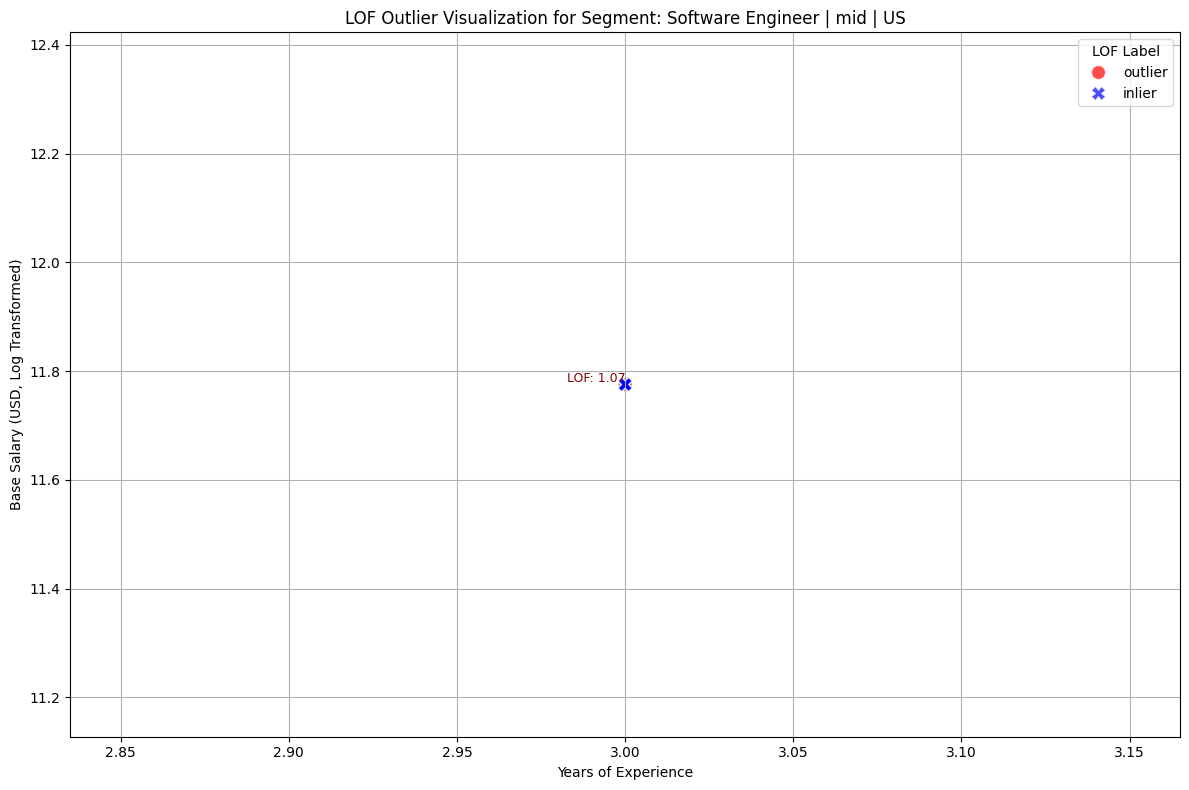

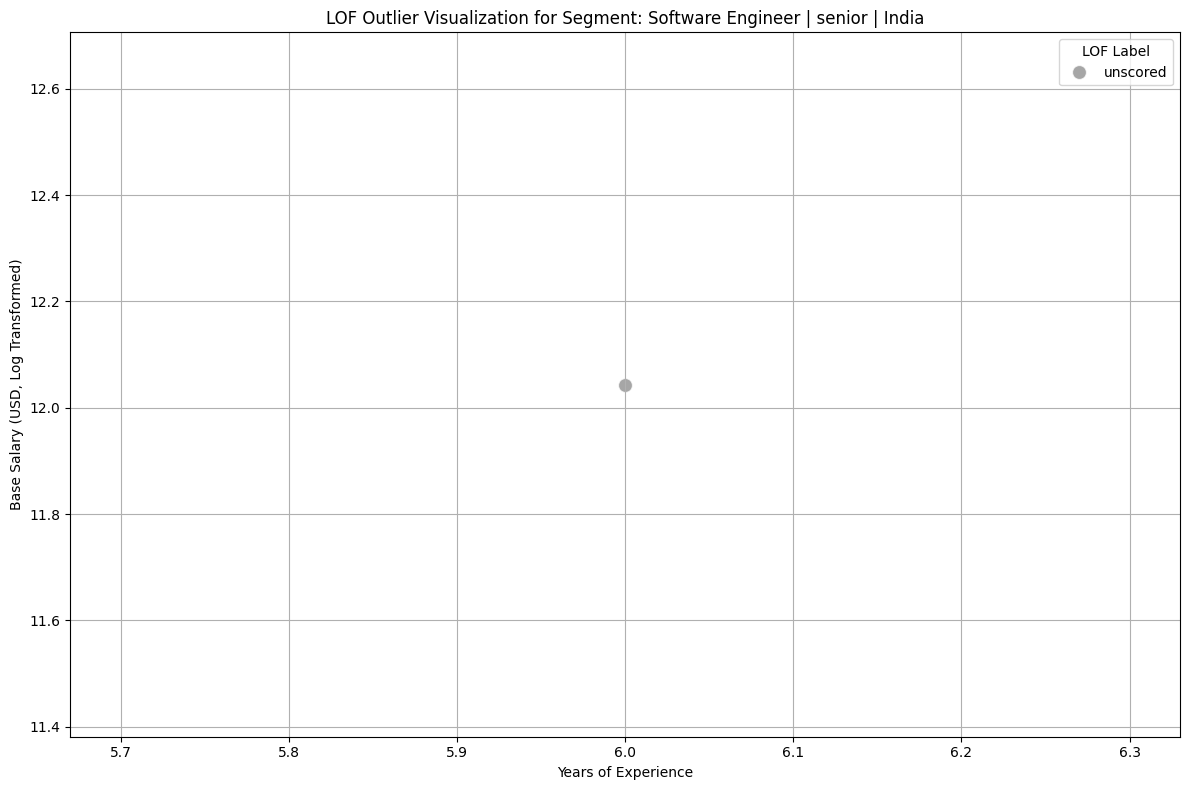

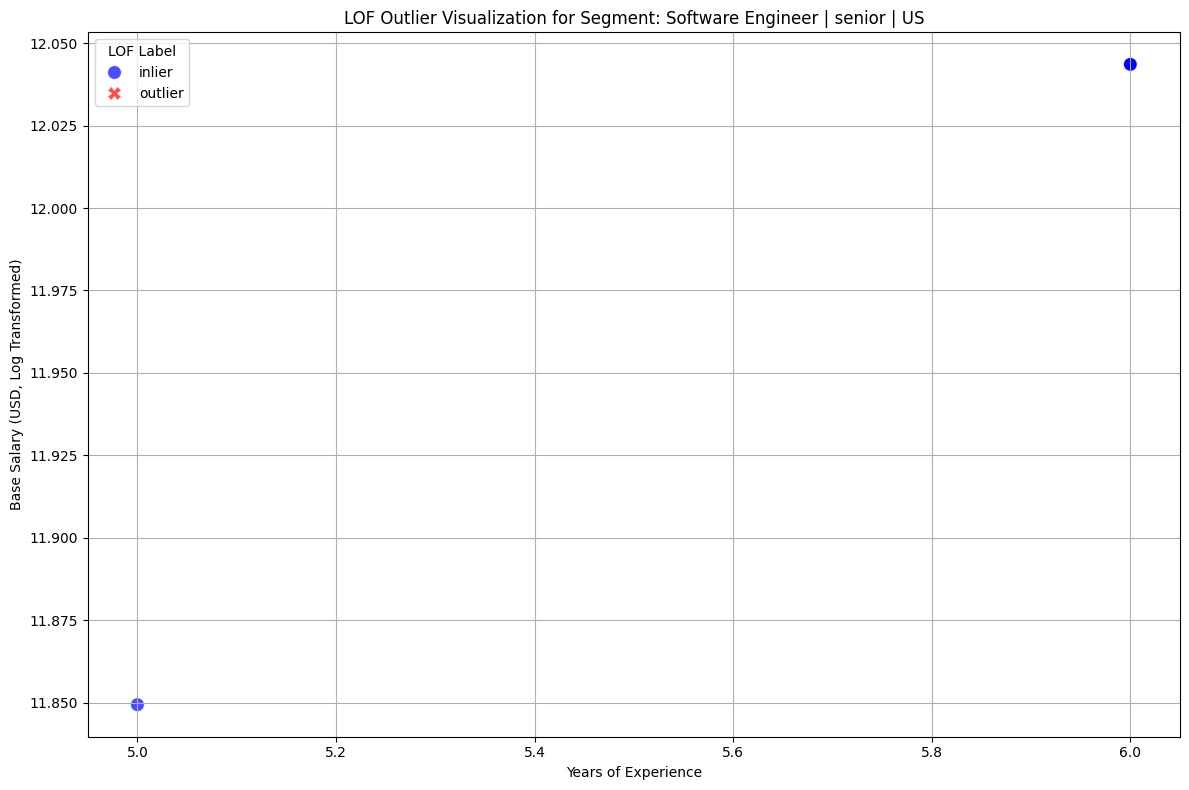

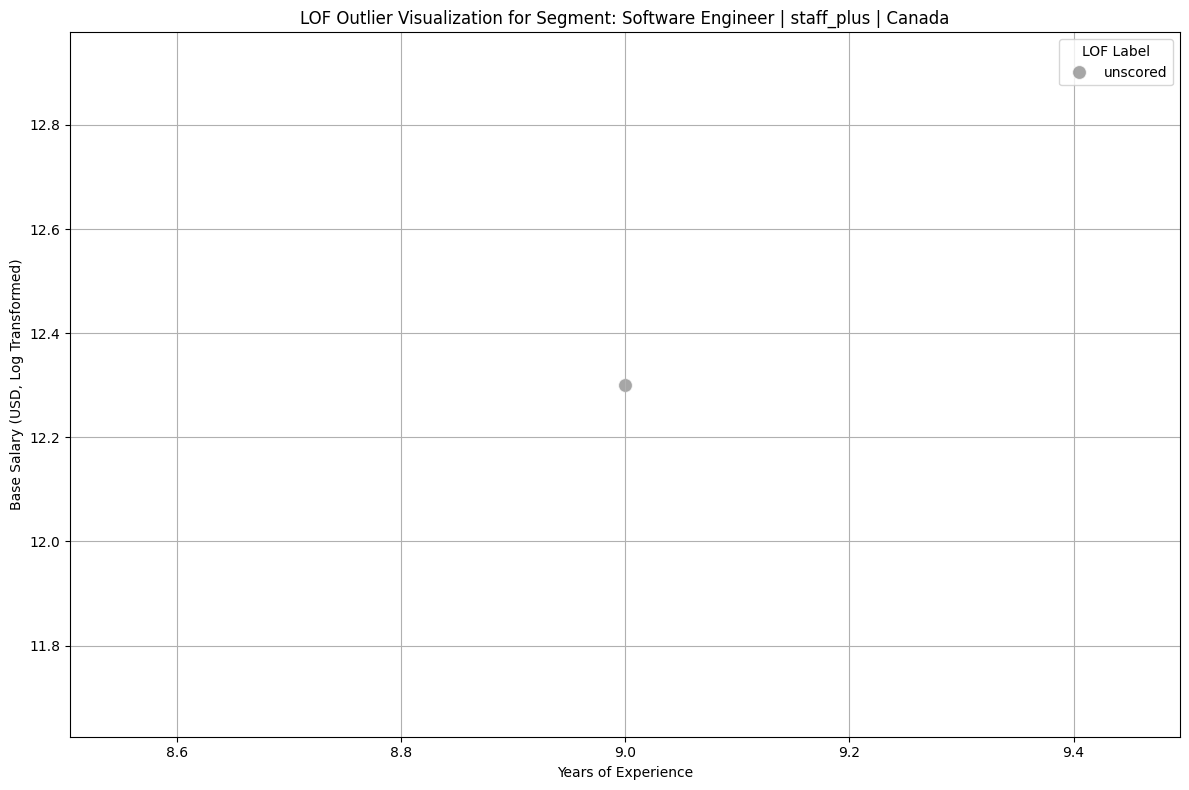

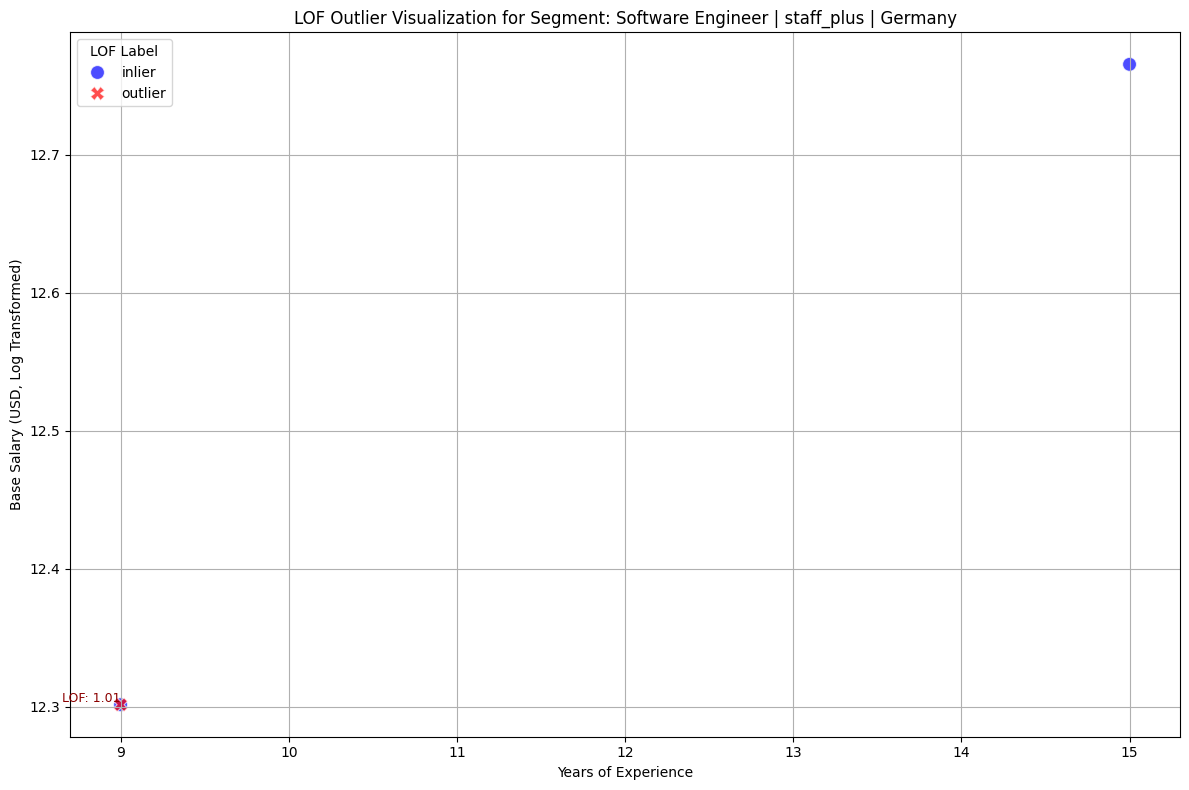

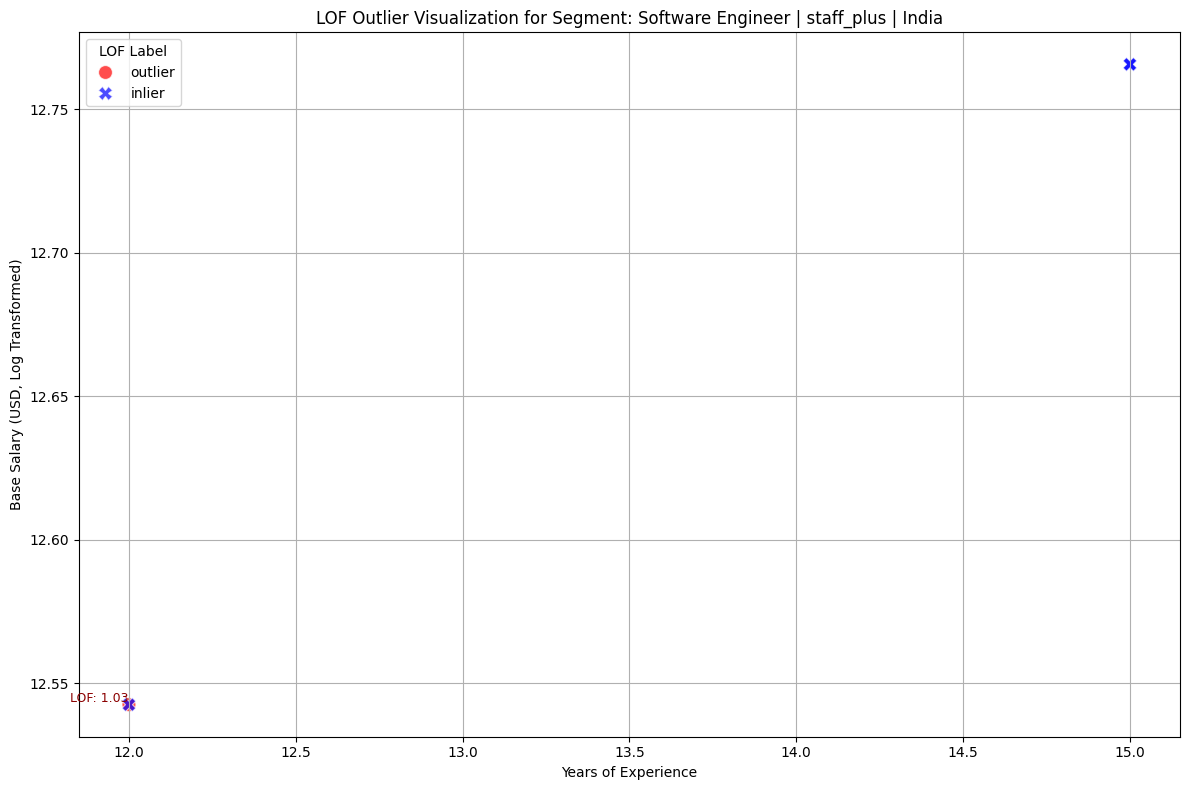

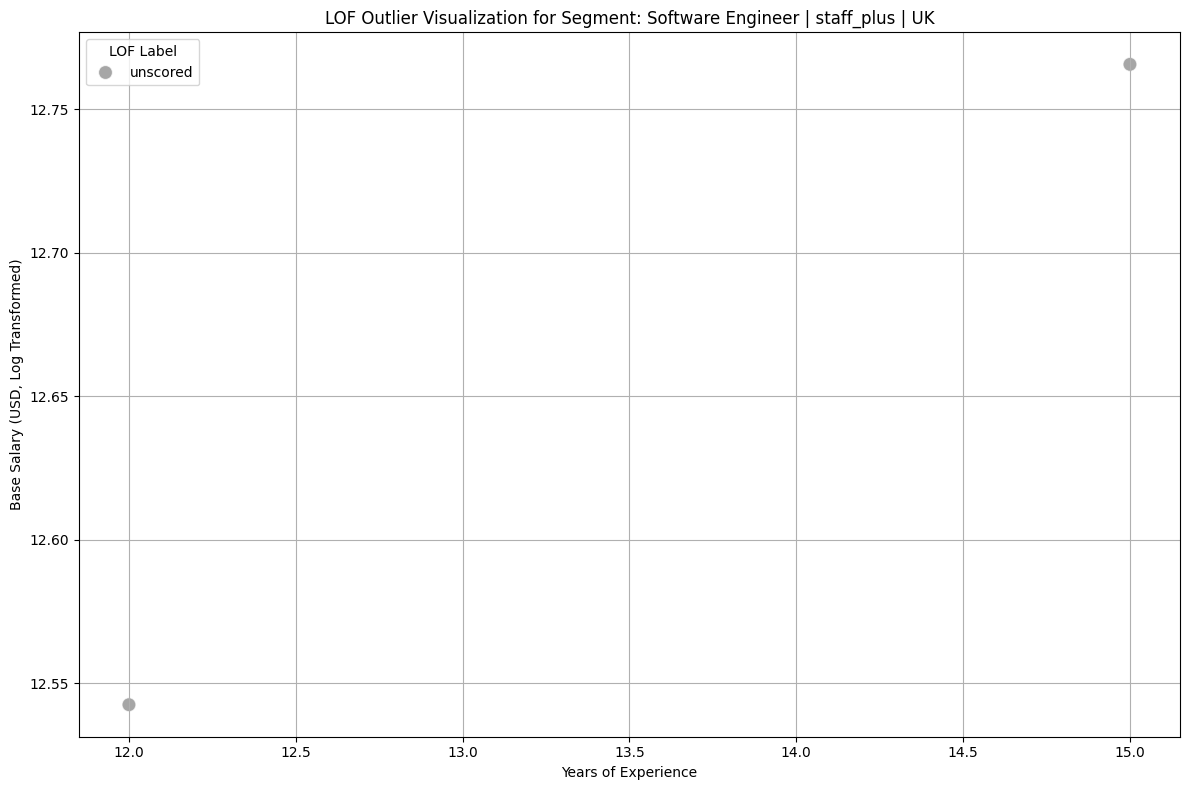

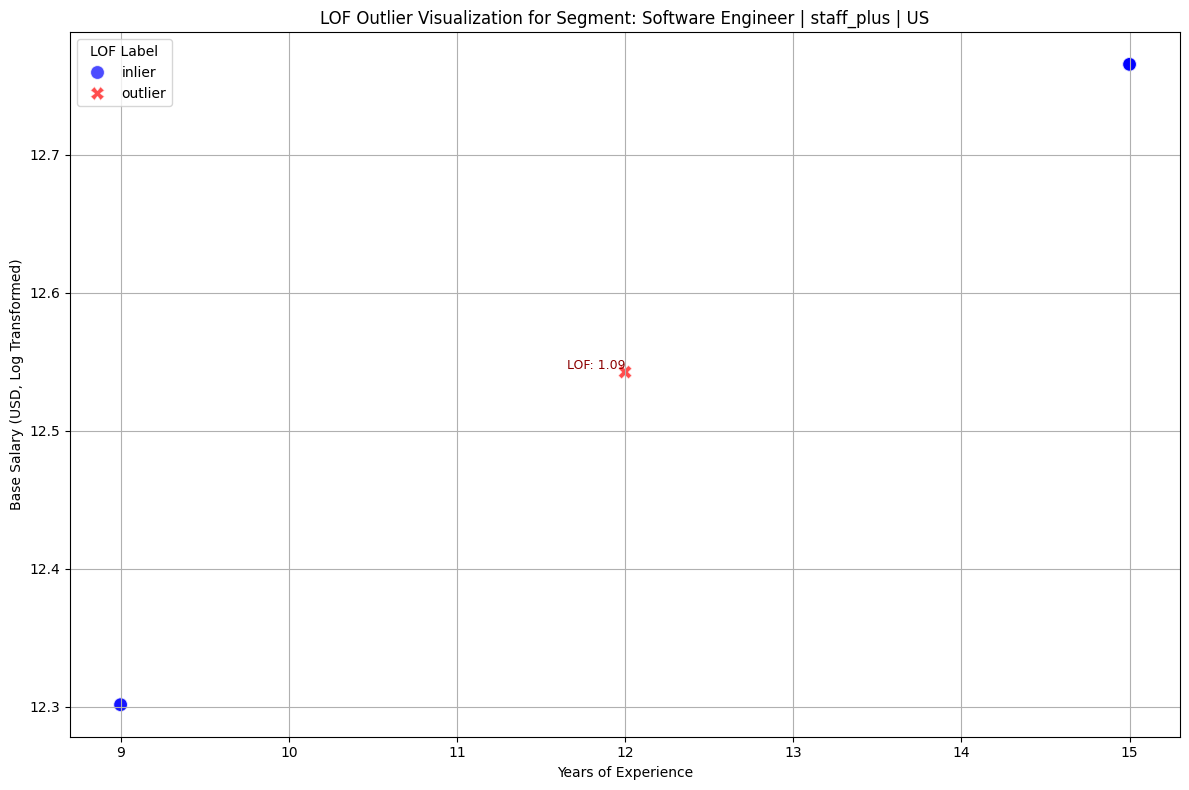


Generating plots for Job Title: Product Designer


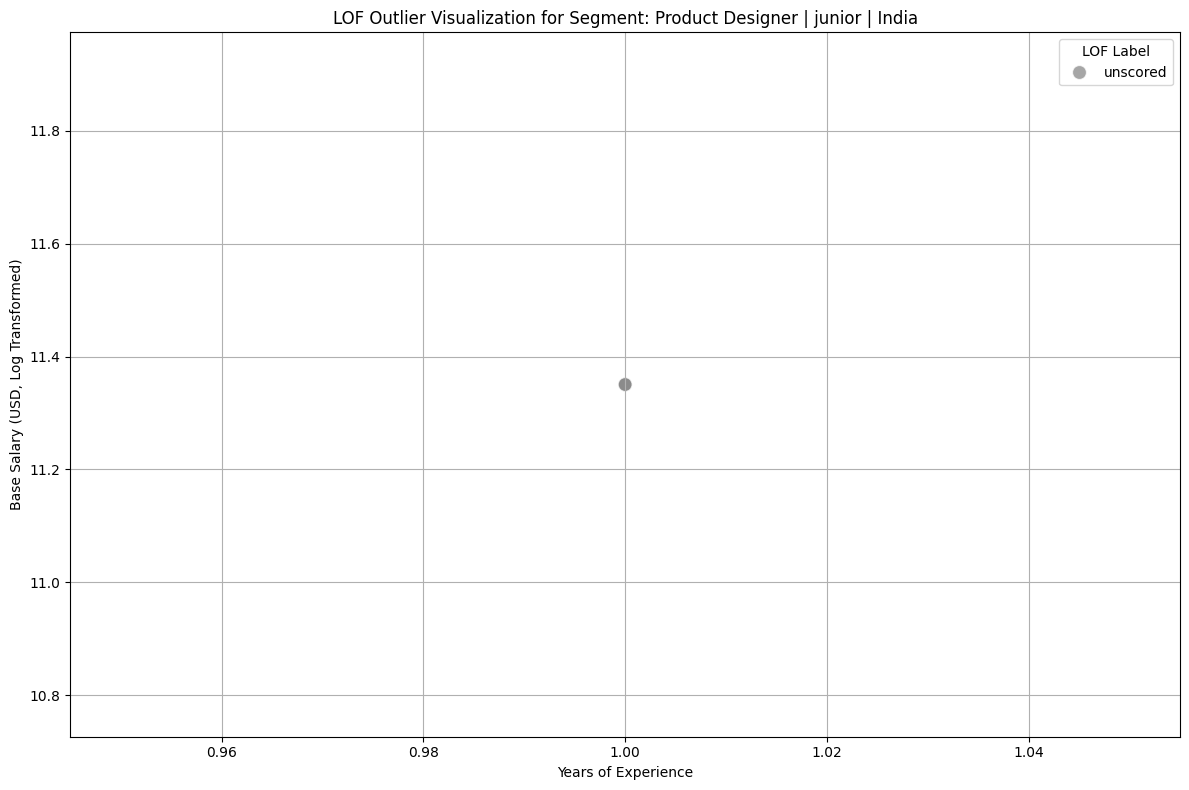

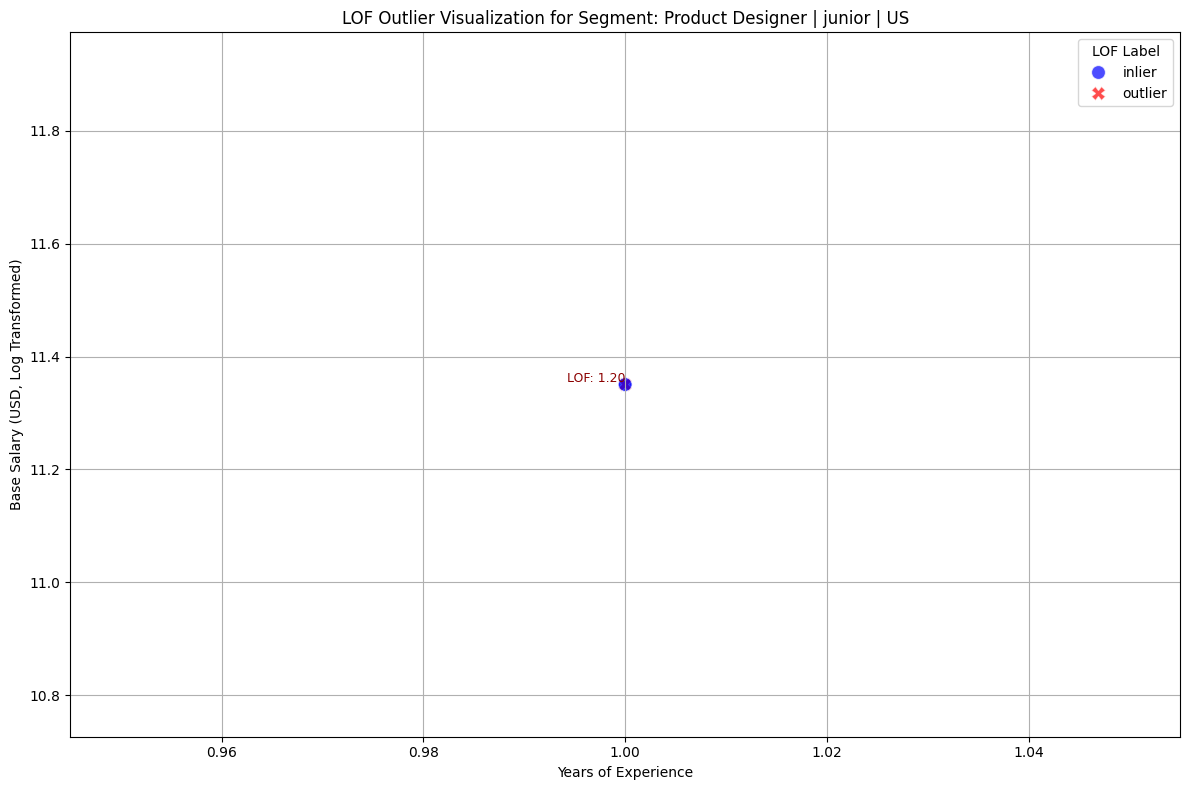

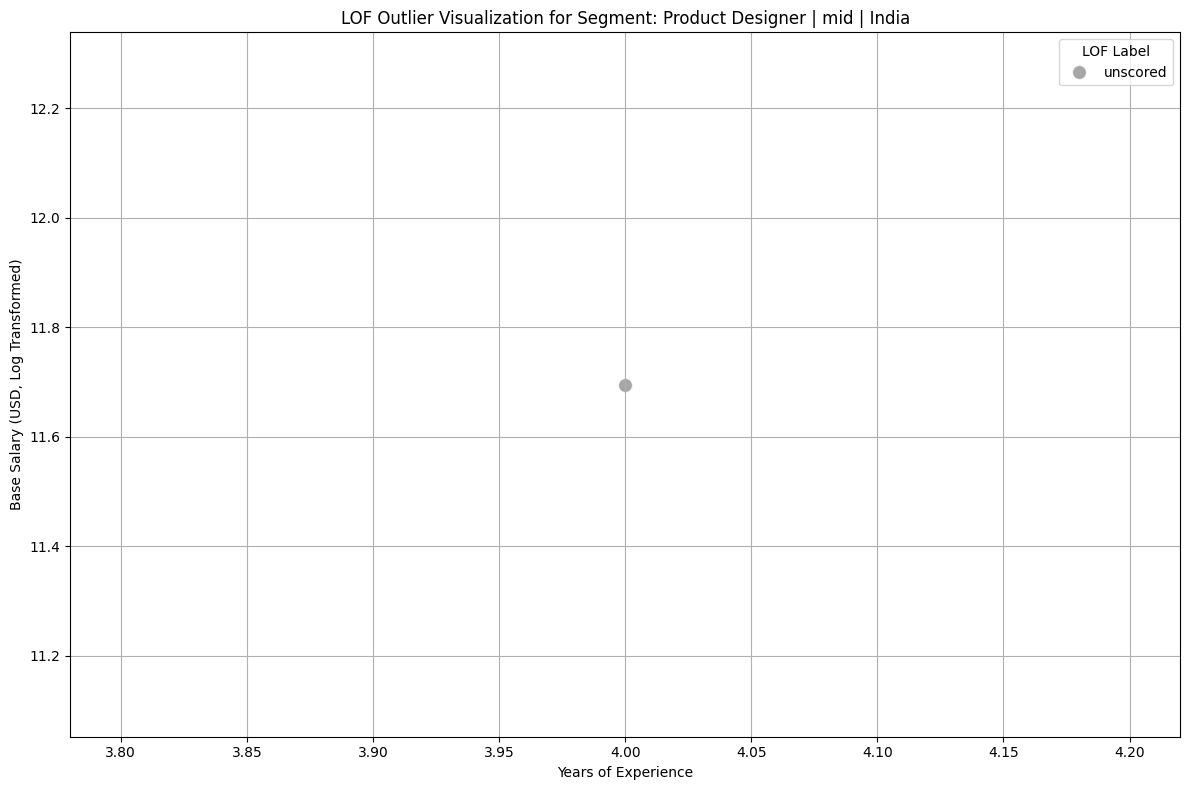

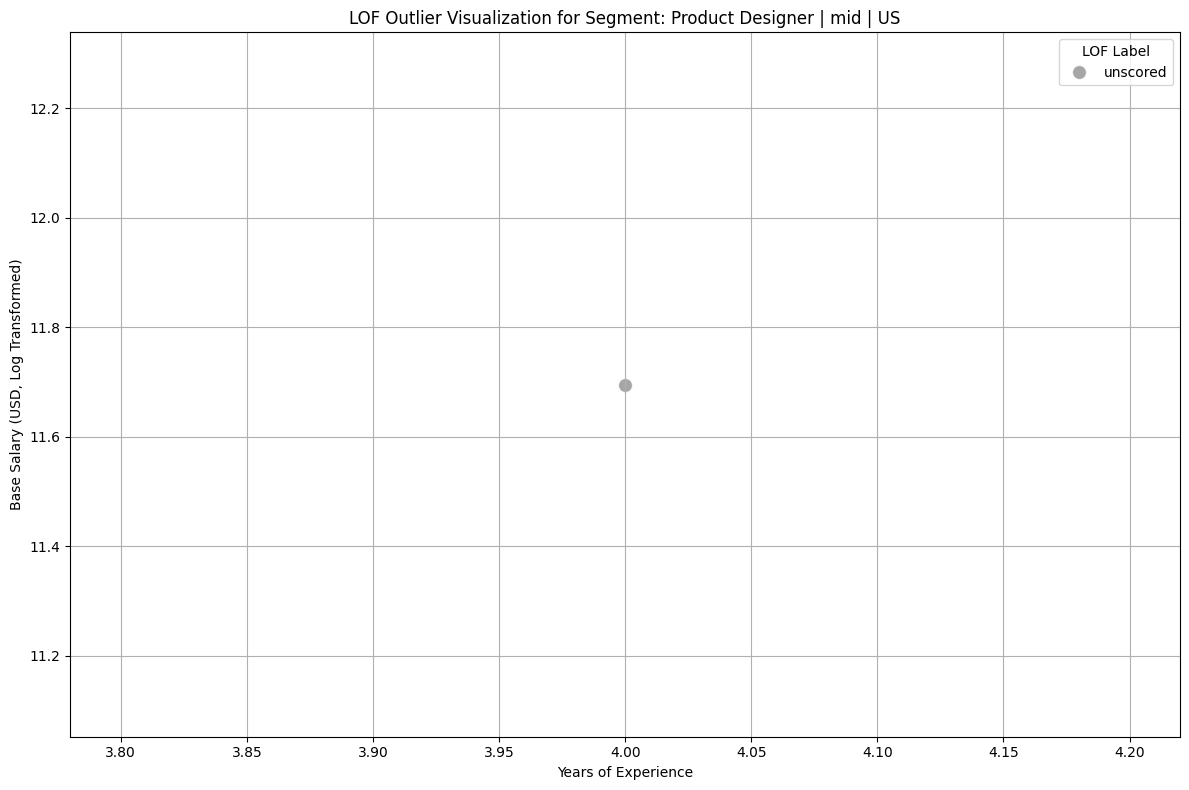

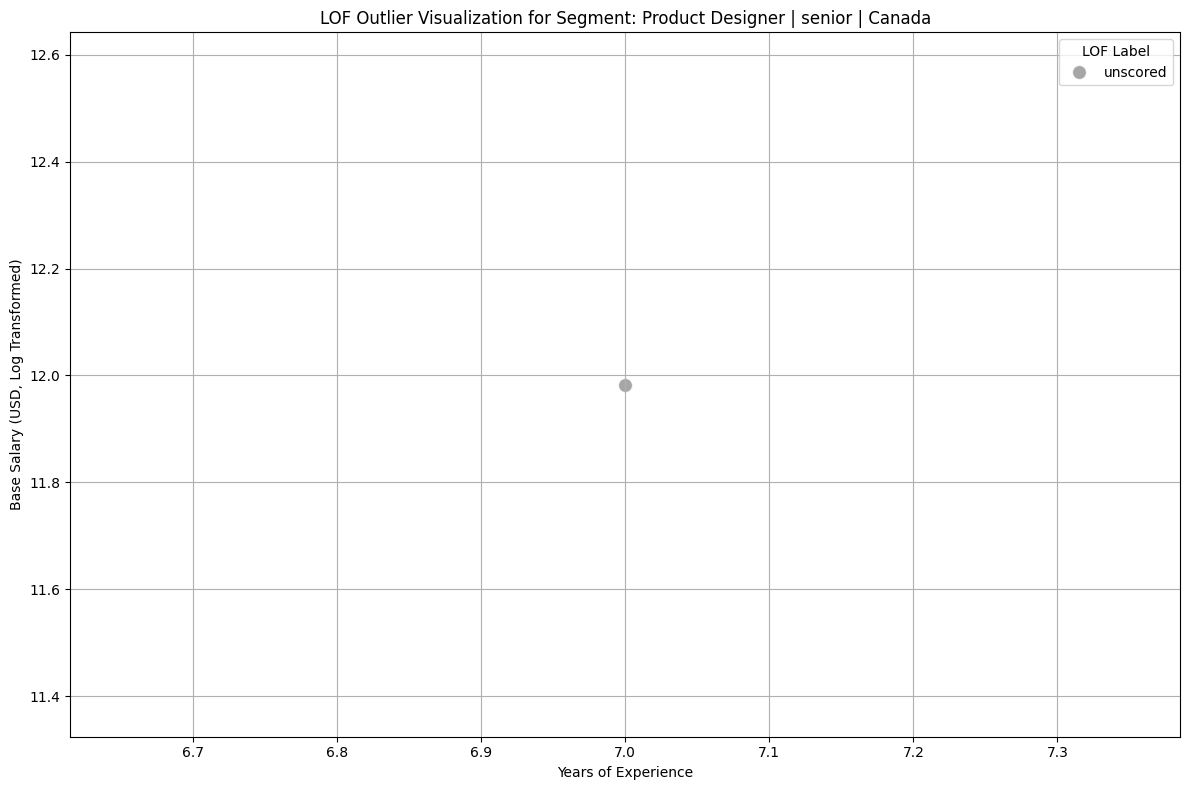

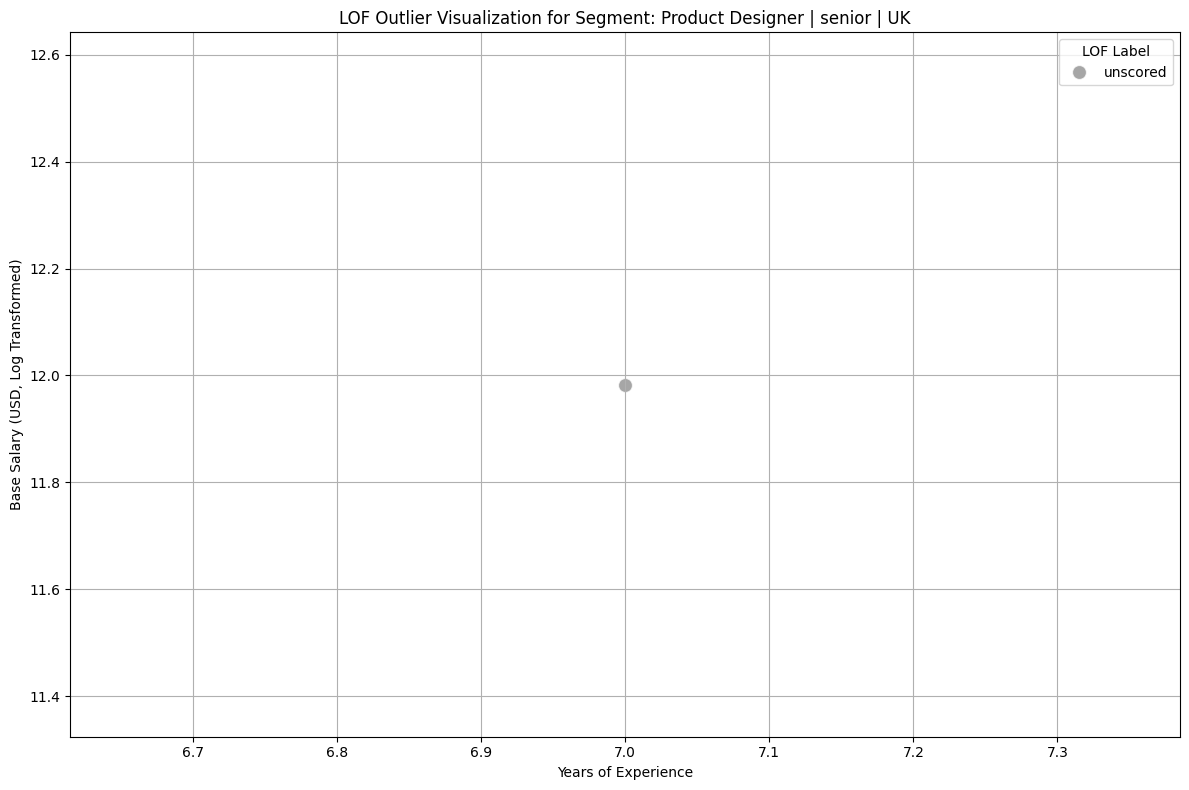

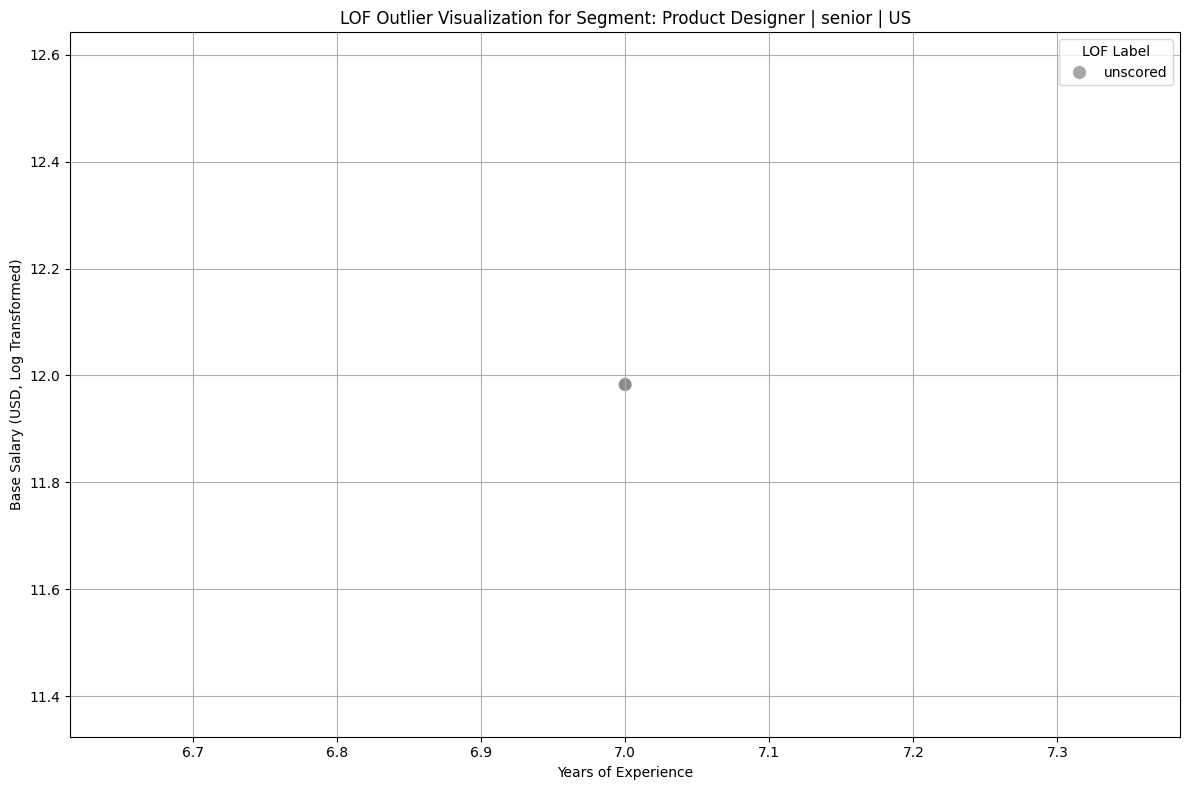


Generating plots for Job Title: Mechanical Engineer


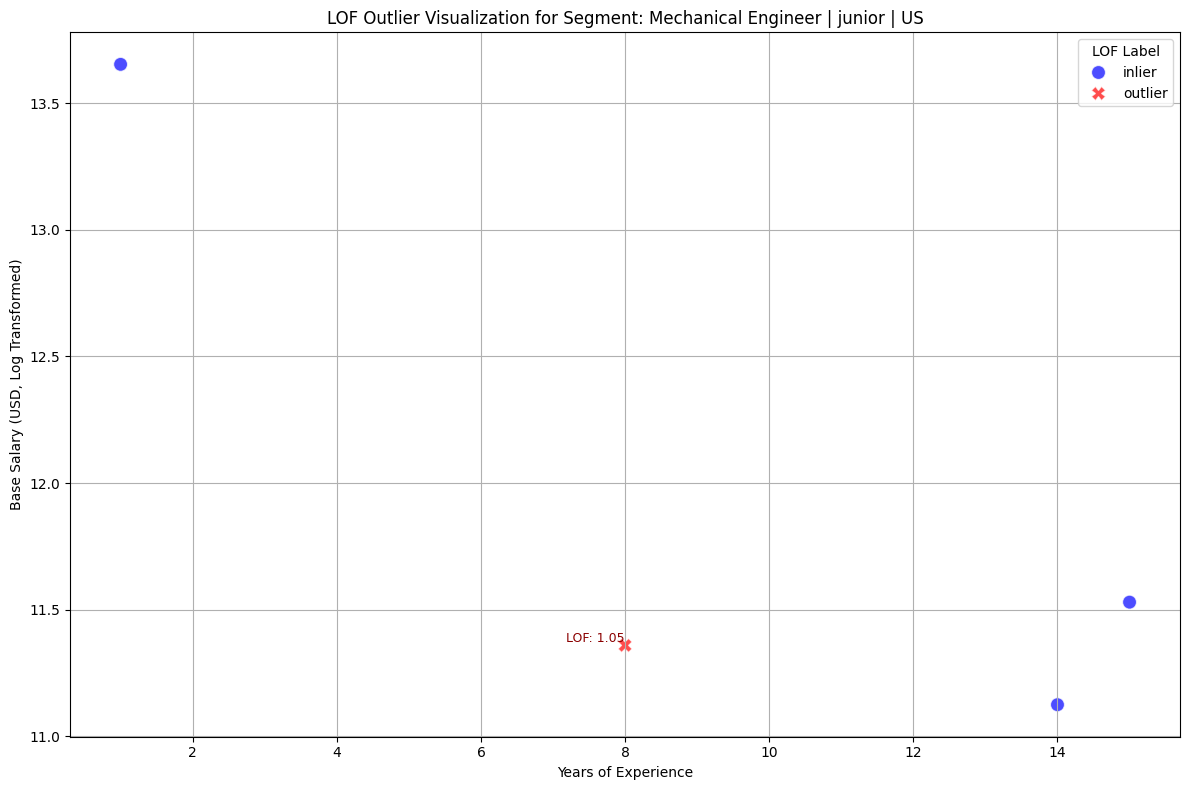

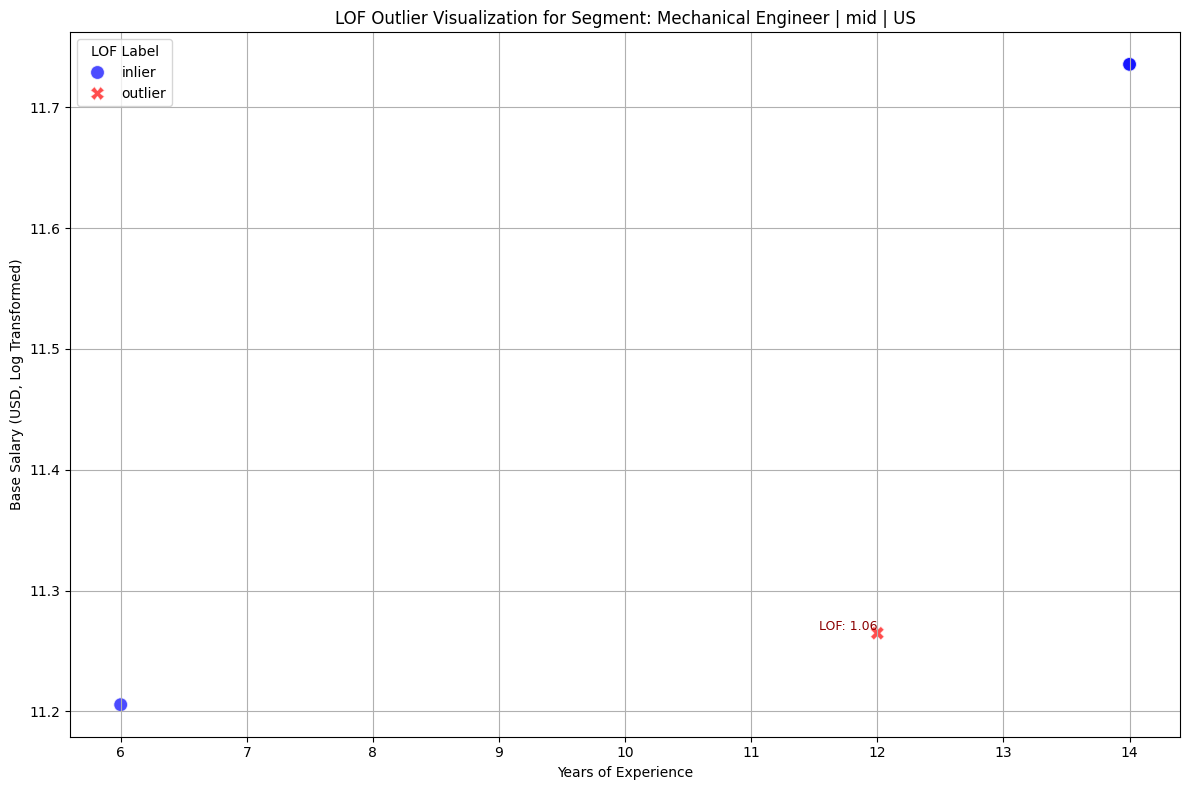

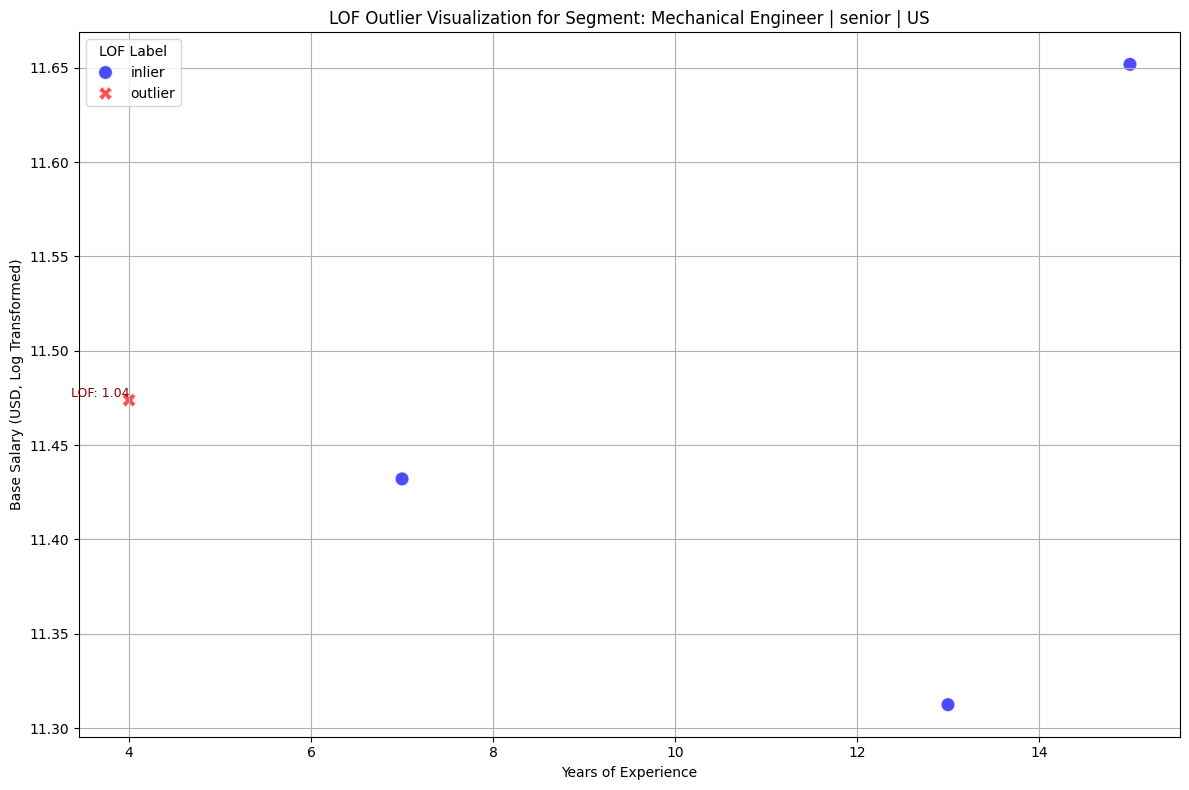

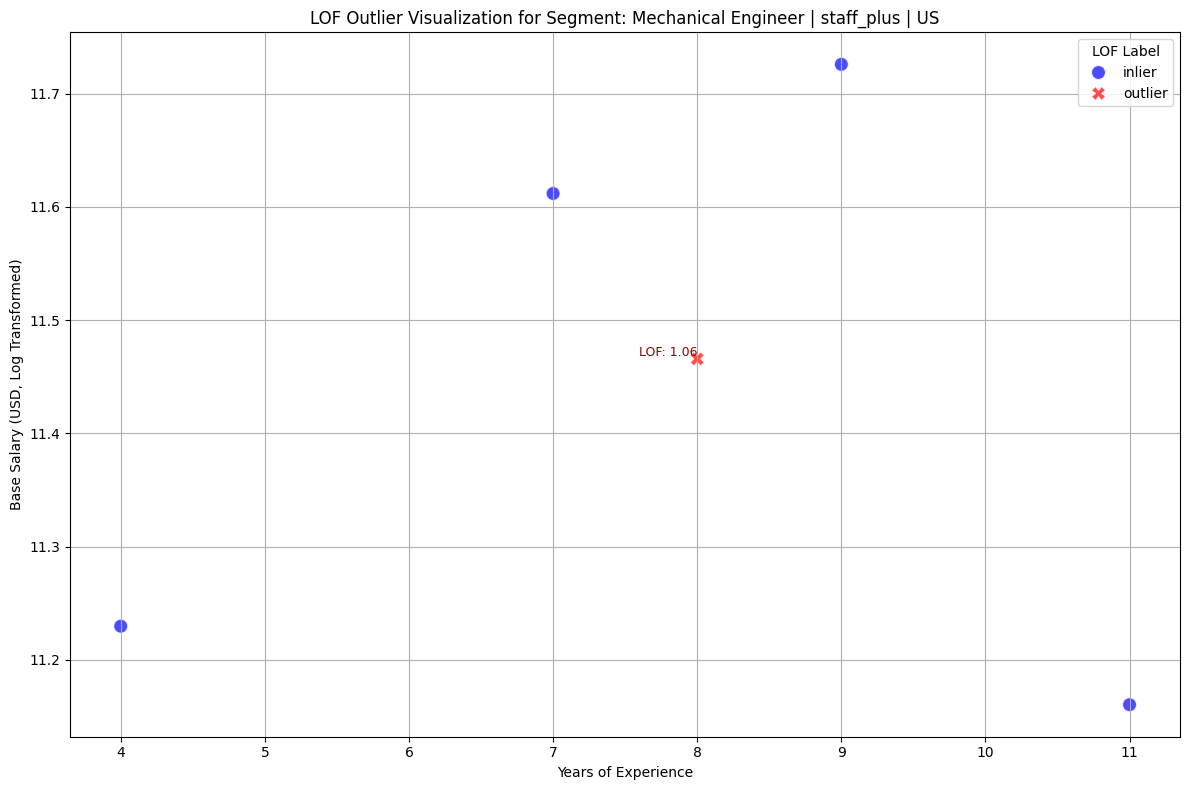


Generating plots for Job Title: Investment Banker


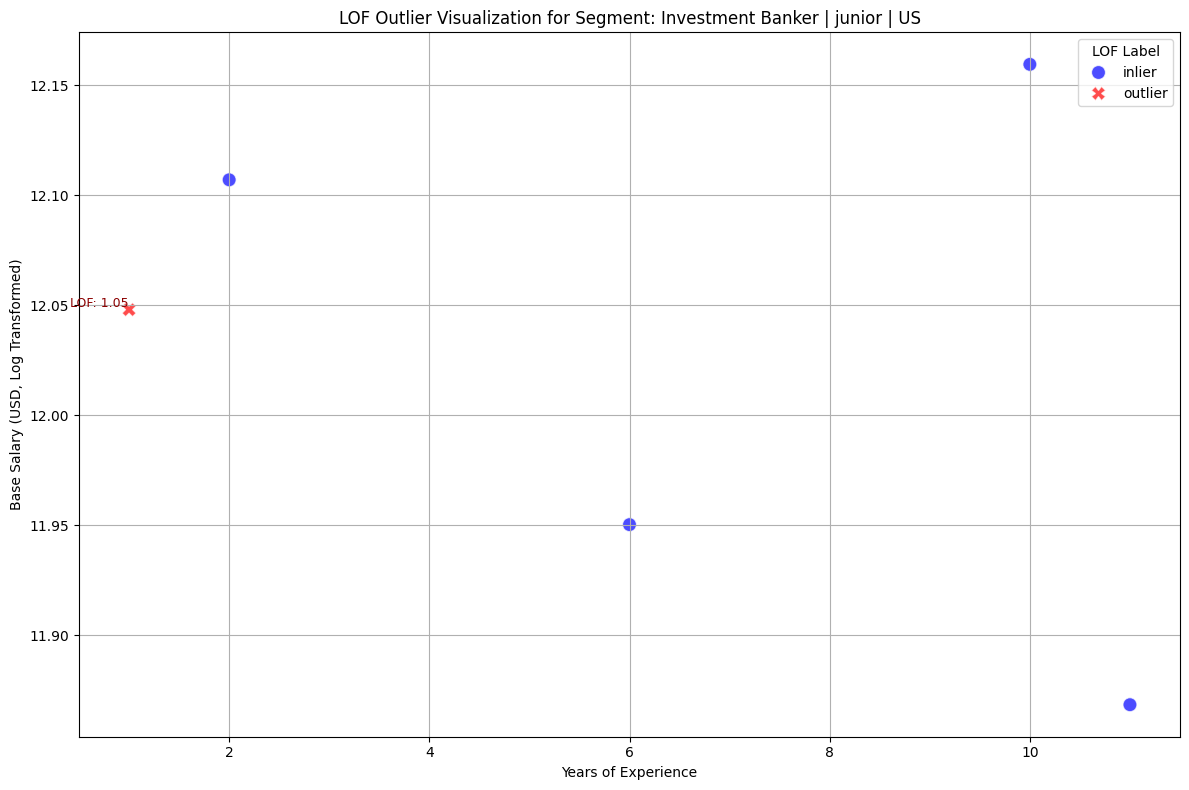

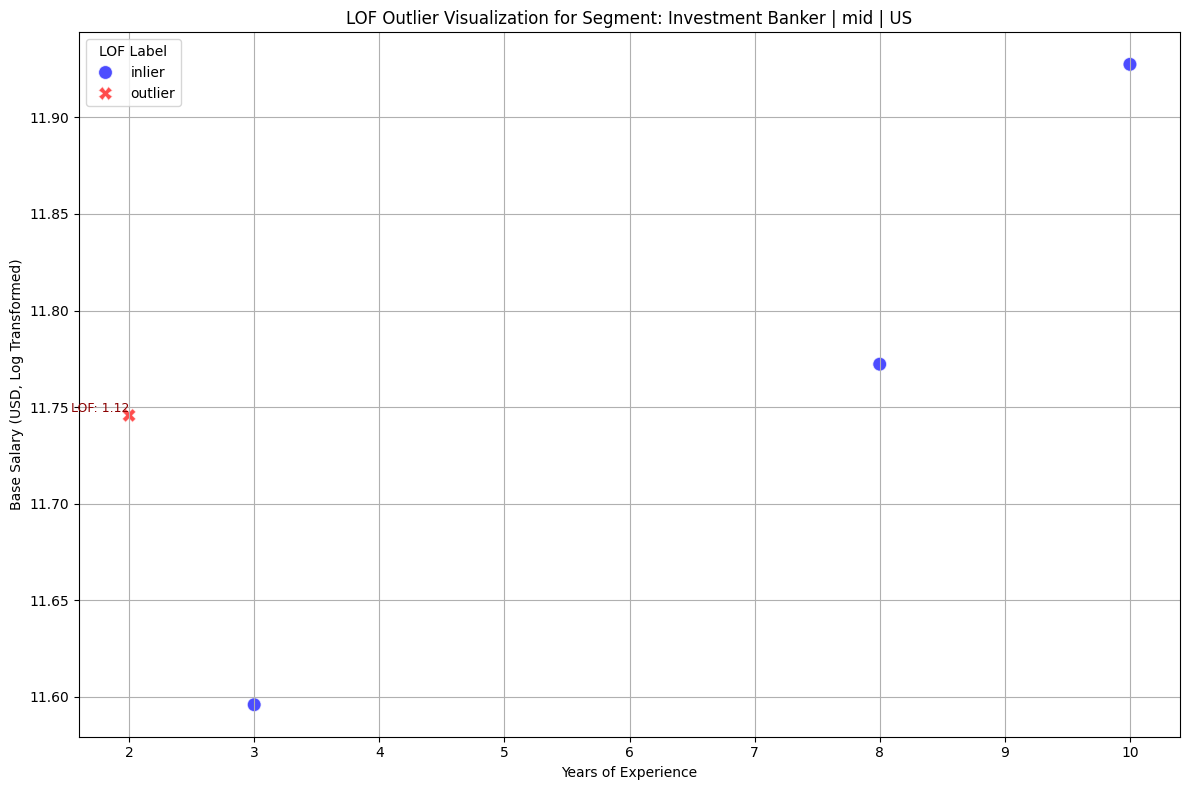

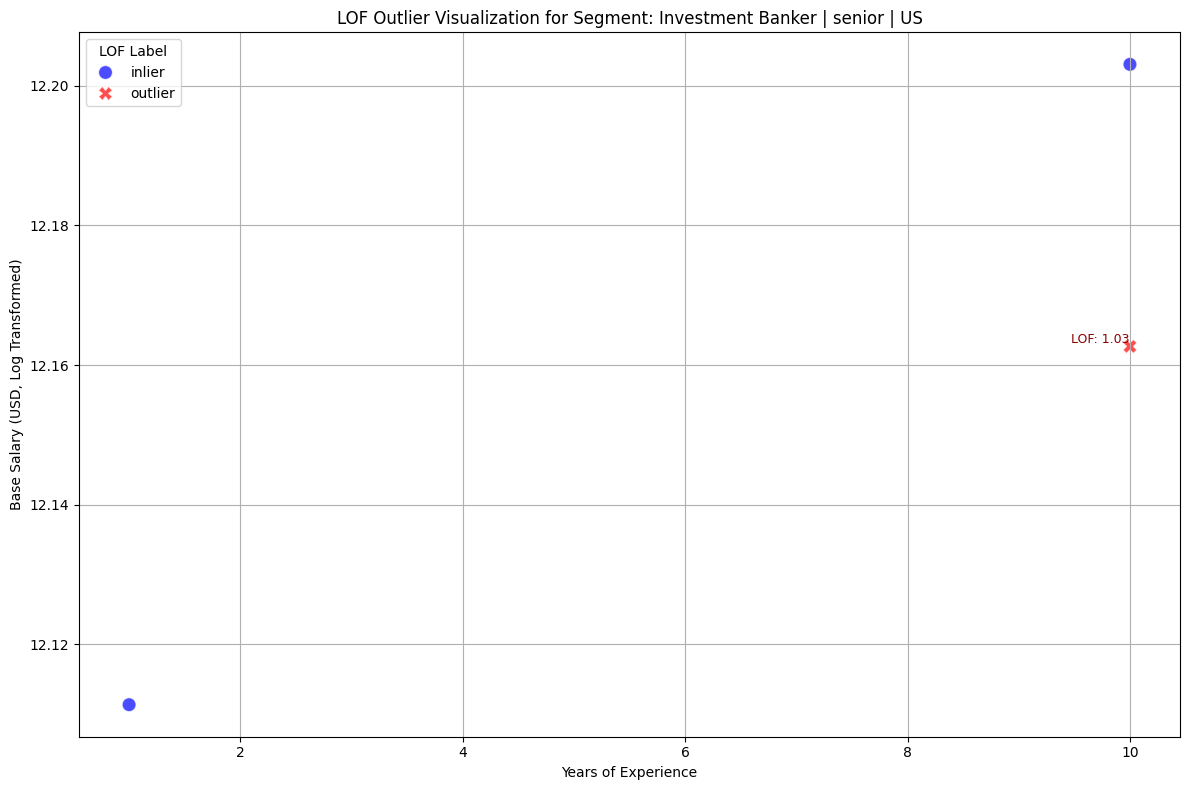


Generating plots for Job Title: Software Engineering Manager


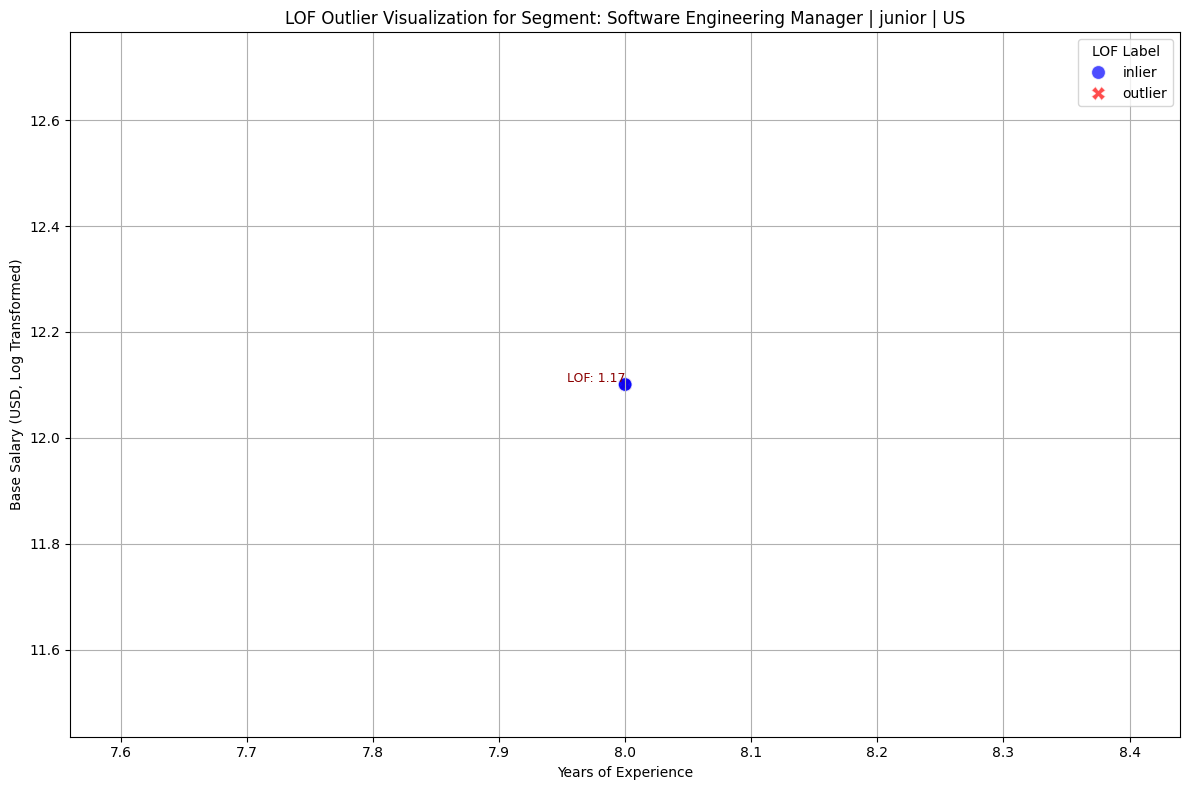

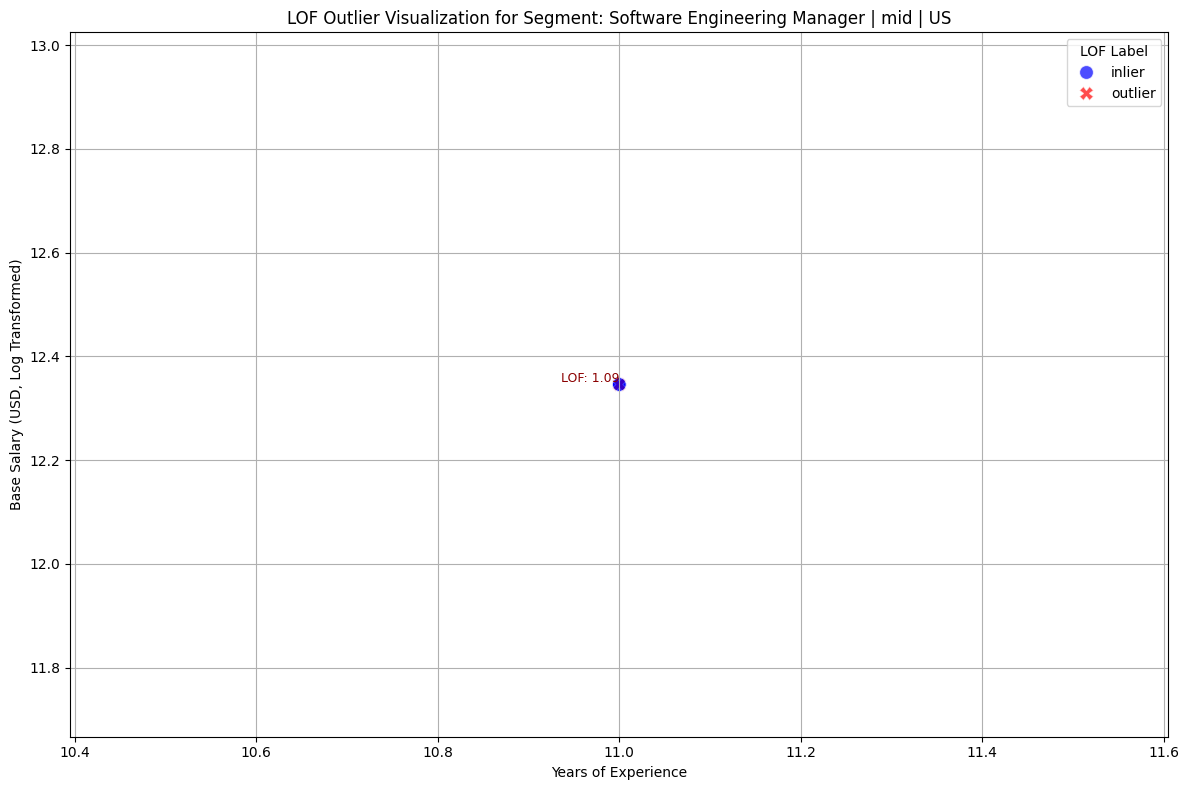

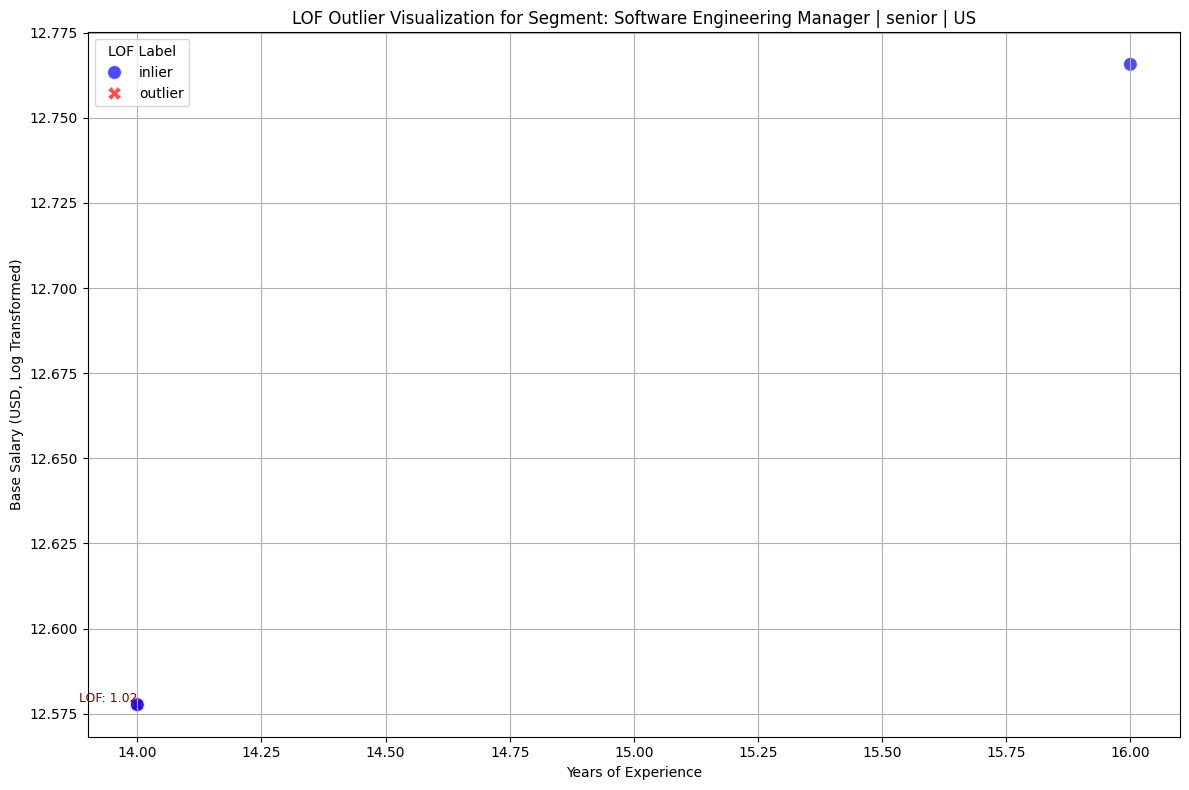


Generating plots for Job Title: Controls Engineer


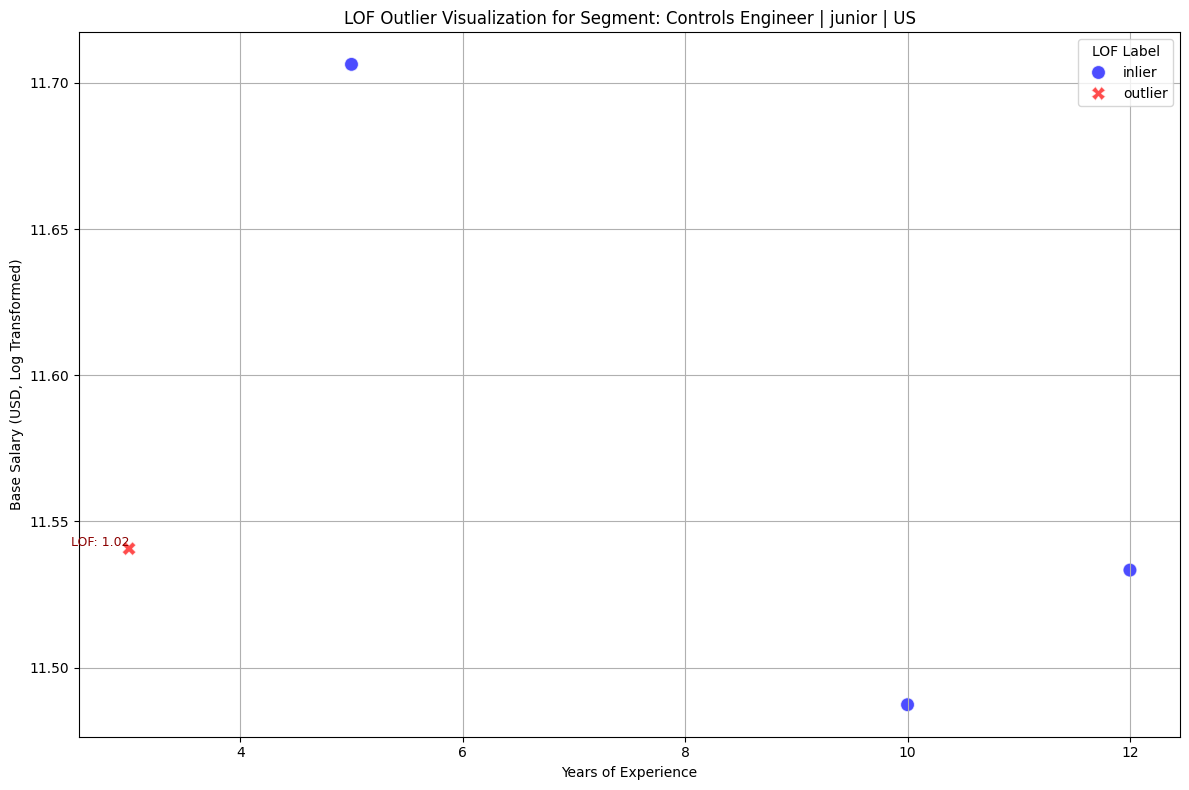

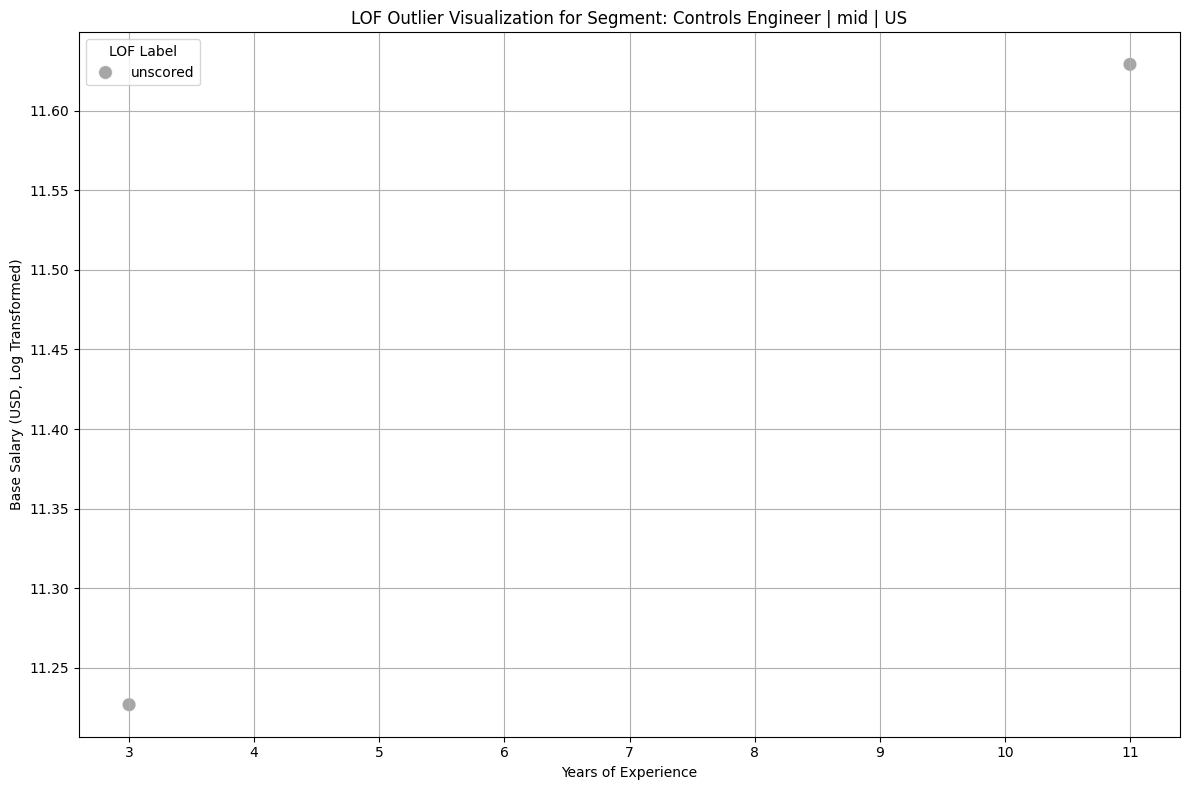

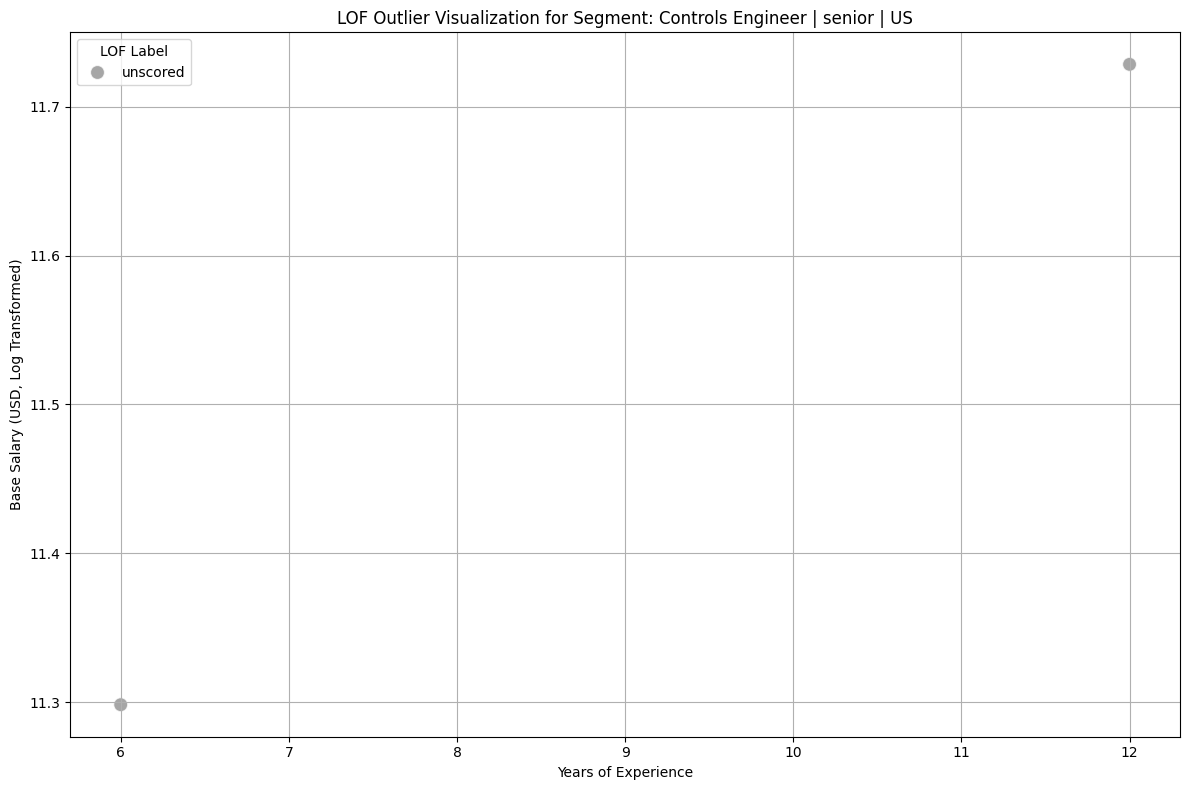


Generating plots for Job Title: Electrical Engineer


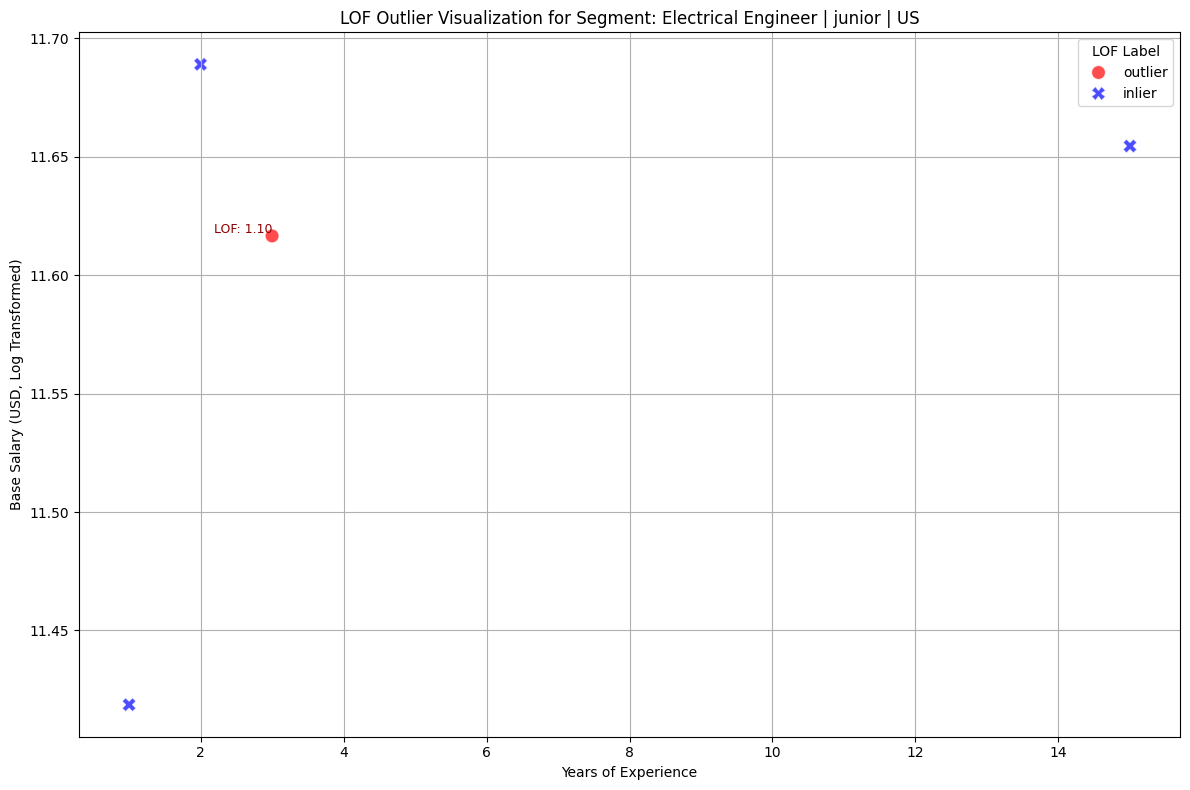

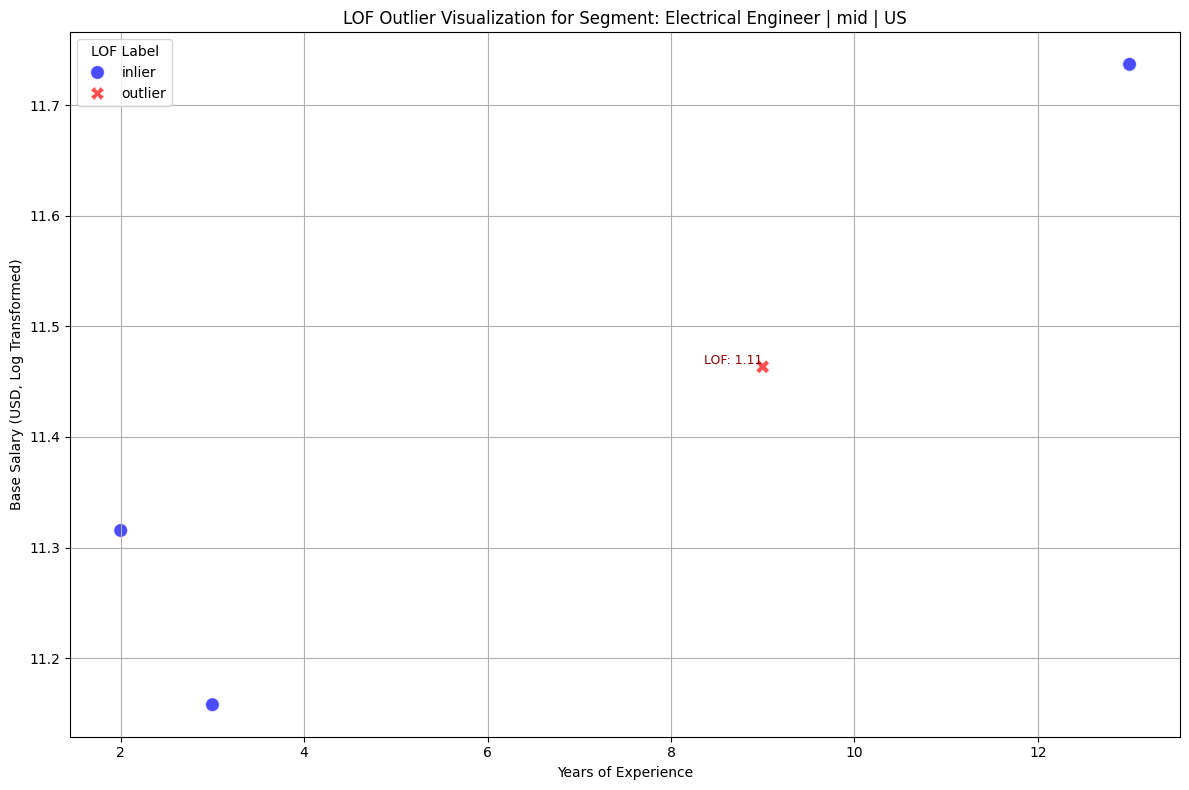

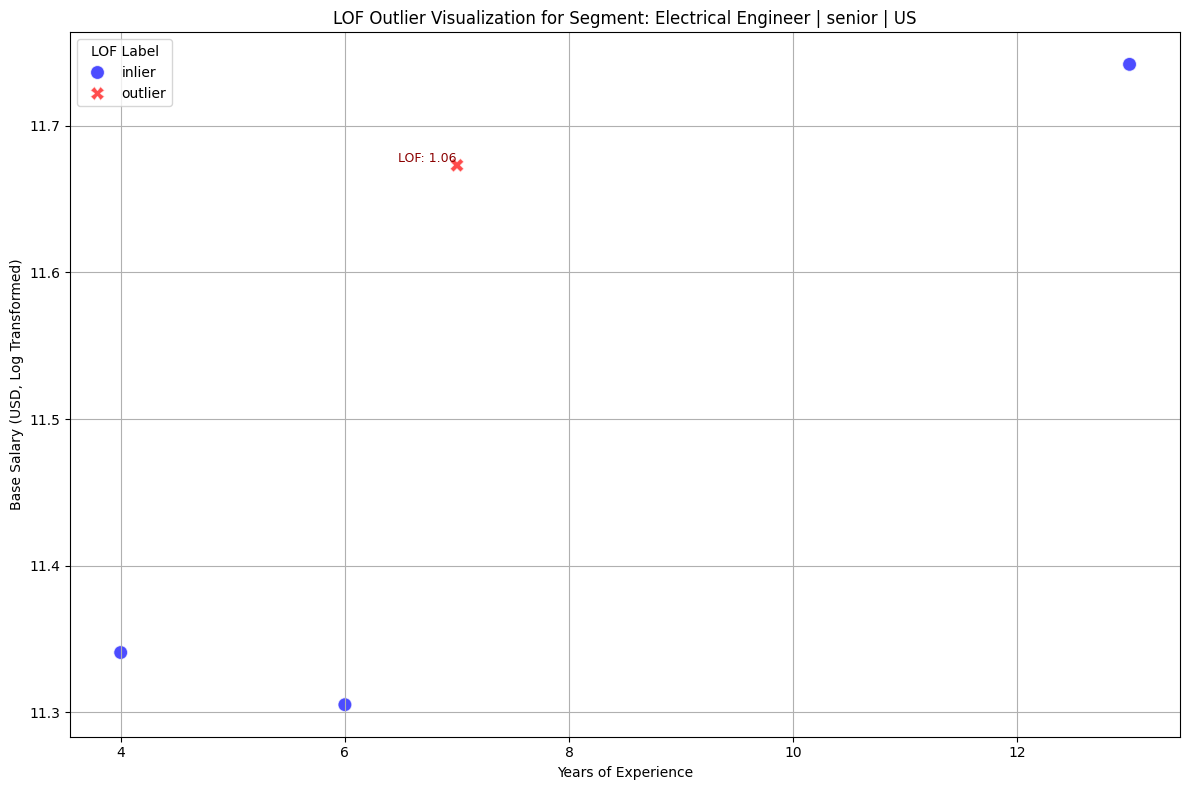


Generating plots for Job Title: Underwriter


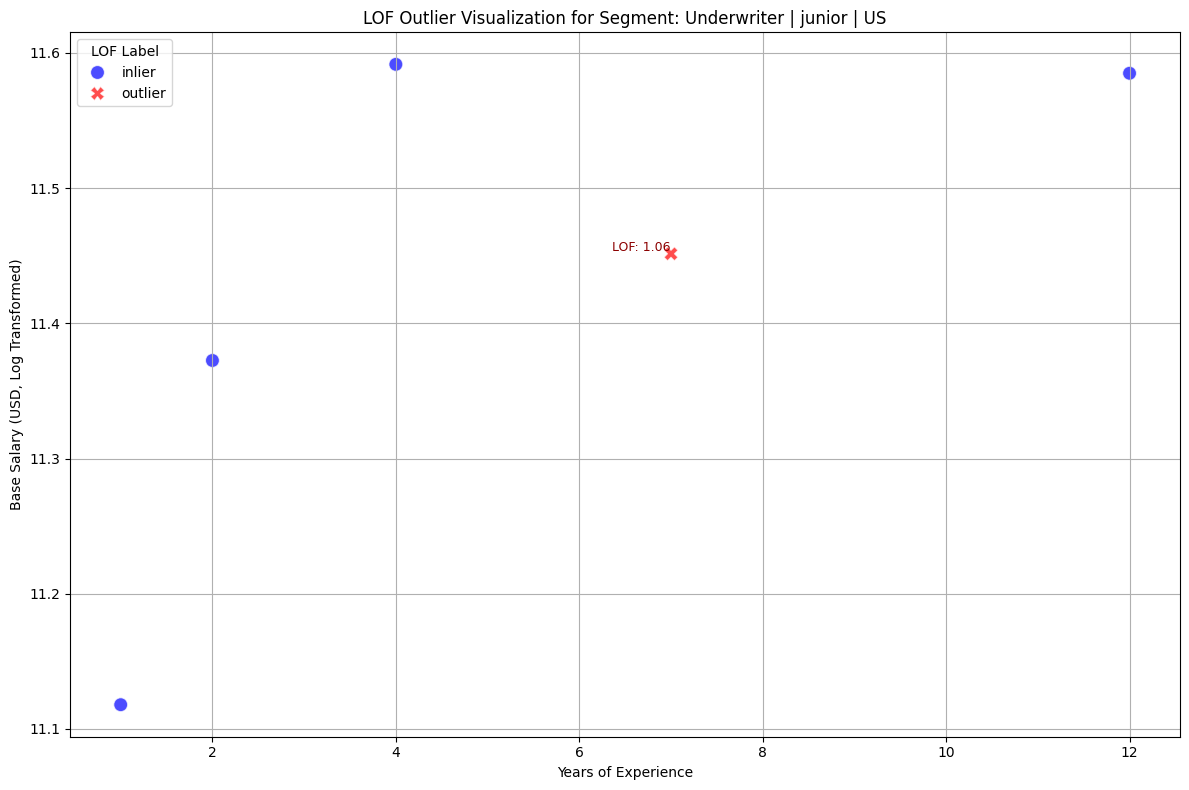

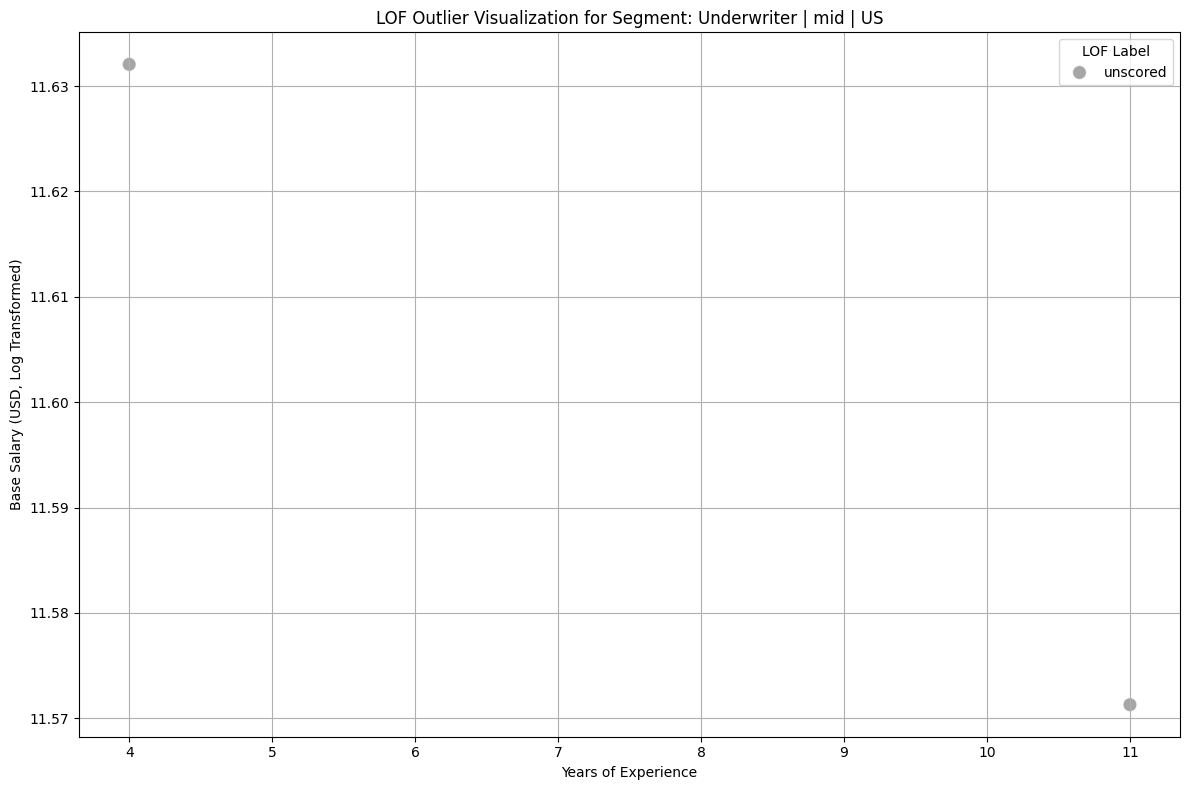

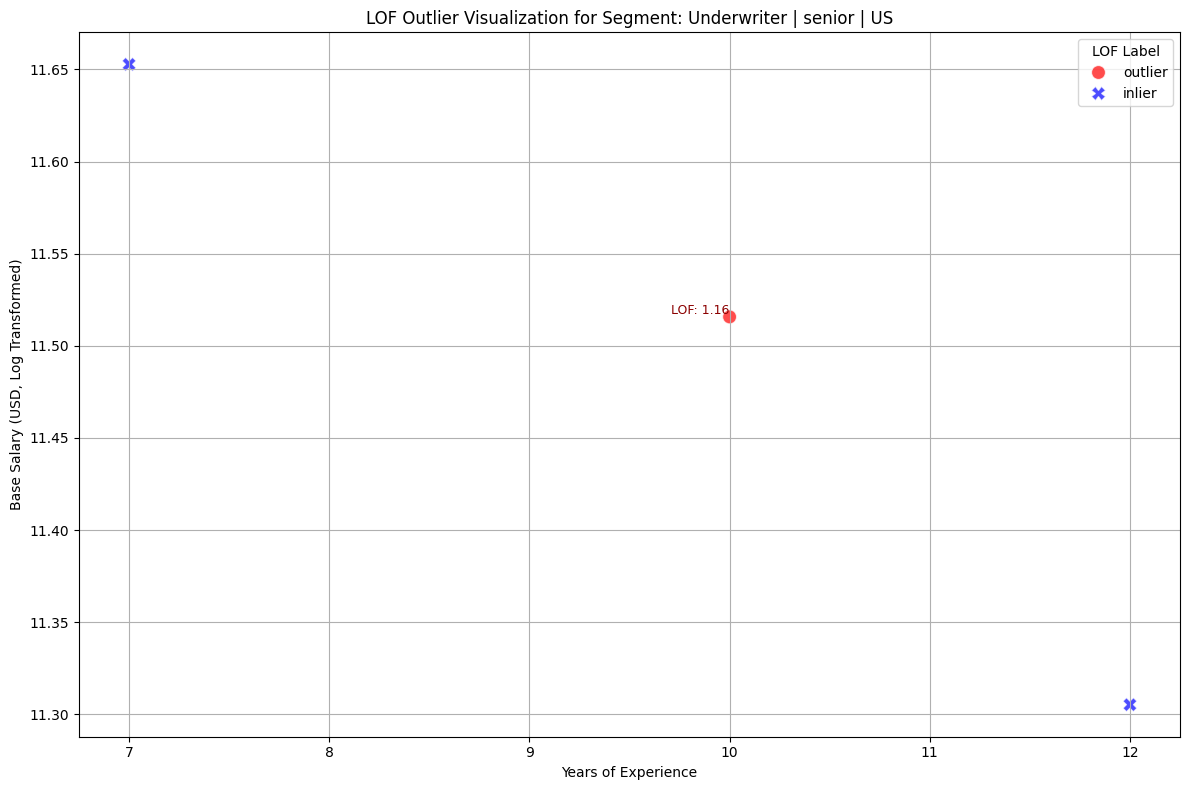


Generating plots for Job Title: Physician


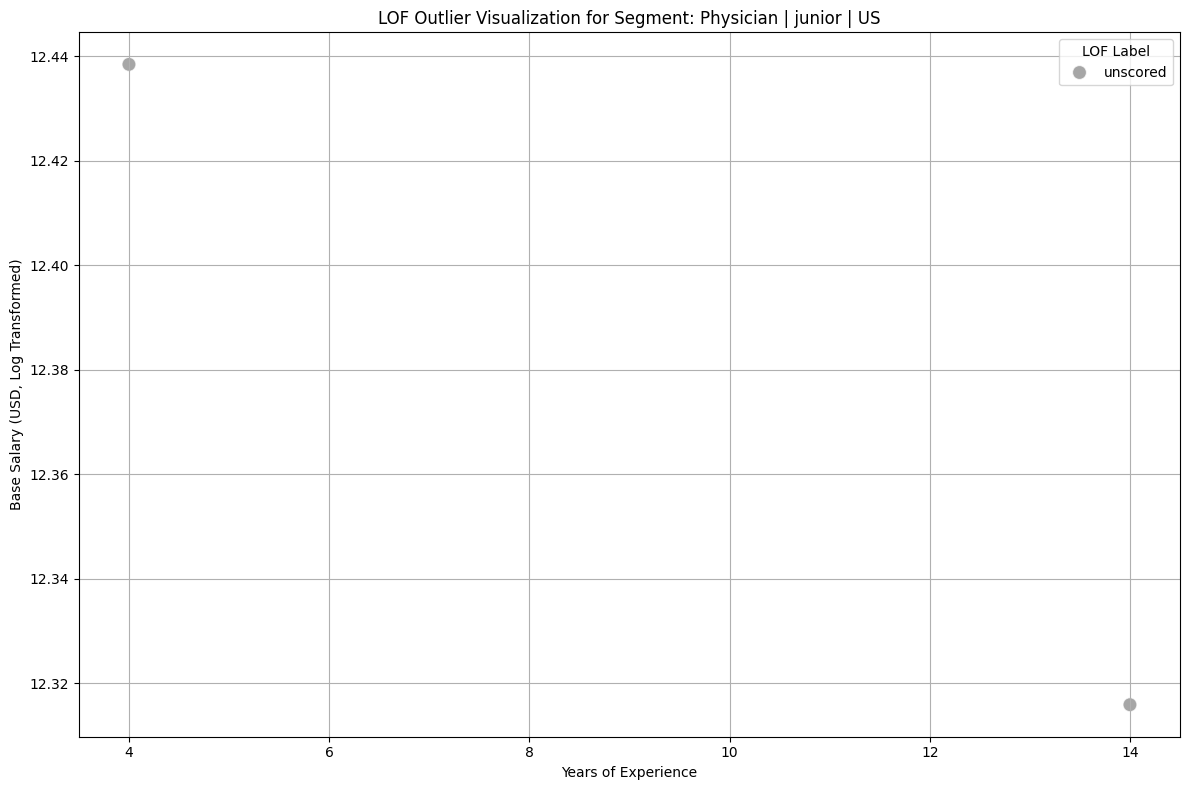

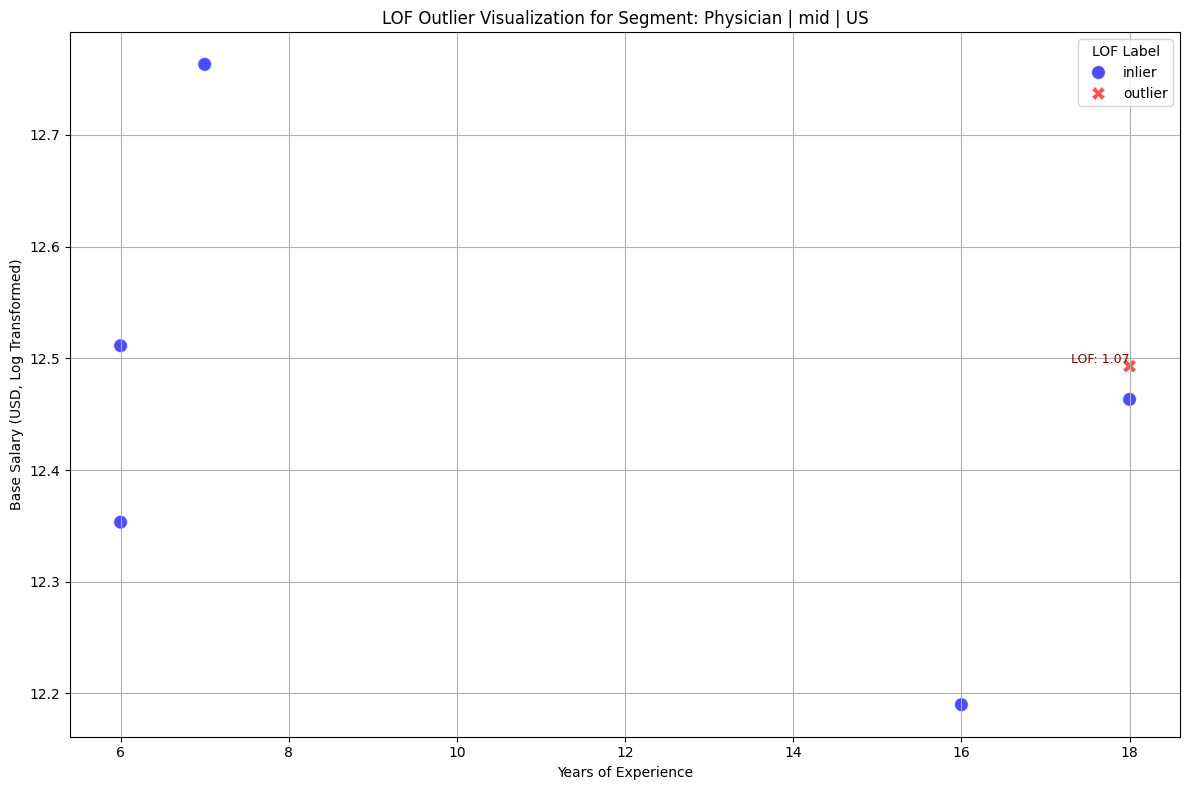

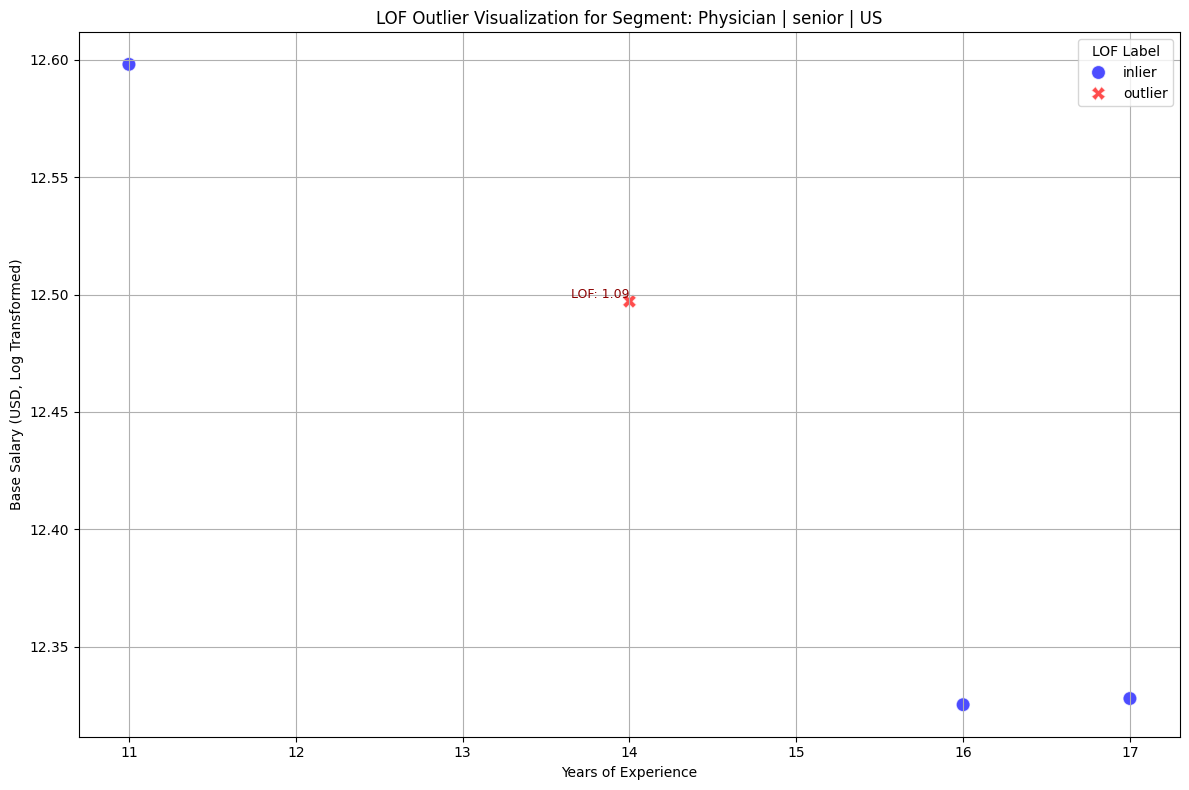

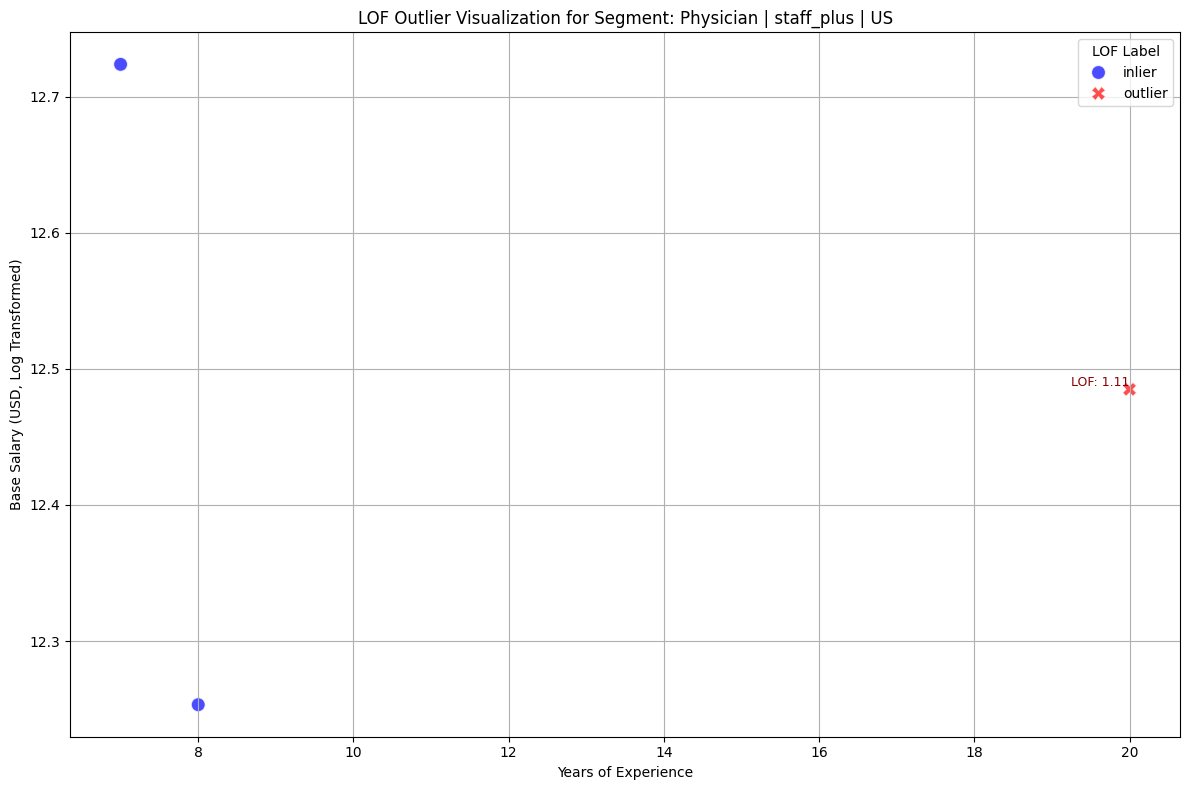


Generating plots for Job Title: Unknown


/tmp/ipykernel_3250/1666015547.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='LOF Label')


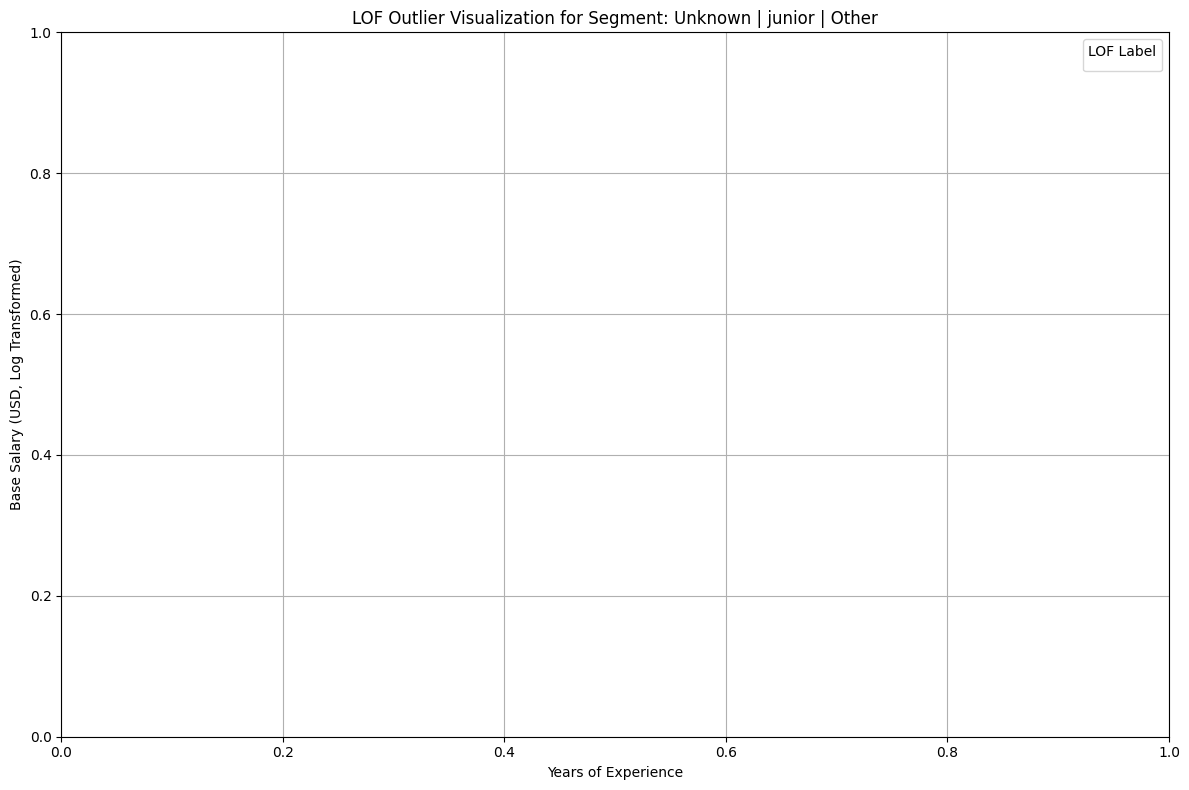

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_job_families = df_out['jobFamily_clean'].unique()

for job_family in unique_job_families:
    print(f"\nGenerating plots for Job Title: {job_family}")
    job_family_df = df_out[df_out['jobFamily_clean'] == job_family].copy()

    # Get unique segments within this job family, sorted for consistent output
    unique_segments = job_family_df['segment'].unique()
    sorted_segments = sorted(unique_segments)

    for segment_name in sorted_segments:
        segment_df = job_family_df[job_family_df['segment'] == segment_name].copy()

        if not segment_df.empty:
            plt.figure(figsize=(12, 8))

            sns.scatterplot(
                data=segment_df,
                x='yearsOfExperience',
                y='log_base_salary',
                hue='lof_label',
                style='lof_label',
                s=100,
                alpha=0.7,
                palette={'inlier': 'blue', 'outlier': 'red', 'unscored': 'gray'}
            )

            # Annotate outliers with their LOF score
            outliers = segment_df[segment_df['lof_label'] == 'outlier']
            for i, row in outliers.iterrows():
                plt.text(row['yearsOfExperience'], row['log_base_salary'], f"LOF: {row['lof_score']:.2f}",
                         fontsize=9, color='darkred', ha='right', va='bottom')

            plt.title(f'LOF Outlier Visualization for Segment: {segment_name}')
            plt.xlabel('Years of Experience')
            plt.ylabel('Base Salary (USD, Log Transformed)')
            plt.grid(True)
            plt.legend(title='LOF Label')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  No data found for segment: {segment_name} in job family {job_family}")